In [1]:
# Cell 1: Improved Live Game Data Retrieval

import pandas as pd
import ssl
import requests
from datetime import datetime, timedelta
import traceback
import pytz
from caching.supabase_client import supabase

def get_todays_date():
    """Get today's date in YYYY-MM-DD format in Pacific Time."""
    pacific_tz = pytz.timezone('America/Los_Angeles')
    return datetime.now(pacific_tz).strftime('%Y-%m-%d')

def get_yesterdays_date():
    """Get yesterday's date in YYYY-MM-DD format in Pacific Time."""
    pacific_tz = pytz.timezone('America/Los_Angeles')
    return (datetime.now(pacific_tz) - timedelta(days=1)).strftime('%Y-%m-%d')

def fetch_live_games():
    """Improved function to fetch only current live games with proper date and status filtering"""
    try:
        # Get current date in Pacific Time (NBA standard)
        pacific_tz = pytz.timezone('America/Los_Angeles')
        today_pacific = datetime.now(pacific_tz).strftime('%Y-%m-%d')
        yesterday_pacific = (datetime.now(pacific_tz) - timedelta(days=1)).strftime('%Y-%m-%d')
        
        print(f"Fetching live games for {today_pacific} (Pacific Time)")
        
        # First try today's games
        response = supabase.table("nba_live_game_stats").select("*").eq("game_date", today_pacific).execute()
        
        if not response.data:
            print(f"No live games found for today ({today_pacific}). Checking yesterday...")
            # Try yesterday in case games are still ongoing (late night games)
            response = supabase.table("nba_live_game_stats").select("*").eq("game_date", yesterday_pacific).execute()
        
        if not response.data:
            print("No live games found for today or yesterday.")
            return pd.DataFrame()
            
        live_df = pd.DataFrame(response.data)
        
        # Add validation to filter out completed games
        # A game is complete if Q4 has scores AND it's marked as finished or all quarters have data
        if 'is_finished' not in live_df.columns:
            # create an is_finished column with all False
            live_df['is_finished'] = False
        else:
            # fill any NaNs in existing is_finished column
            live_df['is_finished'] = live_df['is_finished'].fillna(False)

        completed_mask = (
            (live_df['home_q4'] > 0) &
            (live_df['away_q4'] > 0) &
            (live_df['is_finished'])
)
        
        # Remove completed games
        active_df = live_df[~completed_mask].copy()
        
        if active_df.empty:
            print("No active games found - all games appear to be completed.")
            return pd.DataFrame()
            
        print(f"Found {len(active_df)} active live games")
        return active_df
        
    except Exception as e:
        print(f"Error fetching live games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

def validate_game_data(df):
    """Validates and cleans game data to ensure consistency."""
    if df is None or df.empty:
        return pd.DataFrame()
    
    # Make a copy to avoid modifying original
    clean_df = df.copy()
    
    # Ensure required columns exist
    required_cols = ['game_id', 'home_team', 'away_team', 'game_date']
    for col in required_cols:
        if col not in clean_df.columns:
            print(f"Missing required column: {col}")
            return pd.DataFrame()
    
    # Validate team names and game IDs
    valid_rows = []
    for idx, row in clean_df.iterrows():
        if pd.isna(row['game_id']) or pd.isna(row['home_team']) or pd.isna(row['away_team']):
            print(f"Skipping row with missing essential data: {row}")
            continue
            
        # Clean team names - remove trailing spaces and normalize case
        if 'home_team' in row:
            clean_df.at[idx, 'home_team'] = row['home_team'].strip()
        if 'away_team' in row:
            clean_df.at[idx, 'away_team'] = row['away_team'].strip()
            
        # Ensure quarter scores are numeric
        for q in range(1, 5):
            home_q = f'home_q{q}'
            away_q = f'away_q{q}'
            
            if home_q in row:
                clean_df.at[idx, home_q] = pd.to_numeric(row[home_q], errors='coerce')
                if pd.isna(clean_df.at[idx, home_q]):
                    clean_df.at[idx, home_q] = 0
                    
            if away_q in row:
                clean_df.at[idx, away_q] = pd.to_numeric(row[away_q], errors='coerce')
                if pd.isna(clean_df.at[idx, away_q]):
                    clean_df.at[idx, away_q] = 0
        
        # Calculate current score from quarters if needed
        if 'home_score' not in clean_df.columns or pd.isna(row.get('home_score')):
            home_score = 0
            for q in range(1, 5):
                if f'home_q{q}' in clean_df.columns:
                    home_score += float(clean_df.at[idx, f'home_q{q}'] or 0)
            clean_df.at[idx, 'home_score'] = home_score
            
        if 'away_score' not in clean_df.columns or pd.isna(row.get('away_score')):
            away_score = 0
            for q in range(1, 5):
                if f'away_q{q}' in clean_df.columns:
                    away_score += float(clean_df.at[idx, f'away_q{q}'] or 0)
            clean_df.at[idx, 'away_score'] = away_score
            
        # Determine current quarter from data if not provided
        if 'current_quarter' not in clean_df.columns or pd.isna(row.get('current_quarter')):
            current_q = 0
            for q in range(1, 5):
                if f'home_q{q}' in clean_df.columns and clean_df.at[idx, f'home_q{q}'] > 0:
                    current_q = q
            clean_df.at[idx, 'current_quarter'] = current_q
        
        valid_rows.append(idx)
    
    # Keep only valid rows
    if valid_rows:
        return clean_df.loc[valid_rows]
    return pd.DataFrame()

def normalize_team_name(name):
    """Normalize team names for consistent matching."""
    if not name:
        return ""
        
    # Convert to string and lowercase
    name = str(name).lower().strip()
    
    # Standard team name mappings
    mappings = {
        'lakers': 'los angeles lakers',
        'la lakers': 'los angeles lakers',
        'clippers': 'los angeles clippers',
        'la clippers': 'los angeles clippers',
        'blazers': 'portland trail blazers',
        'sixers': 'philadelphia 76ers',
        'philly': 'philadelphia 76ers',
        'knicks': 'new york knicks',
        'ny knicks': 'new york knicks',
        'nets': 'brooklyn nets',
        'mavs': 'dallas mavericks',
        'cavs': 'cleveland cavaliers',
        'wolves': 'minnesota timberwolves',
        't-wolves': 'minnesota timberwolves',
        'celts': 'boston celtics',
        'pels': 'new orleans pelicans'
    }
    
    # Check if the name is in mappings
    for key, value in mappings.items():
        if key in name:
            return value
            
    return name

def match_teams_to_schedule(live_df, schedule_df):
    """Match live game teams to official schedule with normalized team names."""
    if live_df.empty or schedule_df.empty:
        return live_df
    
    matched_games = []
    unmatched_count = 0
    
    # Normalize team names in schedule
    schedule_df['home_team_norm'] = schedule_df['home_team'].apply(normalize_team_name)
    schedule_df['away_team_norm'] = schedule_df['away_team'].apply(normalize_team_name)
    
    for _, game in live_df.iterrows():
        home_team = normalize_team_name(game['home_team'])
        away_team = normalize_team_name(game['away_team'])
        
        # Try to find matching game in schedule
        match_found = False
        
        # First try exact matching
        exact_matches = schedule_df[
            ((schedule_df['home_team_norm'] == home_team) & 
             (schedule_df['away_team_norm'] == away_team)) |
            ((schedule_df['home_team_norm'] == away_team) & 
             (schedule_df['away_team_norm'] == home_team))
        ]
        
        if not exact_matches.empty:
            match = exact_matches.iloc[0]
            game_dict = game.to_dict()
            
            # Update with official team names and game_id
            if match['home_team_norm'] == home_team and match['away_team_norm'] == away_team:
                # Teams match without swapping
                game_dict['home_team'] = match['home_team']
                game_dict['away_team'] = match['away_team']
            else:
                # Teams are reversed - swap scores
                game_dict['home_team'] = match['home_team']
                game_dict['away_team'] = match['away_team']
                
                # Swap quarter scores
                for q in range(1, 5):
                    home_q = f'home_q{q}'
                    away_q = f'away_q{q}'
                    if home_q in game_dict and away_q in game_dict:
                        game_dict[home_q], game_dict[away_q] = game_dict[away_q], game_dict[home_q]
                
                # Swap total scores
                if 'home_score' in game_dict and 'away_score' in game_dict:
                    game_dict['home_score'], game_dict['away_score'] = game_dict['away_score'], game_dict['home_score']
            
            # Use official game_id
            game_dict['game_id'] = match['game_id']
            game_dict['matched_to_schedule'] = True
            
            matched_games.append(game_dict)
            match_found = True
        
        # Try fuzzy matching if exact match failed
        if not match_found:
            for _, sched_game in schedule_df.iterrows():
                sched_home = sched_game['home_team_norm']
                sched_away = sched_game['away_team_norm']
                
                # Check if either team name is a substring of the other
                if ((sched_home in home_team or home_team in sched_home) and
                    (sched_away in away_team or away_team in sched_away)):
                    
                    # Teams match without swapping
                    game_dict = game.to_dict()
                    game_dict['home_team'] = sched_game['home_team']
                    game_dict['away_team'] = sched_game['away_team']
                    game_dict['game_id'] = sched_game['game_id']
                    game_dict['matched_to_schedule'] = True
                    
                    matched_games.append(game_dict)
                    match_found = True
                    break
                
                # Check for reversed team order
                elif ((sched_home in away_team or away_team in sched_home) and
                      (sched_away in home_team or home_team in sched_away)):
                    
                    # Teams are reversed - swap scores
                    game_dict = game.to_dict()
                    game_dict['home_team'] = sched_game['home_team']
                    game_dict['away_team'] = sched_game['away_team']
                    game_dict['game_id'] = sched_game['game_id']
                    game_dict['matched_to_schedule'] = True
                    
                    # Swap quarter scores
                    for q in range(1, 5):
                        home_q = f'home_q{q}'
                        away_q = f'away_q{q}'
                        if home_q in game_dict and away_q in game_dict:
                            game_dict[home_q], game_dict[away_q] = game_dict[away_q], game_dict[home_q]
                    
                    # Swap total scores
                    if 'home_score' in game_dict and 'away_score' in game_dict:
                        game_dict['home_score'], game_dict['away_score'] = game_dict['away_score'], game_dict['home_score']
                    
                    matched_games.append(game_dict)
                    match_found = True
                    break
        
        if not match_found:
            # Keep the original game but mark as unmatched
            game_dict = game.to_dict()
            game_dict['matched_to_schedule'] = False
            matched_games.append(game_dict)
            unmatched_count += 1
    
    result_df = pd.DataFrame(matched_games)
    print(f"Matched {len(result_df) - unmatched_count} of {len(result_df)} games to schedule")
    
    return result_df

def convert_scheduled_to_live_format(schedule_df):
    """Converts scheduled games to the format expected by the prediction system."""
    if schedule_df is None or schedule_df.empty:
        return pd.DataFrame()
    
    live_format = []
    for _, game in schedule_df.iterrows():
        # Create template with zeroed stats for pre-game
        live_game = {
            'game_id': game['game_id'],
            'home_team': game['home_team'],
            'away_team': game['away_team'],
            'game_date': game['game_date'],
            'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
            'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
            'home_score': 0,
            'away_score': 0,
            'current_quarter': 0,  # Pre-game
            'matched_to_schedule': True
        }
        live_format.append(live_game)
    
    return pd.DataFrame(live_format)

def create_test_games_data():
    """Creates synthetic test data when no real games are available."""
    print("Creating synthetic test games data for demonstration")
    today = get_todays_date()
    
    # Create realistic test data with different quarters for testing
    test_games = [
        {
            'game_id': 90001,
            'home_team': 'Los Angeles Lakers',
            'away_team': 'Brooklyn Nets',
            'game_date': today,
            'home_q1': 30, 'home_q2': 28, 'home_q3': 0, 'home_q4': 0,
            'away_q1': 25, 'away_q2': 32, 'away_q3': 0, 'away_q4': 0,
            'home_score': 58,
            'away_score': 57,
            'current_quarter': 2,  # Halftime
            'matched_to_schedule': False
        },
        {
            'game_id': 90002,
            'home_team': 'Boston Celtics',
            'away_team': 'Miami Heat',
            'game_date': today,
            'home_q1': 28, 'home_q2': 26, 'home_q3': 30, 'home_q4': 0,
            'away_q1': 24, 'away_q2': 27, 'away_q3': 25, 'away_q4': 0,
            'home_score': 84,
            'away_score': 76,
            'current_quarter': 3,  # 3rd quarter
            'matched_to_schedule': False
        }
    ]
    
    return pd.DataFrame(test_games)

# Test the improved function
live_games = fetch_live_games()
if not live_games.empty:
    print("\nSuccessfully retrieved game data:")
    display(live_games)
else:
    print("\nNo game data available.")

Fetching live games for 2025-03-07 (Pacific Time)
Found 1 active live games

Successfully retrieved game data:


,id,game_id,home_team,away_team,home_score,away_score,home_q1,home_q2,home_q3,home_q4,...,home_total_reb,away_off_reb,away_def_reb,away_total_reb,home_3pm,home_3pa,away_3pm,away_3pa,current_quarter,is_finished
0,122,414817,Orlando Magic,Chicago Bulls,123,125,35,31,35,22,...,33,13,35,48,9,33,15,40,4,False


In [2]:
# Cell 2: Imports and helper functions
import pandas as pd
import numpy as np
import joblib
from sqlalchemy import create_engine
import config

# Define a helper to convert time strings "MM:SS" into numeric minutes
def convert_time_to_minutes(time_str):
    if pd.isna(time_str) or ":" not in str(time_str):
        return None
    try:
        minutes, seconds = str(time_str).split(":")
        return float(minutes) + float(seconds) / 60.0
    except Exception as e:
        print("Error converting time:", e)
        return None


PROJECT_ROOT: /Users/mattb/Desktop/Projects/score-genius
MODEL_PATH: /Users/mattb/Desktop/Projects/score-genius/backend/models/score_prediction_model.pkl


In [3]:
# Cell 2B: Helper functions for data safety and compatibility

def ensure_numeric_features(df, feature_columns):
    """
    Ensures all feature columns are numeric, replacing NaN/None values with appropriate defaults.
    
    Args:
        df (DataFrame): Input DataFrame
        feature_columns (list): List of column names to process
        
    Returns:
        DataFrame: DataFrame with ensured numeric features
    """
    # Make a copy to avoid modifying the original
    result_df = df.copy()
    
    # Default values based on column type
    default_map = {
        'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
        'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
        'home_score': 0, 'away_score': 0,
        'rolling_home_score': 105.0, 'rolling_away_score': 105.0,
        'score_ratio': 0.5,
        'prev_matchup_diff': 0,
        'rest_days_home': 2, 'rest_days_away': 2, 'rest_advantage': 0,
        'is_back_to_back_home': 0, 'is_back_to_back_away': 0,
        'q1_to_q2_momentum': 0, 'q2_to_q3_momentum': 0, 'q3_to_q4_momentum': 0,
        'cumulative_momentum': 0
    }
    
    # For any column not in default_map, use 0 as default
    for col in feature_columns:
        if col not in default_map:
            default_map[col] = 0
    
    # Process each column
    for col in feature_columns:
        if col in result_df.columns:
            # Convert to numeric, forcing errors to NaN
            result_df[col] = pd.to_numeric(result_df[col], errors='coerce')
            
            # Replace NaN values with appropriate defaults
            result_df[col] = result_df[col].fillna(default_map.get(col, 0))
        else:
            # If column doesn't exist, add it with default values
            result_df[col] = default_map.get(col, 0)
    
    return result_df

def calculate_derived_features(df):
    """
    Calculates derived features like current score from quarters, momentum, etc.
    
    Args:
        df (DataFrame): Input DataFrame with raw game data
        
    Returns:
        DataFrame: DataFrame with additional calculated features
    """
    # Make a copy to avoid modifying the original
    result_df = df.copy()
    
    # 1. Calculate current scores from quarters if not already present
    for idx, row in result_df.iterrows():
        # Home score
        if pd.isna(row.get('home_score')) or row.get('home_score', 0) == 0:
            # Sum up quarters that have data
            home_score = 0
            for q in ['home_q1', 'home_q2', 'home_q3', 'home_q4']:
                if q in row and pd.notna(row[q]):
                    home_score += float(row[q] or 0)
            result_df.at[idx, 'home_score'] = home_score
        
        # Away score
        if pd.isna(row.get('away_score')) or row.get('away_score', 0) == 0:
            # Sum up quarters that have data
            away_score = 0
            for q in ['away_q1', 'away_q2', 'away_q3', 'away_q4']:
                if q in row and pd.notna(row[q]):
                    away_score += float(row[q] or 0)
            result_df.at[idx, 'away_score'] = away_score
    
    # 2. Determine current quarter based on available quarter scores
    for idx, row in result_df.iterrows():
        current_quarter = 0
        if pd.notna(row.get('home_q1')) and float(row.get('home_q1') or 0) > 0:
            current_quarter = 1
        if pd.notna(row.get('home_q2')) and float(row.get('home_q2') or 0) > 0:
            current_quarter = 2
        if pd.notna(row.get('home_q3')) and float(row.get('home_q3') or 0) > 0:
            current_quarter = 3
        if pd.notna(row.get('home_q4')) and float(row.get('home_q4') or 0) > 0:
            current_quarter = 4
        
        # Handle cases where current_quarter might already exist
        if 'current_quarter' not in result_df.columns:
            result_df['current_quarter'] = 0
        result_df.at[idx, 'current_quarter'] = current_quarter
    
    # 3. Calculate score ratio (only for rows with non-zero total score)
    for idx, row in result_df.iterrows():
        home_score = float(row.get('home_score') or 0)
        away_score = float(row.get('away_score') or 0)
        total_score = home_score + away_score
        
        # Default to 0.5 for games with no score yet
        score_ratio = 0.5
        if total_score > 0:
            score_ratio = home_score / total_score
        
        result_df.at[idx, 'score_ratio'] = score_ratio
    
    # 4. Calculate momentum features when applicable
    for idx, row in result_df.iterrows():
        current_quarter = int(row.get('current_quarter') or 0)
        
        # Initialize momentum features with zeros
        result_df.at[idx, 'q1_to_q2_momentum'] = 0
        result_df.at[idx, 'q2_to_q3_momentum'] = 0
        result_df.at[idx, 'q3_to_q4_momentum'] = 0
        result_df.at[idx, 'cumulative_momentum'] = 0
        
        # Calculate quarter-to-quarter momentum shifts
        if current_quarter >= 2:
            # Q1 to Q2 momentum
            home_q1 = float(row.get('home_q1') or 0)
            home_q2 = float(row.get('home_q2') or 0)
            away_q1 = float(row.get('away_q1') or 0)
            away_q2 = float(row.get('away_q2') or 0)
            
            q1_to_q2 = (home_q2 - home_q1) - (away_q2 - away_q1)
            # Cap extreme values
            q1_to_q2 = max(min(q1_to_q2, 25), -25)
            result_df.at[idx, 'q1_to_q2_momentum'] = q1_to_q2
        
        if current_quarter >= 3:
            # Q2 to Q3 momentum
            home_q2 = float(row.get('home_q2') or 0)
            home_q3 = float(row.get('home_q3') or 0)
            away_q2 = float(row.get('away_q2') or 0)
            away_q3 = float(row.get('away_q3') or 0)
            
            q2_to_q3 = (home_q3 - home_q2) - (away_q3 - away_q2)
            # Cap extreme values
            q2_to_q3 = max(min(q2_to_q3, 25), -25)
            result_df.at[idx, 'q2_to_q3_momentum'] = q2_to_q3
        
        if current_quarter >= 4:
            # Q3 to Q4 momentum
            home_q3 = float(row.get('home_q3') or 0)
            home_q4 = float(row.get('home_q4') or 0)
            away_q3 = float(row.get('away_q3') or 0)
            away_q4 = float(row.get('away_q4') or 0)
            
            q3_to_q4 = (home_q4 - home_q3) - (away_q4 - away_q3)
            # Cap extreme values
            q3_to_q4 = max(min(q3_to_q4, 25), -25)
            result_df.at[idx, 'q3_to_q4_momentum'] = q3_to_q4
        
        # Calculate cumulative momentum with weights
        weights = [0.2, 0.3, 0.5]  # Weights for Q1→Q2, Q2→Q3, Q3→Q4
        
        if current_quarter == 2:
            result_df.at[idx, 'cumulative_momentum'] = result_df.at[idx, 'q1_to_q2_momentum']
        elif current_quarter == 3:
            q1_to_q2 = result_df.at[idx, 'q1_to_q2_momentum']
            q2_to_q3 = result_df.at[idx, 'q2_to_q3_momentum']
            weighted_momentum = (q1_to_q2 * weights[0] + q2_to_q3 * weights[1]) / (weights[0] + weights[1])
            result_df.at[idx, 'cumulative_momentum'] = weighted_momentum
        elif current_quarter >= 4:
            q1_to_q2 = result_df.at[idx, 'q1_to_q2_momentum']
            q2_to_q3 = result_df.at[idx, 'q2_to_q3_momentum']
            q3_to_q4 = result_df.at[idx, 'q3_to_q4_momentum']
            weighted_momentum = (q1_to_q2 * weights[0] + q2_to_q3 * weights[1] + q3_to_q4 * weights[2]) / sum(weights)
            result_df.at[idx, 'cumulative_momentum'] = weighted_momentum
        
        # Normalize momentum to [-1, 1]
        if result_df.at[idx, 'cumulative_momentum'] != 0:
            norm_momentum = result_df.at[idx, 'cumulative_momentum'] / 15.0
            result_df.at[idx, 'cumulative_momentum'] = max(min(norm_momentum, 1.0), -1.0)
    
    return result_df

def prepare_features_for_model(df, expected_features, team_avgs=None):
    """
    Prepares features in the correct format for model input.
    
    Args:
        df (DataFrame): Input game data
        expected_features (list): Features expected by the model
        team_avgs (dict, optional): Team scoring averages for rolling features
        
    Returns:
        DataFrame: Features ready for model prediction
    """
    # Ensure all basic numeric features are present and valid
    df = ensure_numeric_features(df, expected_features)
    
    # If team_avgs provided, use them for rolling averages
    if team_avgs is not None and 'rolling_home_score' in expected_features:
        # Update rolling average features if in expected features
        for idx, row in df.iterrows():
            if 'home_team' in row and row['home_team'] in team_avgs:
                df.at[idx, 'rolling_home_score'] = team_avgs[row['home_team']]
            if 'away_team' in row and row['away_team'] in team_avgs:
                df.at[idx, 'rolling_away_score'] = team_avgs[row['away_team']]
    
    # Select only the expected features in the correct order
    X = df[expected_features].copy()
    
    return X

In [4]:
# Cell 2C: Improved Rest Days Calculation

import pandas as pd
from datetime import datetime, timedelta
from sqlalchemy import create_engine
import config
import traceback

def calculate_improved_rest_features(df, max_lookback_days=30, max_rest_days=10):
    """
    Improved function to calculate rest-related features with better validation and constraints.
    
    Args:
        df: DataFrame with historical game data
        max_lookback_days: Maximum days to look back for previous games
        max_rest_days: Maximum allowed rest days (to prevent outliers)
    
    Returns:
        DataFrame with added rest features
    """
    print(f"Calculating improved rest features with {max_lookback_days} day lookback...")
    
    # Validate input
    if df is None or df.empty:
        print("No data provided for rest calculation")
        return df
    
    # Make a copy to avoid modifying original
    result_df = df.copy()
    
    # Ensure game_date is datetime
    if 'game_date' in result_df.columns:
        try:
            result_df['game_date'] = pd.to_datetime(result_df['game_date'], errors='coerce')
            # Check for invalid dates after conversion
            invalid_dates = result_df['game_date'].isna().sum()
            if invalid_dates > 0:
                print(f"Warning: {invalid_dates} invalid dates found and will be excluded from rest calculations")
                # Drop rows with invalid dates (only for rest calculation)
                result_df = result_df.dropna(subset=['game_date'])
        except Exception as e:
            print(f"Error converting game_date to datetime: {e}")
            # Add empty rest columns and return
            result_df['rest_days_home'] = 2.0  # Default value
            result_df['rest_days_away'] = 2.0
            result_df['is_back_to_back_home'] = 0
            result_df['is_back_to_back_away'] = 0
            result_df['rest_advantage'] = 0
            return result_df
    else:
        print("Warning: 'game_date' column not found, using default rest values")
        result_df['rest_days_home'] = 2.0  # Default value
        result_df['rest_days_away'] = 2.0
        result_df['is_back_to_back_home'] = 0
        result_df['is_back_to_back_away'] = 0
        result_df['rest_advantage'] = 0
        return result_df
    
    # Initialize rest columns with defaults
    result_df['rest_days_home'] = 2.0  # Default value
    result_df['rest_days_away'] = 2.0
    result_df['is_back_to_back_home'] = 0
    result_df['is_back_to_back_away'] = 0
    
    # Sort by date for accurate calculations
    result_df = result_df.sort_values('game_date')
    
    # Get unique teams
    all_teams = set()
    if 'home_team' in result_df.columns:
        all_teams.update(result_df['home_team'].dropna().unique())
    if 'away_team' in result_df.columns:
        all_teams.update(result_df['away_team'].dropna().unique())
    
    print(f"Processing rest days for {len(all_teams)} teams...")
    
    # Dictionary to cache team schedules for performance
    team_schedules = {}
    
    # Calculate rest days for each team
    for team in all_teams:
        # Skip invalid team names
        if pd.isna(team) or team == '':
            continue
            
        try:
            # Check if we've already computed the schedule for this team
            if team in team_schedules:
                all_team_games = team_schedules[team]
            else:
                # Get all games for this team, both home and away
                home_games = result_df[result_df['home_team'] == team][['game_id', 'game_date', 'home_team']].copy()
                home_games['role'] = 'home'
                
                away_games = result_df[result_df['away_team'] == team][['game_id', 'game_date', 'away_team']].copy()
                away_games['role'] = 'away'
                
                # Combine and sort chronologically
                all_team_games = pd.concat([home_games, away_games]).sort_values('game_date')
                
                # Check for empty result
                if all_team_games.empty:
                    print(f"No games found for team {team}")
                    continue
                
                # Cache the schedule for reuse
                team_schedules[team] = all_team_games
            
            if len(all_team_games) <= 1:
                print(f"Only one game found for team {team}, using default rest days")
                continue  # Skip if only one or zero games
                
            # Calculate days between consecutive games
            all_team_games['prev_date'] = all_team_games['game_date'].shift(1)
            
            # Use actual days between games, with a maximum lookback
            min_valid_date = all_team_games['game_date'].min() - pd.Timedelta(days=max_lookback_days)
            all_team_games['days_since_prev'] = (all_team_games['game_date'] - all_team_games['prev_date']).dt.days
            
            # Handle the first game and cap rest days
            all_team_games['days_since_prev'] = all_team_games['days_since_prev'].fillna(3)  # Default for first game
            all_team_games['days_since_prev'] = all_team_games['days_since_prev'].clip(1, max_rest_days)
            
            # Identify back-to-back games
            all_team_games['is_back_to_back'] = (all_team_games['days_since_prev'] == 1).astype(int)
            
            # Update values in the main dataframe
            for _, row in all_team_games.iterrows():
                game_id = row['game_id']
                days_rest = row['days_since_prev']
                is_b2b = row['is_back_to_back']
                
                if pd.isna(game_id):
                    continue
                
                # Find the right rows to update using game_id and team
                if row['role'] == 'home':
                    match_idx = result_df[result_df['game_id'] == game_id].index
                    if not match_idx.empty:
                        # Double-check that this is the right team
                        if result_df.loc[match_idx[0], 'home_team'] == team:
                            result_df.loc[match_idx, 'rest_days_home'] = days_rest
                            result_df.loc[match_idx, 'is_back_to_back_home'] = is_b2b
                else:  # away
                    match_idx = result_df[result_df['game_id'] == game_id].index
                    if not match_idx.empty:
                        # Double-check that this is the right team
                        if result_df.loc[match_idx[0], 'away_team'] == team:
                            result_df.loc[match_idx, 'rest_days_away'] = days_rest
                            result_df.loc[match_idx, 'is_back_to_back_away'] = is_b2b
        
        except Exception as e:
            print(f"Error processing rest days for team {team}: {e}")
            traceback.print_exc()
            # Continue with next team rather than stopping
            continue  
    
    # Calculate rest advantage after all teams are processed
    if 'rest_days_home' in result_df.columns and 'rest_days_away' in result_df.columns:
        result_df['rest_advantage'] = result_df['rest_days_home'] - result_df['rest_days_away']
        # Cap extreme values
        result_df['rest_advantage'] = result_df['rest_advantage'].clip(-5, 5)
    
    print("Rest day calculation complete.")
    
    # Show distribution of rest days to verify correctness
    print("\nRest days distribution (home teams):")
    print(result_df['rest_days_home'].value_counts().sort_index())
    
    print("\nRest days distribution (away teams):")
    print(result_df['rest_days_away'].value_counts().sort_index())
    
    print("\nBack-to-back games (home teams):", result_df['is_back_to_back_home'].sum())
    print("Back-to-back games (away teams):", result_df['is_back_to_back_away'].sum())
    
    return result_df

# Test on a sample dataset
try:
    # Connect to database
    engine = create_engine(config.DATABASE_URL)
    
    # Load a small sample for testing
    query = """
    SELECT * FROM nba_historical_game_stats 
    WHERE game_date >= (CURRENT_DATE - INTERVAL '60 days')
    ORDER BY game_date
    LIMIT 100
    """
    
    sample_df = pd.read_sql(query, engine)
    print(f"Loaded {len(sample_df)} games for rest days calculation test")
    
    if sample_df.empty:
        # If no data is returned, skip rest calculations to avoid KeyError
        print("No data found in 'nba_historical_game_stats' for the last 60 days. Skipping rest feature analysis.")
    else:
        # Apply improved rest calculation
        sample_with_rest = calculate_improved_rest_features(sample_df)
        
        # Only attempt to display rest columns if the DataFrame isn't empty
        if not sample_with_rest.empty:
            rest_stats = sample_with_rest[[
                'rest_days_home',
                'rest_days_away',
                'rest_advantage',
                'is_back_to_back_home',
                'is_back_to_back_away'
            ]].describe()
            
            display(rest_stats)
        else:
            print("No rest stats to display - the DataFrame is empty after rest calculation.")

except Exception as e:
    print(f"Error in rest days calculation test: {e}")
    traceback.print_exc()

def calculate_default_features(df):
    """Add default rest and momentum features when historical data is unavailable"""
    if df is None or df.empty:
        return df
        
    result_df = df.copy()
    
    # Add default rest features
    result_df['rest_days_home'] = 2
    result_df['rest_days_away'] = 2
    result_df['rest_advantage'] = 0
    result_df['is_back_to_back_home'] = 0
    result_df['is_back_to_back_away'] = 0
    
    # Add default momentum features based on current game state
    for idx, row in result_df.iterrows():
        # Initialize all momentum features to 0
        result_df.at[idx, 'q1_to_q2_momentum'] = 0
        result_df.at[idx, 'q2_to_q3_momentum'] = 0
        result_df.at[idx, 'q3_to_q4_momentum'] = 0
        result_df.at[idx, 'cumulative_momentum'] = 0
        
        current_q = int(row.get('current_quarter', 0))
        
        # Only calculate momentum if we have necessary quarter data
        if current_q >= 2:
            home_q1 = float(row.get('home_q1', 0) or 0)
            home_q2 = float(row.get('home_q2', 0) or 0)
            away_q1 = float(row.get('away_q1', 0) or 0)
            away_q2 = float(row.get('away_q2', 0) or 0)
            
            # Calculate q1 to q2 momentum with 10-point cap
            q1_to_q2 = (home_q2 - home_q1) - (away_q2 - away_q1)
            q1_to_q2 = max(min(q1_to_q2, 10), -10)  # Cap at +/- 10
            result_df.at[idx, 'q1_to_q2_momentum'] = q1_to_q2
            
            # Set cumulative momentum to q1_to_q2 for Q2
            result_df.at[idx, 'cumulative_momentum'] = q1_to_q2 / 10  # Normalize to [-1, 1]
    
    return result_df


Loaded 0 games for rest days calculation test
No data found in 'nba_historical_game_stats' for the last 60 days. Skipping rest feature analysis.


In [5]:
# Cell 2D: Robust Model Loading

import os
import joblib
import glob
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import config
import traceback

def find_model_file(model_name="score_prediction", search_locations=None):
    """
    Find a model file by searching multiple locations.
    
    Args:
        model_name: Base name of the model to search for
        search_locations: List of directories to search. If None, uses defaults.
        
    Returns:
        Path to the found model file, or None if not found
    """
    if search_locations is None:
        # Define standard places to look
        search_locations = [
            os.getcwd(),                          # Current directory
            os.path.join(os.getcwd(), "models"),  # Models subdirectory
            os.path.join(os.getcwd(), "backend", "models"),  # Backend models dir
            os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd(),  # Script directory
            config.MODEL_PATH if hasattr(config, "MODEL_PATH") else None  # From config if available
        ]
        
        # Remove None values
        search_locations = [loc for loc in search_locations if loc is not None]
    
    # Try exact path first if it's in config
    if hasattr(config, "MODEL_PATH") and os.path.exists(config.MODEL_PATH):
        print(f"Model found at config.MODEL_PATH: {config.MODEL_PATH}")
        return config.MODEL_PATH
    
    # Search for .pkl files matching the model name
    print(f"Searching for {model_name} model in {len(search_locations)} locations...")
    
    for location in search_locations:
        if not os.path.exists(location):
            continue
            
        # Check for exact matches first
        exact_matches = [
            os.path.join(location, f"{model_name}.pkl"),
            os.path.join(location, f"{model_name}_model.pkl"),
            os.path.join(location, f"final_{model_name}_model.pkl")
        ]
        
        for path in exact_matches:
            if os.path.exists(path):
                print(f"Found exact match: {path}")
                return path
        
        # Check for any model files in this location
        glob_pattern = os.path.join(location, "*model*.pkl")
        model_files = glob.glob(glob_pattern)
        
        if model_files:
            newest_model = max(model_files, key=os.path.getmtime)
            print(f"Found model via glob: {newest_model}")
            return newest_model
    
    print("No model file found in any of the search locations")
    return None

def load_model_safely(model_path=None):
    """
    Loads a trained model with comprehensive error handling.
    
    Args:
        model_path: Path to the model file, or None to auto-detect
        
    Returns:
        Loaded model, or a freshly trained fallback model if loading fails
    """
    # If no specific path provided, find one
    if model_path is None:
        model_path = find_model_file()
    
    # Attempt to load the model
    if model_path and os.path.exists(model_path):
        try:
            model = joblib.load(model_path)
            print(f"Successfully loaded model from: {model_path}")
            
            # Verify this looks like a valid model
            if hasattr(model, 'predict') and callable(model.predict):
                # Check what kind of model we have (original or enhanced)
                if hasattr(model, 'feature_importances_'):
                    feature_count = len(model.feature_importances_)
                    model_type = "enhanced" if feature_count > 8 else "original"
                    print(f"Model type: {model_type} (with {feature_count} features)")
                else:
                    print("Model appears valid but feature_importances_ not available")
                    
                return model
            else:
                print("Loaded object does not appear to be a valid model with predict() method")
        except Exception as e:
            print(f"Error loading model from {model_path}: {e}")
            traceback.print_exc()
    
    # If we get here, we need to create a fallback model
    print("Creating fallback model...")
    return create_fallback_model()

def get_feature_list(model=None):
    """
    Determines the appropriate feature list based on the model type.
    
    Args:
        model: The loaded model, or None
        
    Returns:
        List of feature names expected by the model
    """
    # Check if we can determine the model type
    is_enhanced = False
    
    if model is not None and hasattr(model, 'feature_importances_'):
        feature_count = len(model.feature_importances_)
        is_enhanced = (feature_count > 8)
    
    # Define feature lists
    original_features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
    ]
    
    enhanced_features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'is_back_to_back_home', 'is_back_to_back_away',
        'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
    ]
    
    return enhanced_features if is_enhanced else original_features

def create_fallback_model():
    """Creates a simple fallback model for when loading fails."""
    print("Training a simple fallback model for emergency use")
    
    # Create a basic GradientBoostingRegressor with minimal parameters
    model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    
    try:
        # We'll create some synthetic training data
        np.random.seed(42)
        n_samples = 1000
        
        # Generate some reasonable values for NBA games
        X = pd.DataFrame({
            'home_q1': np.random.randint(15, 35, n_samples),
            'home_q2': np.random.randint(15, 35, n_samples),
            'home_q3': np.random.randint(15, 35, n_samples),
            'home_q4': np.random.randint(15, 35, n_samples),
            'score_ratio': np.random.uniform(0.4, 0.6, n_samples),
            'rolling_home_score': np.random.uniform(90, 120, n_samples),
            'rolling_away_score': np.random.uniform(90, 120, n_samples),
            'prev_matchup_diff': np.random.uniform(-10, 10, n_samples)
        })
        
        # Target is roughly the sum of quarters
        y = X['home_q1'] + X['home_q2'] + X['home_q3'] + X['home_q4'] + \
            np.random.normal(0, 5, n_samples)  # Add some noise
        
        # Train the model
        model.fit(X, y)
        print("Fallback model trained successfully")
        return model
        
    except Exception as e:
        print(f"Error creating fallback model: {e}")
        
        # As an absolute last resort, return a dummy model that predicts the average NBA score
        class DummyModel:
            def predict(self, X):
                # Return a reasonable NBA score for every prediction
                return np.full(len(X), 105.0)
                
            def __str__(self):
                return "DUMMY MODEL - Returns 105 for all predictions"
        
        print("WARNING: Using dummy model that always predicts 105")
        return DummyModel()

# Test the improved model loading
model = load_model_safely()
expected_features = get_feature_list(model)

print("\nExpected feature list for this model:")
print(expected_features)

# Test prediction on some sample data
test_data = pd.DataFrame({
    'home_q1': [25, 30],
    'home_q2': [28, 26],
    'home_q3': [22, 31],
    'home_q4': [0, 0],
    'score_ratio': [0.51, 0.48],
    'rolling_home_score': [108.5, 110.2],
    'rolling_away_score': [104.3, 112.5],
    'prev_matchup_diff': [3.5, -2.1]
})

# Ensure all required features exist
for feature in expected_features:
    if feature not in test_data.columns:
        test_data[feature] = 0

# Test the model
try:
    predictions = model.predict(test_data[expected_features])
    print("\nTest predictions:")
    print(predictions)
except Exception as e:
    print(f"Error during test prediction: {e}")
    traceback.print_exc()

Model found at config.MODEL_PATH: /Users/mattb/Desktop/Projects/score-genius/backend/models/score_prediction_model.pkl
Successfully loaded model from: /Users/mattb/Desktop/Projects/score-genius/backend/models/score_prediction_model.pkl
Model type: original (with 8 features)

Expected feature list for this model:
['home_q1', 'home_q2', 'home_q3', 'home_q4', 'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff']

Test predictions:
[90.10324942 97.80987748]


In [6]:
# Cell 2E: Enhanced Data Consistency Checks

import pandas as pd
import numpy as np
from datetime import datetime

def validate_and_clean_features(df, expected_features=None, verbose=True):
    """
    Comprehensive validation and cleaning of feature data.
    
    Args:
        df: DataFrame containing game data and features
        expected_features: List of expected feature names, or None to auto-detect
        verbose: Whether to print detailed information
        
    Returns:
        Cleaned DataFrame ready for model input
    """
    if df is None or df.empty:
        if verbose:
            print("No data provided for validation")
        return pd.DataFrame()
    
    # Make a copy to avoid modifying the original
    clean_df = df.copy()
    
    # Auto-detect expected features if not provided
    if expected_features is None:
        if 'q1_to_q2_momentum' in clean_df.columns:
            # Looks like enhanced feature set
            expected_features = [
                'home_q1', 'home_q2', 'home_q3', 'home_q4',
                'score_ratio', 'prev_matchup_diff',
                'rest_days_home', 'rest_days_away', 'rest_advantage',
                'is_back_to_back_home', 'is_back_to_back_away',
                'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
            ]
        else:
            # Assume original feature set
            expected_features = [
                'home_q1', 'home_q2', 'home_q3', 'home_q4',
                'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
            ]
    
    if verbose:
        print(f"Validating {len(df)} rows against {len(expected_features)} expected features")
    
    # Check for required columns needed for prediction
    required_game_cols = ['game_id', 'home_team', 'away_team']
    missing_req_cols = [col for col in required_game_cols if col not in clean_df.columns]
    
    if missing_req_cols:
        if verbose:
            print(f"Warning: Missing required columns: {missing_req_cols}")
        
        # Add default values for missing columns
        for col in missing_req_cols:
            if col == 'game_id':
                clean_df[col] = np.arange(1001, 1001 + len(clean_df))
            else:
                clean_df[col] = "Unknown"
    
    # Reasonable default values for each feature type
    default_values = {
        'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
        'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
        'score_ratio': 0.5,
        'rolling_home_score': 105.0, 'rolling_away_score': 105.0,
        'prev_matchup_diff': 0,
        'rest_days_home': 2, 'rest_days_away': 2, 'rest_advantage': 0,
        'is_back_to_back_home': 0, 'is_back_to_back_away': 0,
        'q1_to_q2_momentum': 0, 'q2_to_q3_momentum': 0, 'q3_to_q4_momentum': 0, 'cumulative_momentum': 0,
        'current_quarter': 0,
        'home_score': 0, 'away_score': 0,
        'game_date': datetime.now().strftime('%Y-%m-%d')
    }
    
    # Ensure all expected features exist with correct types
    for feature in expected_features:
        # Add missing columns
        if feature not in clean_df.columns:
            if verbose:
                print(f"Adding missing feature: {feature} with default {default_values.get(feature, 0)}")
            clean_df[feature] = default_values.get(feature, 0)
        
        # Type conversion - handle different column types appropriately
        if feature in ['game_id', 'home_team', 'away_team', 'game_date']:
            # These should not be converted to numeric
            continue
            
        # Convert to numeric, replace NaN with appropriate defaults
        clean_df[feature] = pd.to_numeric(clean_df[feature], errors='coerce')
        null_count = clean_df[feature].isna().sum()
        
        if null_count > 0:
            if verbose:
                print(f"Fixed {null_count} NaN values in {feature}")
            clean_df[feature] = clean_df[feature].fillna(default_values.get(feature, 0))
    
    # Validate value ranges and correct if needed
    validations = [
        # [column, min_valid, max_valid, description]
        ['home_q1', 0, 50, 'quarter score'],
        ['home_q2', 0, 50, 'quarter score'],
        ['home_q3', 0, 50, 'quarter score'],
        ['home_q4', 0, 50, 'quarter score'],
        ['score_ratio', 0, 1, 'score ratio'],
        ['rolling_home_score', 80, 130, 'rolling score'],
        ['rolling_away_score', 80, 130, 'rolling score'],
        ['prev_matchup_diff', -50, 50, 'matchup difference'],
        ['rest_days_home', 1, 10, 'rest days'],
        ['rest_days_away', 1, 10, 'rest days'],
        ['rest_advantage', -5, 5, 'rest advantage'],
        ['q1_to_q2_momentum', -20, 20, 'momentum'],
        ['q2_to_q3_momentum', -20, 20, 'momentum'],
        ['q3_to_q4_momentum', -20, 20, 'momentum'],
        ['cumulative_momentum', -1, 1, 'normalized momentum']
    ]
    
    # Apply range validations
    for col, min_val, max_val, desc in validations:
        if col in clean_df.columns:
            # Count values outside valid range
            invalid_count = ((clean_df[col] < min_val) | (clean_df[col] > max_val)).sum()
            
            if invalid_count > 0:
                if verbose:
                    print(f"Fixed {invalid_count} invalid {desc} values in {col}")
                clean_df[col] = clean_df[col].clip(min_val, max_val)
    
    # Recalculate derived features if appropriate columns exist
    
    # 1. Calculate current score from quarters
    if all(f'home_q{i}' in clean_df.columns for i in range(1, 5)):
        clean_df['home_score'] = clean_df['home_q1'] + clean_df['home_q2'] + clean_df['home_q3'] + clean_df['home_q4']
        
    if all(f'away_q{i}' in clean_df.columns for i in range(1, 5)):
        clean_df['away_score'] = clean_df['away_q1'] + clean_df['away_q2'] + clean_df['away_q3'] + clean_df['away_q4']
    
    # 2. Calculate score_ratio if missing but we have scores
    if 'score_ratio' in expected_features and 'home_score' in clean_df.columns and 'away_score' in clean_df.columns:
        # Calculate for each row to handle division by zero properly
        for idx, row in clean_df.iterrows():
            total_score = row['home_score'] + row['away_score']
            if total_score > 0:
                clean_df.at[idx, 'score_ratio'] = row['home_score'] / total_score
            else:
                clean_df.at[idx, 'score_ratio'] = 0.5  # Default for 0-0 games
    
    # 3. Calculate current_quarter based on the highest quarter with data
    if all(f'home_q{i}' in clean_df.columns for i in range(1, 5)):
        for idx, row in clean_df.iterrows():
            if 'current_quarter' not in clean_df.columns:
                clean_df['current_quarter'] = 0
                
            current_q = 0
            for q in range(1, 5):
                if row[f'home_q{q}'] > 0 or row[f'away_q{q}'] > 0:
                    current_q = q
            
            clean_df.at[idx, 'current_quarter'] = current_q
    
    # Summary of validation results
    if verbose:
        print("\nValidation summary:")
        print(f"- Processed {len(clean_df)} rows")
        print(f"- All {len(expected_features)} expected features are present")
        
        # Check for potential red flags in the data
        feature_stats = pd.DataFrame({
            'min': clean_df[expected_features].min(),
            'max': clean_df[expected_features].max(),
            'mean': clean_df[expected_features].mean(),
            'missing_pct': clean_df[expected_features].isna().mean() * 100
        })
        
        print("\nFeature statistics after cleaning:")
        display(feature_stats)
    
    return clean_df

# Test the validation on some problematic data
test_data = pd.DataFrame([
    {
        'game_id': 1001,
        'home_team': 'Boston Celtics',
        'away_team': 'Miami Heat',
        'home_q1': 28, 'home_q2': 30, 'home_q3': None, 'home_q4': 'invalid',  # Invalid values
        'away_q1': 26, 'away_q2': 25, 'away_q3': 15, 'away_q4': 18,
        'score_ratio': 2.5,  # Out of range
        'rolling_home_score': 'error',  # Invalid type
        'rolling_away_score': 103.5,
        'prev_matchup_diff': -75,  # Extreme value
        'rest_days_home': 20,  # Extreme value
        'rest_days_away': None  # Missing value
    },
    {
        'game_id': 1002,
        'home_team': 'Los Angeles Lakers',
        'away_team': 'Brooklyn Nets',
        # Missing quarter data entirely
        'score_ratio': 0.48,
        'prev_matchup_diff': 5.2
        # Many missing columns
    }
])

# Run validation
cleaned_data = validate_and_clean_features(test_data)
print("\nCleaned test data:")
display(cleaned_data)

Validating 2 rows against 8 expected features
Fixed 1 NaN values in home_q1
Fixed 1 NaN values in home_q2
Fixed 2 NaN values in home_q3
Fixed 2 NaN values in home_q4
Fixed 2 NaN values in rolling_home_score
Fixed 1 NaN values in rolling_away_score
Fixed 1 invalid score ratio values in score_ratio
Fixed 1 invalid matchup difference values in prev_matchup_diff
Fixed 1 invalid rest days values in rest_days_home

Validation summary:
- Processed 2 rows
- All 8 expected features are present

Feature statistics after cleaning:


,min,max,mean,missing_pct
home_q1,0.000000,28.0,14.000000,0.0
home_q2,0.000000,30.0,15.000000,0.0
home_q3,0.000000,0.0,0.000000,0.0
home_q4,0.000000,0.0,0.000000,0.0
score_ratio,0.408451,0.5,0.454225,0.0
rolling_home_score,105.000000,105.0,105.000000,0.0
rolling_away_score,103.500000,105.0,104.250000,0.0
prev_matchup_diff,-50.000000,5.2,-22.400000,0.0



Cleaned test data:


,game_id,home_team,away_team,home_q1,home_q2,home_q3,home_q4,away_q1,away_q2,away_q3,away_q4,score_ratio,rolling_home_score,rolling_away_score,prev_matchup_diff,rest_days_home,rest_days_away,home_score,away_score,current_quarter
0,1001,Boston Celtics,Miami Heat,28.0,30.0,0.0,0.0,26.0,25.0,15.0,18.0,0.408451,105.0,103.5,-50.0,10.0,NaN,58.0,84.0,4
1,1002,Los Angeles Lakers,Brooklyn Nets,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.500000,105.0,105.0,5.2,NaN,NaN,0.0,NaN,0


In [7]:
# Cell 3: Get Raw Live Game Data from Supabase with Error Handling
import pandas as pd
import time
from caching.supabase_client import supabase

# Helper function to convert time strings "MM:SS" to numeric minutes
def convert_time_to_minutes(time_str):
    if pd.isna(time_str) or ":" not in str(time_str):
        return None
    try:
        minutes, seconds = str(time_str).split(":")
        return float(minutes) + float(seconds) / 60.0
    except Exception as e:
        print("Error converting time:", e)
        return None

# Try to fetch data with retry logic
max_retries = 3
retry_delay = 2  # seconds

for attempt in range(max_retries):
    try:
        print(f"Attempting to fetch live game data (attempt {attempt+1}/{max_retries})...")
        # Fetch data from the "nba_live_game_stats" table
        response = supabase.table("nba_live_game_stats").select("*").execute()
        raw_data = response.data
        
        if raw_data:
            raw_df = pd.DataFrame(raw_data)
            # Convert the "minutes" column (if it exists) to numeric minutes
            if 'minutes' in raw_df.columns:
                raw_df['minutes_numeric'] = raw_df['minutes'].apply(convert_time_to_minutes)
                raw_df = raw_df.drop(columns=['minutes'])

            print("Latest Raw Game Data:")
            display(raw_df.head())
        else:
            print("No live game data available.")
            
        # If we get here, we succeeded, so break out of the loop
        break
        
    except Exception as e:
        print(f"Connection error: {e}")
        if attempt < max_retries - 1:
            print(f"Retrying in {retry_delay} seconds...")
            time.sleep(retry_delay)
            # Increase delay for next attempt
            retry_delay *= 2
        else:
            print("Maximum retries reached. Please check your network connection and Supabase configuration.")
            # Create an empty DataFrame so the notebook can continue
            raw_df = pd.DataFrame()
            break

Attempting to fetch live game data (attempt 1/3)...
Latest Raw Game Data:


,id,game_id,home_team,away_team,home_score,away_score,home_q1,home_q2,home_q3,home_q4,...,home_def_reb,home_total_reb,away_off_reb,away_def_reb,away_total_reb,home_3pm,home_3pa,away_3pm,away_3pa,current_quarter
0,125,414774,Atlanta Hawks,Indiana Pacers,124,118,21,35,30,38,...,31,42,10,32,42,10,30,13,37,4
1,134,414775,New Orleans Pelicans,Houston Rockets,74,89,34,25,15,0,...,17,26,6,22,28,8,23,8,21,3
2,122,414817,Orlando Magic,Chicago Bulls,123,125,35,31,35,22,...,24,33,13,35,48,9,33,15,40,4
3,123,414772,Brooklyn Nets,Golden State Warriors,119,121,35,25,29,30,...,24,32,15,30,45,15,33,12,32,4
4,124,414773,Boston Celtics,Philadelphia 76Ers,123,105,35,29,33,26,...,30,46,18,27,45,19,48,15,39,4


In [8]:
# Cell 4: Enhanced Feature Computation

from src.scripts.precompute_features import precompute_features
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from datetime import datetime, timedelta

# Establish database connection
engine = create_engine(config.DATABASE_URL)

# Function to calculate rest days between games
def calculate_rest_features(df):
    print("Calculating rest-related features...")
    # Convert game_date to datetime if needed
    df['game_date'] = pd.to_datetime(df['game_date'])
    df = df.sort_values(['game_date'])
    
    # Initialize rest day columns
    df['rest_days_home'] = 2  # Default to 2 days rest
    df['rest_days_away'] = 2  # Default to 2 days rest
    df['is_back_to_back_home'] = 0
    df['is_back_to_back_away'] = 0
    
    # Get unique teams
    teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
    
    # Process each team separately
    for team in teams:
        # Find all games for this team as home and away
        home_games = df[df['home_team'] == team][['game_id', 'game_date']]
        away_games = df[df['away_team'] == team][['game_id', 'game_date']]
        
        # Combine all games for this team and sort by date
        all_games = pd.concat([
            home_games.assign(team_role='home'),
            away_games.assign(team_role='away')
        ]).sort_values('game_date')
        
        # Calculate days since previous game
        all_games['prev_game_date'] = all_games['game_date'].shift(1)
        all_games['days_since_prev'] = (all_games['game_date'] - all_games['prev_game_date']).dt.days
        
        # Handle missing values for first game
        all_games['days_since_prev'] = all_games['days_since_prev'].fillna(5)

        
        # Cap rest days to reasonable values (1-14 days)
        all_games['days_since_prev'] = all_games['days_since_prev'].clip(1, 14)
        
        # Create back-to-back indicator
        all_games['is_back_to_back'] = (all_games['days_since_prev'] == 1).astype(int)
        
        # Update values in original dataframe
        for _, game in all_games.iterrows():
            if game['team_role'] == 'home':
                idx = df[(df['home_team'] == team) & (df['game_id'] == game['game_id'])].index
                if len(idx) > 0:
                    df.loc[idx, 'rest_days_home'] = game['days_since_prev']
                    df.loc[idx, 'is_back_to_back_home'] = game['is_back_to_back']
            else:  # away
                idx = df[(df['away_team'] == team) & (df['game_id'] == game['game_id'])].index
                if len(idx) > 0:
                    df.loc[idx, 'rest_days_away'] = game['days_since_prev']
                    df.loc[idx, 'is_back_to_back_away'] = game['is_back_to_back']
    
    # Calculate rest advantage (positive means home team is more rested)
    df['rest_advantage'] = df['rest_days_home'] - df['rest_days_away']
    
    # Cap rest advantage to reasonable values (-5 to 5 days)
    df['rest_advantage'] = df['rest_advantage'].clip(-5, 5)
    
    print(f"Rest features calculated for {len(df)} games")
    return df

# Function to calculate momentum features with better capping of outliers
def calculate_momentum_features(df):
    print("Calculating momentum-related features...")
    
    # Initialize momentum columns
    df['q1_to_q2_momentum'] = 0.0
    df['q2_to_q3_momentum'] = 0.0
    df['q3_to_q4_momentum'] = 0.0
    df['cumulative_momentum'] = 0.0
    
    # Calculate quarter-to-quarter momentum shifts
    # Positive value = momentum for home team, negative = momentum for away team
    df['q1_to_q2_momentum'] = (df['home_q2'] - df['home_q1']) - (df['away_q2'] - df['away_q1'])
    df['q2_to_q3_momentum'] = (df['home_q3'] - df['home_q2']) - (df['away_q3'] - df['away_q2'])
    df['q3_to_q4_momentum'] = (df['home_q4'] - df['home_q3']) - (df['away_q4'] - df['away_q3'])
    
    # Cap extreme values - NBA quarter differentials rarely exceed 20 points
    df['q1_to_q2_momentum'] = df['q1_to_q2_momentum'].clip(-20, 20)
    df['q2_to_q3_momentum'] = df['q2_to_q3_momentum'].clip(-20, 20)
    df['q3_to_q4_momentum'] = df['q3_to_q4_momentum'].clip(-20, 20)
    
    # Calculate cumulative momentum score (weighted more towards recent quarters)
    df['cumulative_momentum'] = (
        df['q1_to_q2_momentum'] * 0.2 + 
        df['q2_to_q3_momentum'] * 0.3 + 
        df['q3_to_q4_momentum'] * 0.5
    ) / 1.0  # Normalize the weights
    
    # Normalize momentum to [-1, 1] scale
    df['cumulative_momentum'] = df['cumulative_momentum'] / 15.0
    df['cumulative_momentum'] = df['cumulative_momentum'].clip(-1, 1)
    
    print(f"Momentum features calculated for {len(df)} games")
    return df

# Function to calculate previous matchup differences
def calculate_matchup_diff(df):
    print("Calculating previous matchup differences...")
    
    # Create a new column for previous matchup difference
    df['prev_matchup_diff'] = 0.0
    
    # Track processed team pairs to avoid double processing
    processed_pairs = set()
    
    # Process each game to find previous matchups
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        current_date = row['game_date']
        team_pair = tuple(sorted([home_team, away_team]))
        
        # Skip if we've already processed this pair
        if team_pair in processed_pairs:
            continue
            
        # Get all games between these teams
        matchups = df[
            ((df['home_team'] == home_team) & (df['away_team'] == away_team)) |
            ((df['home_team'] == away_team) & (df['away_team'] == home_team))
        ].sort_values('game_date')
        
        # Process each matchup
        for m_idx, matchup in matchups.iterrows():
            # Find previous games between these teams
            prev_games = matchups[matchups['game_date'] < matchup['game_date']]
            
            if len(prev_games) > 0:
                # Calculate average point differential from home team perspective
                diffs = []
                for _, prev_game in prev_games.iterrows():
                    if prev_game['home_team'] == matchup['home_team']:
                        # Same home team, direct diff
                        diff = prev_game['home_score'] - prev_game['away_score']
                    else:
                        # Teams are reversed, invert diff
                        diff = prev_game['away_score'] - prev_game['home_score']
                    diffs.append(diff)
                
                # Calculate average diff and cap to reasonable values
                avg_diff = sum(diffs) / len(diffs)
                avg_diff = max(min(avg_diff, 15), -15)  # Cap at +/- 15 points
                
                # Update in original dataframe
                df.loc[m_idx, 'prev_matchup_diff'] = avg_diff
        
        # Mark pair as processed
        processed_pairs.add(team_pair)
    
    print(f"Matchup differences calculated for {len(processed_pairs)} team pairs")
    return df

# Compute standard features first
try:
    new_features_df = precompute_features(config.DATABASE_URL)
    print(f"Successfully loaded {len(new_features_df)} games from precompute_features")
except Exception as e:
    print(f"Error in precompute_features: {e}")
    # Create a minimal dataset if precompute fails
    new_features_df = pd.DataFrame({
        'game_id': [],
        'home_q1': [], 'home_q2': [], 'home_q3': [], 'home_q4': [],
        'score_ratio': [], 'rolling_home_score': [], 'rolling_away_score': [], 
        'prev_matchup_diff': []
    })

# Retrieve the raw data for additional analysis
try:
    raw_query = "SELECT * FROM nba_historical_game_stats ORDER BY game_date"
    df = pd.read_sql(raw_query, engine)
    df['game_date'] = pd.to_datetime(df['game_date'])
    print(f"Successfully loaded {len(df)} games from historical database")
except Exception as e:
    print(f"Error loading raw data: {e}")
    # Create an empty dataframe with expected columns
    df = pd.DataFrame({
        'game_id': [], 'game_date': [], 
        'home_team': [], 'away_team': [],
        'home_score': [], 'away_score': [],
        'home_q1': [], 'home_q2': [], 'home_q3': [], 'home_q4': [],
        'away_q1': [], 'away_q2': [], 'away_q3': [], 'away_q4': []
    })

# Calculate additional features with proper error handling
try:
    df = calculate_rest_features(df)
except Exception as e:
    print(f"Error calculating rest features: {e}")
    # Add default rest columns
    df['rest_days_home'] = 2
    df['rest_days_away'] = 2
    df['is_back_to_back_home'] = 0
    df['is_back_to_back_away'] = 0
    df['rest_advantage'] = 0

try:
    df = calculate_momentum_features(df)
except Exception as e:
    print(f"Error calculating momentum features: {e}")
    # Add default momentum columns
    df['q1_to_q2_momentum'] = 0
    df['q2_to_q3_momentum'] = 0
    df['q3_to_q4_momentum'] = 0
    df['cumulative_momentum'] = 0

try:
    df = calculate_matchup_diff(df)
except Exception as e:
    print(f"Error calculating matchup differences: {e}")
    if 'prev_matchup_diff' not in df.columns:
        df['prev_matchup_diff'] = 0

# Merge the new features with the existing features
try:
    enhanced_features_df = pd.merge(
        new_features_df,
        df[['game_id', 'rest_days_home', 'rest_days_away', 'is_back_to_back_home', 'is_back_to_back_away', 'rest_advantage',
            'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum', 'prev_matchup_diff']],
        on='game_id',
        how='left'
    )
    
    # If prev_matchup_diff columns exist in both dataframes, use the new calculated one
    if 'prev_matchup_diff_x' in enhanced_features_df.columns and 'prev_matchup_diff_y' in enhanced_features_df.columns:
        enhanced_features_df['prev_matchup_diff'] = enhanced_features_df['prev_matchup_diff_y'].fillna(enhanced_features_df['prev_matchup_diff_x'])
        enhanced_features_df = enhanced_features_df.drop(columns=['prev_matchup_diff_x', 'prev_matchup_diff_y'])
except Exception as e:
    print(f"Error merging features: {e}")
    # Use original features dataframe if merge fails
    enhanced_features_df = new_features_df.copy()
    # Add missing columns with defaults
    if 'rest_days_home' not in enhanced_features_df.columns:
        enhanced_features_df['rest_days_home'] = 2
    if 'rest_days_away' not in enhanced_features_df.columns:
        enhanced_features_df['rest_days_away'] = 2
    if 'is_back_to_back_home' not in enhanced_features_df.columns:
        enhanced_features_df['is_back_to_back_home'] = 0
    if 'is_back_to_back_away' not in enhanced_features_df.columns:
        enhanced_features_df['is_back_to_back_away'] = 0
    if 'rest_advantage' not in enhanced_features_df.columns:
        enhanced_features_df['rest_advantage'] = 0
    if 'q1_to_q2_momentum' not in enhanced_features_df.columns:
        enhanced_features_df['q1_to_q2_momentum'] = 0
    if 'q2_to_q3_momentum' not in enhanced_features_df.columns:
        enhanced_features_df['q2_to_q3_momentum'] = 0
    if 'q3_to_q4_momentum' not in enhanced_features_df.columns:
        enhanced_features_df['q3_to_q4_momentum'] = 0
    if 'cumulative_momentum' not in enhanced_features_df.columns:
        enhanced_features_df['cumulative_momentum'] = 0

# Fill in missing values with reasonable defaults
enhanced_features_df = enhanced_features_df.fillna({
    'rest_days_home': 2,  # Average rest
    'rest_days_away': 2,  # Average rest
    'is_back_to_back_home': 0,
    'is_back_to_back_away': 0,
    'rest_advantage': 0,
    'q1_to_q2_momentum': 0,
    'q2_to_q3_momentum': 0, 
    'q3_to_q4_momentum': 0,
    'cumulative_momentum': 0,
    'prev_matchup_diff': 0
})

# Display sample of enhanced features
print("\nSample of enhanced features:")
display(enhanced_features_df.head())

# Check distribution of new features
print("\nRest features summary:")
rest_stats = enhanced_features_df[['rest_days_home', 'rest_days_away', 'rest_advantage']].describe()
display(rest_stats)

print("\nMomentum features summary:")
momentum_stats = enhanced_features_df[['q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum']].describe()
display(momentum_stats)

# Replace the original features DataFrame with the enhanced one
new_features_df = enhanced_features_df

# Define feature sets for data validation
original_features = [
    'home_q1', 
    'home_q2', 
    'home_q3', 
    'home_q4', 
    'score_ratio',
    'rolling_home_score', 
    'rolling_away_score', 
    'prev_matchup_diff'
]

enhanced_features = [
    'home_q1', 
    'home_q2', 
    'home_q3', 
    'home_q4', 
    'score_ratio',
    'prev_matchup_diff',
    'rest_days_home',
    'rest_days_away',
    'rest_advantage',
    'is_back_to_back_home',
    'is_back_to_back_away',
    'q1_to_q2_momentum',
    'q2_to_q3_momentum',
    'q3_to_q4_momentum',
    'cumulative_momentum'
]

# Determine which feature set to use based on model availability
# SAFELY check if model exists in globals
model_exists = 'model' in globals()
model_has_features = False

if model_exists:
    try:
        # Only access attributes if model exists
        model_obj = globals()['model']
        if hasattr(model_obj, 'feature_importances_'):
            model_has_features = True
            if len(model_obj.feature_importances_) > 8:  # Enhanced model has more features
                expected_features = enhanced_features
                print("Using enhanced feature set for data validation (based on model)")
            else:
                expected_features = original_features
                print("Using original feature set for data validation (based on model)")
    except Exception as e:
        print(f"Error checking model features: {e}")
        expected_features = enhanced_features  # Default to enhanced if error
        print("Error accessing model - defaulting to enhanced features")
else:
    # Default to enhanced features if no model available
    expected_features = enhanced_features
    print("No model found - using default enhanced feature set for data validation")

# Apply data safety and compatibility checks
try:
    new_features_df = calculate_derived_features(new_features_df)
    new_features_df = ensure_numeric_features(new_features_df, expected_features)
    print("Successfully applied data safety and compatibility checks")
except Exception as e:
    print(f"Error in data safety checks: {e}")    

Connecting to database...
Loaded 5072 historical games
Unique prev_matchup_diff values: [  0  -2  -3   1  20 -22 -16  -8   9 -21  -4   6   4  -6  10  -9   7 -32
  -1 -15 -30   8  -5  26 -17  11 -14  13   2  -7  25 -11 -13 -27  14 -10
  19  18  16  17  23 -45 -29 -24 -34 -20 -19   3 -23  12   5 -39  15  22
  31 -18  30 -26 -28  39 -38  32  28  35  21 -12 -25  33  24  29  38 -50
 -56 -37  27 -31 -36 -42 -33 -46  47  34  36  43  37  42 -44 -48 -47 -35
 -49 -41 -43  41  46  51  44 -53  73 -40  45  48  50]
Number of non-zero values: 4634
Feature precomputation completed successfully
Successfully loaded 5072 games from precompute_features
Successfully loaded 5072 games from historical database
Calculating rest-related features...
Rest features calculated for 5072 games
Calculating momentum-related features...
Momentum features calculated for 5072 games
Calculating previous matchup differences...
Matchup differences calculated for 438 team pairs

Sample of enhanced features:


,game_id,home_q1,home_q2,home_q3,home_q4,score_ratio,rolling_home_score,rolling_away_score,rest_days_home,rest_days_away,is_back_to_back_home,is_back_to_back_away,rest_advantage,q1_to_q2_momentum,q2_to_q3_momentum,q3_to_q4_momentum,cumulative_momentum,prev_matchup_diff
0,21843,38,27,37,25,0.540426,113.708791,107.903846,5,5,0,0,0,13,9,-20,-0.313333,0.0
1,21844,34,31,28,35,0.518219,113.874251,110.190476,5,5,0,0,0,-4,1,7,0.200000,0.0
2,21842,25,34,30,23,0.497778,113.837500,106.578947,5,5,0,0,0,-1,3,-8,-0.220000,0.0
3,21845,10,21,23,34,0.423077,105.812121,108.656051,5,5,0,0,0,4,0,4,0.186667,0.0
4,21846,33,24,17,33,0.504717,112.890173,104.729560,5,5,0,0,0,-11,-7,13,0.146667,0.0



Rest features summary:


,rest_days_home,rest_days_away,rest_advantage
count,5072.000000,5072.000000,5072.000000
mean,2.534897,2.433754,0.105481
std,1.893529,1.905567,1.354861
min,1.000000,1.000000,-5.000000
25%,2.000000,2.000000,0.000000
50%,2.000000,2.000000,0.000000
75%,3.000000,3.000000,1.000000
max,14.000000,14.000000,5.000000



Momentum features summary:


,q1_to_q2_momentum,q2_to_q3_momentum,q3_to_q4_momentum,cumulative_momentum
count,5072.000000,5072.000000,5072.000000,5072.000000
mean,0.028785,-0.225946,-0.009069,-0.004437
std,11.055924,11.070302,11.118724,0.303847
min,-20.000000,-20.000000,-20.000000,-0.913333
25%,-8.000000,-8.000000,-8.000000,-0.226667
50%,0.000000,0.000000,0.000000,0.000000
75%,8.000000,8.000000,8.000000,0.213333
max,20.000000,20.000000,20.000000,0.886667


Using original feature set for data validation (based on model)
Successfully applied data safety and compatibility checks


In [9]:
# Cell 4B - Feature Set Optimization Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import mutual_info_regression
import itertools
import traceback
from sqlalchemy import create_engine
import config

def analyze_feature_contributions(model, feature_names):
    """
    Visualizes feature importance from a trained model.
    
    Args:
        model: Trained model with feature_importances_ attribute
        feature_names: List of feature names matching the model's features
    """
    if not hasattr(model, 'feature_importances_'):
        print("Model does not have feature_importances_ attribute")
        return
    
    if len(model.feature_importances_) != len(feature_names):
        print(f"Warning: Feature count mismatch. Model has {len(model.feature_importances_)} features, "
              f"but {len(feature_names)} names were provided.")
        return
    
    # Create DataFrame for plotting
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Calculate cumulative importance
    importance_df['Cumulative'] = importance_df['Importance'].cumsum()
    
    # Create feature group mapping
    feature_groups = {
        'Quarter Scores': ['home_q1', 'home_q2', 'home_q3', 'home_q4'],
        'Game State': ['score_ratio'],
        'Team Baseline': ['rolling_home_score', 'rolling_away_score'],
        'Matchup History': ['prev_matchup_diff'],
        'Rest Factors': ['rest_days_home', 'rest_days_away', 'rest_advantage', 
                         'is_back_to_back_home', 'is_back_to_back_away'],
        'Momentum': ['q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum']
    }
    
    # Map each feature to its group
    importance_df['Group'] = 'Other'
    for group, features in feature_groups.items():
        importance_df.loc[importance_df['Feature'].isin(features), 'Group'] = group
    
    # Plot individual feature importance
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x='Importance', y='Feature', hue='Group', data=importance_df, dodge=False)
    plt.title('Feature Importance in Score Prediction Model', fontsize=16)
    plt.xlabel('Relative Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.axvline(x=0.05, color='r', linestyle='--', alpha=0.7, 
                label='Suggested importance threshold (0.05)')
    plt.legend(title='Feature Group')
    plt.tight_layout()
    plt.show()
    
    # Plot cumulative importance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(importance_df) + 1), importance_df['Cumulative'], marker='o')
    plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, 
                label='95% of total importance')
    plt.xlabel('Number of Features', fontsize=14)
    plt.ylabel('Cumulative Importance', fontsize=14)
    plt.title('Cumulative Feature Importance', fontsize=16)
    plt.xticks(range(1, len(importance_df) + 1))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate importance by feature group
    group_importance = importance_df.groupby('Group')['Importance'].sum().sort_values(ascending=False)
    
    # Plot group importance as pie chart
    plt.figure(figsize=(10, 8))
    explode = [0.1 if i == 0 else 0 for i in range(len(group_importance))]
    colors = plt.cm.tab10(np.arange(len(group_importance)))
    
    plt.pie(group_importance, labels=group_importance.index, autopct='%1.1f%%', 
            startangle=90, explode=explode, colors=colors, shadow=True)
    plt.axis('equal')
    plt.title('Feature Importance by Group', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print importance by group
    print("Feature importance by group:")
    for group, importance in group_importance.items():
        print(f"{group}: {importance:.1%}")
    
    # Suggest optimal feature set
    threshold = 0.05  # Features contributing at least 5% individually
    optimal_features = importance_df[importance_df['Importance'] >= threshold]['Feature'].tolist()
    
    print(f"\nSuggested optimal feature set ({len(optimal_features)} features):")
    print(optimal_features)
    
    # Find features contributing to 95% of importance
    features_for_95pct = importance_df.index[importance_df['Cumulative'] <= 0.95].tolist()
    
    print(f"\nFeatures accounting for 95% of importance ({len(features_for_95pct)} features):")
    print(importance_df.iloc[features_for_95pct]['Feature'].tolist())

def evaluate_feature_combinations(X, y, base_features, optional_features, n_iter=3):
    """
    Tests different feature combinations to find optimal feature set.
    
    Args:
        X: Full feature matrix
        y: Target vector
        base_features: List of core features that will always be included
        optional_features: List of features to test in combinations
        n_iter: Number of iterations for each combination
        
    Returns:
        DataFrame with performance metrics for each feature combination
    """
    print(f"Evaluating {len(optional_features)} optional features with {n_iter} iterations each...")
    
    results = []
    
    # Test with just base features first
    base_X = X[base_features]
    base_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    
    X_train, X_test, y_train, y_test = train_test_split(base_X, y, test_size=0.2, random_state=42)
    base_model.fit(X_train, y_train)
    y_pred = base_model.predict(X_test)
    base_mse = mean_squared_error(y_test, y_pred)
    
    results.append({
        'Features': ','.join(base_features),
        'Feature_Count': len(base_features),
        'MSE': base_mse,
        'RMSE': np.sqrt(base_mse),
        'Added_Features': 'None'
    })
    
    # Test adding each optional feature individually
    for feature in optional_features:
        test_features = base_features + [feature]
        test_X = X[test_features]
        
        # Run multiple iterations and average the results
        mse_scores = []
        
        for i in range(n_iter):
            X_train, X_test, y_train, y_test = train_test_split(
                test_X, y, test_size=0.2, random_state=42+i)
            
            model = GradientBoostingRegressor(n_estimators=100, random_state=42+i)
            model.fit(X_train, y_train)
            
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            mse_scores.append(mse)
        
        avg_mse = np.mean(mse_scores)
        
        results.append({
            'Features': ','.join(test_features),
            'Feature_Count': len(test_features),
            'MSE': avg_mse,
            'RMSE': np.sqrt(avg_mse),
            'Added_Features': feature,
            'Improvement': base_mse - avg_mse
        })
    
    # Test adding combinations of 2 features
    if len(optional_features) >= 2:
        for combo in itertools.combinations(optional_features, 2):
            test_features = base_features + list(combo)
            test_X = X[test_features]
            
            # Run multiple iterations
            mse_scores = []
            
            for i in range(n_iter):
                X_train, X_test, y_train, y_test = train_test_split(
                    test_X, y, test_size=0.2, random_state=42+i)
                
                model = GradientBoostingRegressor(n_estimators=100, random_state=42+i)
                model.fit(X_train, y_train)
                
                y_pred = model.predict(X_test)
                mse = mean_squared_error(y_test, y_pred)
                mse_scores.append(mse)
            
            avg_mse = np.mean(mse_scores)
            
            results.append({
                'Features': ','.join(test_features),
                'Feature_Count': len(test_features),
                'MSE': avg_mse,
                'RMSE': np.sqrt(avg_mse),
                'Added_Features': '+'.join(combo),
                'Improvement': base_mse - avg_mse
            })
    
    # Convert to DataFrame and sort by MSE
    results_df = pd.DataFrame(results).sort_values('MSE')
    
    # Visualize results
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Added_Features', y='RMSE', data=results_df.iloc[1:])
    plt.axhline(y=results_df.iloc[0]['RMSE'], color='r', linestyle='--', 
                label=f'Base Features Only (RMSE={results_df.iloc[0]["RMSE"]:.2f})')
    plt.xticks(rotation=45, ha='right')
    plt.title('Effect of Adding Features on Prediction Error', fontsize=14)
    plt.tight_layout()
    plt.legend()
    plt.show()
    
    # Show best combination
    best_combo = results_df.iloc[0]
    print(f"Best feature combination (RMSE={best_combo['RMSE']:.2f}):")
    print(best_combo['Features'].split(','))
    
    return results_df

def analyze_feature_performance_by_quarter(data_df, feature_sets=None):
    """
    Analyzes model performance across different quarters with different feature sets.
    
    Args:
        data_df: DataFrame with historical game data
        feature_sets: Dictionary mapping names to lists of features, or None to use defaults
    """
    if data_df is None or data_df.empty:
        print("No data provided for analysis")
        return
    
    # Define feature sets if not provided
    if feature_sets is None:
        feature_sets = {
            'Minimal': ['home_q1', 'home_q2', 'home_q3', 'home_q4', 'score_ratio'],
            'Standard': ['home_q1', 'home_q2', 'home_q3', 'home_q4', 
                         'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'],
            'Enhanced': ['home_q1', 'home_q2', 'home_q3', 'home_q4', 
                         'score_ratio', 'prev_matchup_diff',
                         'rest_days_home', 'rest_days_away', 'rest_advantage',
                         'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum']
        }
    
    # Make sure all columns exist
    for feature_set_name, features in feature_sets.items():
        missing_features = [f for f in features if f not in data_df.columns]
        if missing_features:
            print(f"Warning: {feature_set_name} feature set is missing {len(missing_features)} features: {missing_features}")
            # Add missing features with zeros
            for feature in missing_features:
                data_df[feature] = 0
    
    # Define target
    target = 'home_score'
    if target not in data_df.columns:
        print(f"Error: Target column '{target}' not found in data")
        return
    
    # Results storage
    quarter_results = []
    
    # Simulate different game states (through Q1, Q2, Q3, Q4)
    for current_quarter in range(1, 5):
        # Create modified dataset for each quarter
        quarter_df = data_df.copy()
        
        # Zero out information from future quarters
        for q in range(current_quarter + 1, 5):
            quarter_df[f'home_q{q}'] = 0
        
        # Zero out momentum features that wouldn't be available yet
        if current_quarter < 2:
            quarter_df['q1_to_q2_momentum'] = 0
            quarter_df['q2_to_q3_momentum'] = 0
            quarter_df['q3_to_q4_momentum'] = 0
            quarter_df['cumulative_momentum'] = 0
        elif current_quarter < 3:
            quarter_df['q2_to_q3_momentum'] = 0
            quarter_df['q3_to_q4_momentum'] = 0
            # Keep q1_to_q2_momentum and set cumulative_momentum to just q1->q2
            quarter_df['cumulative_momentum'] = quarter_df['q1_to_q2_momentum'] / 15.0
            quarter_df['cumulative_momentum'] = quarter_df['cumulative_momentum'].clip(-1, 1)
        elif current_quarter < 4:
            quarter_df['q3_to_q4_momentum'] = 0
            # Recalculate cumulative_momentum without q3->q4
            quarter_df['cumulative_momentum'] = (
                quarter_df['q1_to_q2_momentum'] * 0.2 + 
                quarter_df['q2_to_q3_momentum'] * 0.3
            ) / 0.5 / 15.0
            quarter_df['cumulative_momentum'] = quarter_df['cumulative_momentum'].clip(-1, 1)
        
        # Test each feature set
        for set_name, features in feature_sets.items():
            # Make sure we have all features
            X = quarter_df[features]
            y = quarter_df[target]
            
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            
            # Train model
            model = GradientBoostingRegressor(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)
            
            # Evaluate
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = np.mean(np.abs(y_test - y_pred))
            
            # Store results
            quarter_results.append({
                'Quarter': current_quarter,
                'Feature_Set': set_name,
                'Feature_Count': len(features),
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(quarter_results)
    
    # Display table of results
    pivoted = results_df.pivot(index='Quarter', columns='Feature_Set', values='RMSE')
    print("RMSE by quarter and feature set:")
    display(pivoted)
    
    # Create visualization
    plt.figure(figsize=(12, 8))
    sns.lineplot(x='Quarter', y='RMSE', hue='Feature_Set', 
                 data=results_df, marker='o', linewidth=2, markersize=10)
    plt.title('Prediction Error by Quarter and Feature Set', fontsize=16)
    plt.xlabel('Quarter', fontsize=14)
    plt.ylabel('Root Mean Square Error (RMSE)', fontsize=14)
    plt.xticks([1, 2, 3, 4])
    plt.grid(True, alpha=0.3)
    plt.legend(title='Feature Set', fontsize=12)
    
    # Add value annotations
    for feature_set in feature_sets.keys():
        subset = results_df[results_df['Feature_Set'] == feature_set]
        for _, row in subset.iterrows():
            plt.text(row['Quarter'], row['RMSE'] + 0.5, f"{row['RMSE']:.2f}", 
                     ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return results_df

try:
    # Load a sample of historical data for analysis
    engine = create_engine(config.DATABASE_URL)
    
    query = """
    SELECT * FROM nba_historical_game_stats 
    WHERE game_date >= (CURRENT_DATE - INTERVAL '365 days')
    ORDER BY game_date
    """
    
    print("Loading historical game data for feature analysis...")
    df = pd.read_sql(query, engine)
    
    # Make sure we have all necessary columns
    required_cols = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum',
        'home_score'  # Target
    ]
    
    # Add any missing columns
    for col in required_cols:
        if col not in df.columns:
            if col == 'score_ratio':
                # Calculate from scores
                if 'home_score' in df.columns and 'away_score' in df.columns:
                    df['score_ratio'] = df.apply(
                        lambda row: row['home_score'] / (row['home_score'] + row['away_score']) 
                        if row['home_score'] + row['away_score'] > 0 else 0.5, 
                        axis=1
                    )
                else:
                    df[col] = 0.5
            elif 'momentum' in col:
                # Calculate momentum features
                if col == 'q1_to_q2_momentum' and 'home_q1' in df.columns and 'home_q2' in df.columns:
                    df[col] = (df['home_q2'] - df['home_q1']) - (df['away_q2'] - df['away_q1'])
                elif col == 'q2_to_q3_momentum' and 'home_q2' in df.columns and 'home_q3' in df.columns:
                    df[col] = (df['home_q3'] - df['home_q2']) - (df['away_q3'] - df['away_q2'])
                elif col == 'q3_to_q4_momentum' and 'home_q3' in df.columns and 'home_q4' in df.columns:
                    df[col] = (df['home_q4'] - df['home_q3']) - (df['away_q4'] - df['away_q3'])
                elif col == 'cumulative_momentum':
                    # Calculate weighted momentum if other momentum features exist
                    if 'q1_to_q2_momentum' in df.columns and 'q2_to_q3_momentum' in df.columns and 'q3_to_q4_momentum' in df.columns:
                        df[col] = (
                            df['q1_to_q2_momentum'] * 0.2 + 
                            df['q2_to_q3_momentum'] * 0.3 + 
                            df['q3_to_q4_momentum'] * 0.5
                        ) / 15.0
                        df[col] = df[col].clip(-1, 1)
                    else:
                        df[col] = 0
                else:
                    df[col] = 0
            else:
                # Default value
                df[col] = 0
    
    # Clean the data
    df = df.dropna(subset=['home_score'])  # Ensure target has no missing values
    df = validate_and_clean_features(df, expected_features=required_cols, verbose=False)
    
    print(f"Loaded and prepared {len(df)} games for analysis")
    
    # Analyze feature performance by quarter
    print("\nAnalyzing feature performance across quarters...")
    quarter_results = analyze_feature_performance_by_quarter(df)
    
    # Train a model on all features to analyze contribution
    all_features = [col for col in required_cols if col != 'home_score']
    X = df[all_features]
    y = df['home_score']
    
    model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    print("\nAnalyzing feature contributions...")
    analyze_feature_contributions(model, all_features)
    
    # Evaluate combinations of core and optional features
    core_features = ['home_q1', 'home_q2', 'home_q3', 'home_q4', 'score_ratio']
    optional_features = [
        'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'cumulative_momentum'  # Using just the aggregated momentum for simplicity
    ]
    
    print("\nEvaluating combinations of features...")
    combo_results = evaluate_feature_combinations(X, y, core_features, optional_features, n_iter=2)
    
except Exception as e:
    print(f"Error in feature analysis: {e}")
    traceback.print_exc()

Loading historical game data for feature analysis...
Loaded and prepared 0 games for analysis

Analyzing feature performance across quarters...
No data provided for analysis
Error in feature analysis: "None of [Index(['home_q1', 'home_q2', 'home_q3', 'home_q4', 'score_ratio',\n       'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff',\n       'rest_days_home', 'rest_days_away', 'rest_advantage',\n       'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum',\n       'cumulative_momentum'],\n      dtype='object')] are in the [columns]"


Traceback (most recent call last):
  File "/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_49178/21355792.py", line 438, in <module>
    X = df[all_features]
        ~~^^^^^^^^^^^^^^
  File "/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/pandas/core/frame.py", line 4108, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/pandas/core/indexes/base.py", line 6200, in _get_indexer_strict
    self._raise_if_missing(keyarr, indexer, axis_name)
  File "/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/pandas/core/indexes/base.py", line 6249, in _raise_if_missing
    raise KeyError(f"None of [{key}] are in the [{axis_name}]")
KeyError: "None of [Index(['home_q1', 'home_q2', 'home_q3', 'home_q4', 'score_ra

In [10]:
# Cell 5: Updated Model with New Features

import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

MODEL_PATH = 'final_xgb_model.pkl'
try:
    model = joblib.load(MODEL_PATH)
    print("Model loaded from:", MODEL_PATH)
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

# The features used during training (order must match exactly)
# Determine if we have an enhanced model or original model
is_enhanced_model = False
if model is not None and hasattr(model, 'feature_importances_'):
    if len(model.feature_importances_) > 8:  # Enhanced model has more features
        is_enhanced_model = True

# Define both feature sets for clarity
original_features = [
    'home_q1', 
    'home_q2', 
    'home_q3', 
    'home_q4', 
    'score_ratio',
    'rolling_home_score', 
    'rolling_away_score', 
    'prev_matchup_diff'
]

enhanced_features = [
    'home_q1', 
    'home_q2', 
    'home_q3', 
    'home_q4', 
    'score_ratio',
    'prev_matchup_diff',
    'rest_days_home',
    'rest_days_away',
    'rest_advantage',
    'is_back_to_back_home',
    'is_back_to_back_away',
    'q1_to_q2_momentum',
    'q2_to_q3_momentum',
    'q3_to_q4_momentum',
    'cumulative_momentum'
]

# Use the appropriate feature set based on model type
expected_features = enhanced_features if is_enhanced_model else original_features
print(f"Using {'enhanced' if is_enhanced_model else 'original'} feature set for model")

# Ensure new_features_df exists and has all required columns
if 'new_features_df' not in globals():
    print("Warning: new_features_df not found in globals!")
    # This shouldn't normally happen, but provide a fallback
    new_features_df = pd.DataFrame()

# Check for any missing columns in the features dataframe
for feature in expected_features:
    if feature not in new_features_df.columns:
        print(f"Warning: feature '{feature}' not found in new_features_df")
        new_features_df[feature] = 0  # Add with default value

# Ensure the features are numeric
for feature in expected_features:
    new_features_df[feature] = pd.to_numeric(new_features_df[feature], errors='coerce').fillna(0)

# Select only the features the model was trained on, in the correct order
X_features = new_features_df[expected_features].copy()

# If we have a model, generate predictions
if model is not None:
    try:
        predictions = model.predict(X_features)
        new_features_df['predicted_home_score'] = predictions
        print("Predictions generated successfully")
        display(new_features_df[['predicted_home_score']].head())
    except Exception as e:
        print(f"Error during prediction: {e}")
        import traceback
        traceback.print_exc()
else:
    print("No model available for predictions")

Model loaded from: final_xgb_model.pkl
Using original feature set for model
Predictions generated successfully


,predicted_home_score
0,126.960861
1,128.122055
2,111.179710
3,96.668083
4,109.694092


In [11]:
# Cell 6: Preprocess data for training with diagnostics
from models.score_prediction import load_training_data, preprocess_data
import pandas as pd
import numpy as np

# Load historical training data
df = load_training_data()
print(f"Historical data loaded. Shape: {df.shape}")
print(f"Date range: {df['game_date'].min()} to {df['game_date'].max()}")

# Check for nulls in important columns
null_counts = df[['home_team', 'away_team', 'home_score', 'away_score']].isnull().sum()
print("\nNull counts in key columns:")
print(null_counts)

# Examine data before preprocessing
print("\nSample of raw data:")
display(df.head())

# Preprocess with diagnostic outputs
try:
    # Process the data
    X, y = preprocess_data(df)
    
    # Check shapes and types
    print(f"\nFeatures shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    
    # Examine feature statistics
    print("\nFeature statistics:")
    feature_stats = pd.DataFrame({
        'min': X.min(),
        'max': X.max(),
        'mean': X.mean(),
        'null_count': X.isnull().sum(),
        'zero_count': (X == 0).sum(),
        'zero_percent': (X == 0).sum() / len(X) * 100
    })
    display(feature_stats)
    
    # Special focus on prev_matchup_diff
    if 'prev_matchup_diff' in X.columns:
        print(f"\nprev_matchup_diff analysis:")
        print(f"Non-zero values: {(X['prev_matchup_diff'] != 0).sum()} ({(X['prev_matchup_diff'] != 0).sum() / len(X) * 100:.2f}%)")
        print(f"Unique values: {len(X['prev_matchup_diff'].unique())}")
        print(f"First 10 values: {X['prev_matchup_diff'].head(10).tolist()}")
    
    # Display processed features
    print("\nProcessed features sample:")
    display(X.head())
    
except Exception as e:
    print(f"Error in preprocessing: {str(e)}")
    import traceback
    traceback.print_exc()

Historical data loaded. Shape: (5072, 38)
Date range: 2018-10-19 00:00:00 to 2022-12-14 00:00:00

Null counts in key columns:
home_team     0
away_team     0
home_score    0
away_score    0
dtype: int64

Sample of raw data:


,id,game_id,home_team,away_team,home_score,away_score,home_q1,home_q2,home_q3,home_q4,...,home_off_reb,home_def_reb,home_total_reb,away_off_reb,away_def_reb,away_total_reb,home_3pm,home_3pa,away_3pm,away_3pa
0,10769,21843,Philadelphia 76ers,Chicago Bulls,127,108,38,27,37,25,...,11,44,55,5,34,39,12,36,11,33
1,10770,21844,Portland Trail Blazers,Los Angeles Lakers,128,119,34,31,28,35,...,14,40,54,8,38,46,13,37,7,30
2,10768,21842,Washington Wizards,Miami Heat,112,113,25,34,30,23,...,7,33,40,22,33,55,7,26,12,35
3,10771,21845,Orlando Magic,Charlotte Hornets,88,120,10,21,23,34,...,12,32,44,12,43,55,6,31,17,38
4,10772,21846,Brooklyn Nets,New York Knicks,107,105,33,24,17,33,...,12,43,55,12,24,36,12,30,9,28



Features shape: (5072, 8)
Target shape: (5072,)

Feature statistics:


,min,max,mean,null_count,zero_count,zero_percent
home_q1,8.000000,50.000000,28.396096,0,0,0.000000
home_q2,9.000000,51.000000,28.376577,0,0,0.000000
home_q3,7.000000,55.000000,27.964905,0,0,0.000000
home_q4,7.000000,49.000000,27.072161,0,0,0.000000
score_ratio,0.366667,0.658009,0.504831,0,0,0.000000
rolling_home_score,88.000000,178.000000,111.717447,0,0,0.000000
rolling_away_score,90.000000,157.000000,109.632328,0,0,0.000000
prev_matchup_diff,-56.000000,53.000000,2.033505,0,932,18.375394



prev_matchup_diff analysis:
Non-zero values: 4140 (81.62%)
Unique values: 702
First 10 values: [0.0, 0.0, 0.0, -22.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Processed features sample:


,home_q1,home_q2,home_q3,home_q4,score_ratio,rolling_home_score,rolling_away_score,prev_matchup_diff
12,37,40,29,25,0.528226,111.809740,109.677642,0.0
22,34,26,26,25,0.454918,111.809740,117.000000,0.0
70,20,27,31,35,0.551220,116.000000,125.000000,0.0
79,35,23,41,37,0.544000,101.333333,114.000000,-22.0
127,23,28,30,32,0.525581,123.250000,114.000000,0.0


[2025-03-07 03:49:24] INFO: Starting comprehensive prediction pipeline
[2025-03-07 03:49:24] INFO: Initializing NBA Game Predictor
[2025-03-07 03:49:24] INFO: Successfully loaded model from /Users/mattb/Desktop/Projects/score-genius/backend/models/score_prediction_model.pkl
[2025-03-07 03:49:24] INFO: Model type: original with 8 features
[2025-03-07 03:49:25] INFO: Found 1 live games
[2025-03-07 03:49:25] INFO: Found 8 scheduled games for 2025-03-07
[2025-03-07 03:49:25] INFO: Matched 1 games to schedule
[2025-03-07 03:49:25] INFO: Processing 1 games
[2025-03-07 03:49:25] INFO: Using original feature set
[2025-03-07 03:49:25] INFO: No historical data found within 60 days
[2025-03-07 03:49:26] INFO: Average diff for Orlando Magic vs Chicago Bulls: -0.7 points (from 10 games)
[2025-03-07 03:49:26] INFO: Prepared features for 1 games
[2025-03-07 03:49:26] INFO: Generated predictions for 1 games


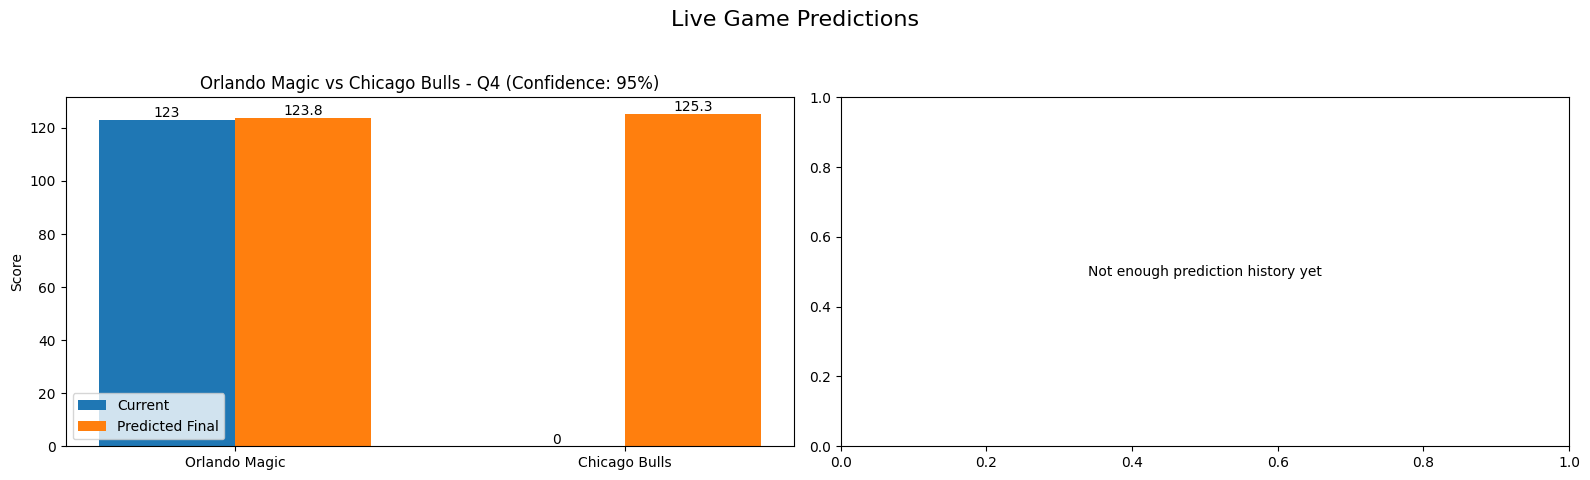

Live Game Predictions - 2025-03-07 03:49:26

Orlando Magic vs Chicago Bulls - Quarter 4 (Confidence: 95%)
Current Score: Orlando Magic 123.0 - Chicago Bulls 0.0
Predicted Final: Orlando Magic 123.8 - Chicago Bulls 125.3
Remaining Points: Orlando Magic +0.8, Chicago Bulls +125.3
Win Probability: 42.9%
Momentum: Trending toward away team (-0.33)
--------------------------------------------------------------------------------

Game Recommendations:

Orlando Magic vs Chicago Bulls:
• betting_tip: Competitive game; consider hedging
• momentum_advice: Strong momentum for Chicago Bulls
• spread_tip: Tight margin projected (1.4 points)
• over_under_tip: High-scoring game likely (249.1 points)
• clutch_tip: Close game in final minutes - monitor closely
----------------------------------------
[2025-03-07 03:49:26] INFO: Pipeline completed successfully


In [12]:
# Cell 6B: Comprehensive End-to-End Prediction with Detailed Logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import traceback
import sys
import os
import time

# Ensure we have access to the backend modules
backend_dir = os.path.join(os.getcwd(), "backend")
if os.path.exists(backend_dir) and backend_dir not in sys.path:
    sys.path.append(backend_dir)

# Custom imports
try:
    from caching.supabase_client import supabase
    import config
except ImportError as e:
    print(f"Import error: {e}")
    print("Creating mock config and supabase if needed")
    
    # Create minimal mock objects if needed
    if 'supabase' not in globals():
        class MockSupabase:
            def table(self, name):
                return self
            def select(self, cols):
                return self
            def eq(self, col, val):
                return self
            def execute(self):
                return type('obj', (object,), {'data': []})
        supabase = MockSupabase()
    
    if 'config' not in globals():
        config = type('obj', (object,), {'MODEL_PATH': 'models/score_prediction_model.pkl'})

def log_with_timestamp(message, level="INFO"):
    """Log a message with timestamp and log level."""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{timestamp}] {level}: {message}")

def handle_exception(e, context=""):
    """Handle an exception with proper logging."""
    log_with_timestamp(f"Error in {context}: {str(e)}", "ERROR")
    traceback.print_exc()
    return None

class NBAGamePredictor:
    """Comprehensive class for NBA game predictions with unified error handling."""
    
    def __init__(self):
        self.model = None
        self.feature_list = None
        self.prediction_history = {}
        self.debug_mode = True
        log_with_timestamp("Initializing NBA Game Predictor")
    
    def load_model(self):
        """Load the prediction model with error handling."""
        try:
            import joblib
            model_paths = [
                config.MODEL_PATH,
                'final_xgb_model.pkl',
                'enhanced_xgb_model.pkl',
                'models/score_prediction_model.pkl',
                'backend/models/score_prediction_model.pkl'
            ]
            
            for path in model_paths:
                try:
                    if os.path.exists(path):
                        model = joblib.load(path)
                        if hasattr(model, 'predict'):
                            log_with_timestamp(f"Successfully loaded model from {path}")
                            self.model = model
                            
                            # Determine model type and features
                            if hasattr(model, 'feature_importances_'):
                                feature_count = len(model.feature_importances_)
                                model_type = "enhanced" if feature_count > 8 else "original"
                                log_with_timestamp(f"Model type: {model_type} with {feature_count} features")
                            
                            return True
                except Exception as e:
                    log_with_timestamp(f"Failed to load model from {path}: {e}", "WARNING")
            
            # If no model could be loaded, create a fallback
            log_with_timestamp("No model could be loaded. Creating fallback model.", "WARNING")
            self.create_fallback_model()
            return True
            
        except Exception as e:
            handle_exception(e, "load_model")
            self.create_fallback_model()
            return False
    
    def create_fallback_model(self):
        """Create a simple fallback model when loading fails."""
        try:
            from sklearn.ensemble import GradientBoostingRegressor
            
            # Create a basic model with some reasonable parameters
            model = GradientBoostingRegressor(n_estimators=100, random_state=42)
            
            # Generate synthetic training data
            np.random.seed(42)
            n_samples = 1000
            
            # Create features similar to real NBA games
            X = pd.DataFrame({
                'home_q1': np.random.randint(20, 30, n_samples),
                'home_q2': np.random.randint(20, 30, n_samples),
                'home_q3': np.random.randint(20, 30, n_samples),
                'home_q4': np.random.randint(20, 30, n_samples),
                'score_ratio': np.random.uniform(0.4, 0.6, n_samples),
                'rolling_home_score': np.random.normal(106, 5, n_samples),
                'rolling_away_score': np.random.normal(103, 5, n_samples),
                'prev_matchup_diff': np.random.normal(3, 8, n_samples)
            })
            
            # Target is roughly the sum of the quarters with some noise
            y = X['home_q1'] + X['home_q2'] + X['home_q3'] + X['home_q4'] + \
                np.random.normal(0, 5, n_samples)
            
            # Train the model
            model.fit(X, y)
            log_with_timestamp("Fallback model created and trained successfully")
            self.model = model
            return True
            
        except Exception as e:
            handle_exception(e, "create_fallback_model")
            
            # As a last resort, create a dummy model
            class DummyModel:
                def predict(self, X):
                    return np.full(len(X), 105.0)
            
            log_with_timestamp("Created dummy model that always predicts 105", "WARNING")
            self.model = DummyModel()
            return False
    
    def get_feature_list(self):
        """Determine the appropriate feature list based on the model type."""
        if self.feature_list is not None:
            return self.feature_list
            
        # Try to determine from model
        is_enhanced_model = False
        if self.model is not None and hasattr(self.model, 'feature_importances_'):
            feature_count = len(self.model.feature_importances_)
            is_enhanced_model = (feature_count > 8)
        
        # Define both feature sets
        original_features = [
            'home_q1', 'home_q2', 'home_q3', 'home_q4',
            'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
        ]
        
        enhanced_features = [
            'home_q1', 'home_q2', 'home_q3', 'home_q4',
            'score_ratio', 'prev_matchup_diff',
            'rest_days_home', 'rest_days_away', 'rest_advantage',
            'is_back_to_back_home', 'is_back_to_back_away',
            'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
        ]
        
        self.feature_list = enhanced_features if is_enhanced_model else original_features
        log_with_timestamp(f"Using {'enhanced' if is_enhanced_model else 'original'} feature set")
        return self.feature_list
    
    def fetch_scheduled_games(self, date_str=None):
        """Fetch scheduled games for a specific date."""
        try:
            if date_str is None:
                date_str = datetime.now().strftime('%Y-%m-%d')
            
            response = supabase.table("nba_game_schedule").select("*").eq("game_date", date_str).execute()
            
            if not response.data:
                log_with_timestamp(f"No scheduled games found for {date_str}")
                return pd.DataFrame()
            
            log_with_timestamp(f"Found {len(response.data)} scheduled games for {date_str}")
            return pd.DataFrame(response.data)
            
        except Exception as e:
            return handle_exception(e, "fetch_scheduled_games")
    
    def fetch_live_games(self):
        """Fetch live games with improved error handling and validation."""
        try:
            today = datetime.now().strftime('%Y-%m-%d')
            yesterday = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
            
            # Try to get games with today's date first
            response = supabase.table("nba_live_game_stats").select("*").eq("game_date", today).execute()
            
            if not response.data:
                # Fall back to yesterday's date
                response = supabase.table("nba_live_game_stats").select("*").eq("game_date", yesterday).execute()
            
            if not response.data:
                # If still no data, try without date filter (but limit results)
                response = supabase.table("nba_live_game_stats").select("*").limit(5).execute()
            
            if response.data:
                log_with_timestamp(f"Found {len(response.data)} live games")
                live_df = pd.DataFrame(response.data)
                
                # Verify game data against schedule
                schedule_df = self.fetch_scheduled_games(today)
                if not schedule_df.empty:
                    live_df = self.match_live_to_schedule(live_df, schedule_df)
                
                return live_df
            else:
                log_with_timestamp("No live games found. Trying to get scheduled games.")
                # Try to get scheduled games instead
                schedule_df = self.fetch_scheduled_games(today)
                
                if not schedule_df.empty:
                    # Convert to live format with 0 scores
                    live_format = []
                    
                    for _, game in schedule_df.iterrows():
                        live_game = {
                            'game_id': game['game_id'],
                            'home_team': game['home_team'],
                            'away_team': game['away_team'],
                            'game_date': today,
                            'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
                            'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
                            'home_score': 0, 'away_score': 0,
                            'current_quarter': 0  # Pre-game
                        }
                        live_format.append(live_game)
                    
                    return pd.DataFrame(live_format)
                    
                log_with_timestamp("No scheduled games found. Using test data.")
                # Create sample test data
                test_data = [{
                    'game_id': 99901,
                    'home_team': 'Boston Celtics',
                    'away_team': 'Los Angeles Lakers',
                    'game_date': today,
                    'home_q1': 31, 'home_q2': 26, 'home_q3': 28, 'home_q4': 0,
                    'away_q1': 28, 'away_q2': 30, 'away_q3': 25, 'away_q4': 0,
                    'home_score': 85, 'away_score': 83,
                    'current_quarter': 3
                }]
                
                return pd.DataFrame(test_data)
                
        except Exception as e:
            return handle_exception(e, "fetch_live_games")
    
    def match_live_to_schedule(self, live_df, schedule_df):
        """Match live games to the official schedule."""
        try:
            if live_df.empty or schedule_df.empty:
                return live_df
            
            matched_games = []
            
            for _, live_game in live_df.iterrows():
                home_team = live_game.get('home_team', '').lower()
                away_team = live_game.get('away_team', '').lower()
                
                # Look for a match in the schedule
                matched = False
                
                for _, scheduled_game in schedule_df.iterrows():
                    sched_home = scheduled_game.get('home_team', '').lower()
                    sched_away = scheduled_game.get('away_team', '').lower()
                    
                    # Check for match, accounting for potential team name variations
                    if ((home_team in sched_home or sched_home in home_team) and 
                        (away_team in sched_away or sched_away in away_team)):
                        
                        # Use the scheduled game_id but keep other live data
                        live_game_dict = live_game.to_dict()
                        live_game_dict['game_id'] = scheduled_game['game_id']
                        # Use official team names
                        live_game_dict['home_team'] = scheduled_game['home_team']
                        live_game_dict['away_team'] = scheduled_game['away_team']
                        
                        matched_games.append(live_game_dict)
                        matched = True
                        break
                
                if not matched:
                    # Try again with reversed teams (home/away might be swapped)
                    for _, scheduled_game in schedule_df.iterrows():
                        sched_home = scheduled_game.get('home_team', '').lower()
                        sched_away = scheduled_game.get('away_team', '').lower()
                        
                        if ((home_team in sched_away or sched_away in home_team) and 
                            (away_team in sched_home or sched_home in away_team)):
                            
                            # Swap home/away data since teams are reversed
                            live_game_dict = {}
                            live_game_dict['game_id'] = scheduled_game['game_id']
                            live_game_dict['home_team'] = scheduled_game['home_team']
                            live_game_dict['away_team'] = scheduled_game['away_team']
                            live_game_dict['game_date'] = live_game.get('game_date')
                            
                            # Swap quarter scores
                            for q in range(1, 5):
                                live_game_dict[f'home_q{q}'] = live_game.get(f'away_q{q}', 0)
                                live_game_dict[f'away_q{q}'] = live_game.get(f'home_q{q}', 0)
                            
                            # Swap total scores
                            live_game_dict['home_score'] = live_game.get('away_score', 0)
                            live_game_dict['away_score'] = live_game.get('home_score', 0)
                            live_game_dict['current_quarter'] = live_game.get('current_quarter', 0)
                            
                            matched_games.append(live_game_dict)
                            matched = True
                            break
                
                if not matched and self.debug_mode:
                    # Include unmatched game but flag it
                    live_game_dict = live_game.to_dict()
                    live_game_dict['unmatched'] = True
                    matched_games.append(live_game_dict)
            
            if matched_games:
                result_df = pd.DataFrame(matched_games)
                log_with_timestamp(f"Matched {len(result_df)} games to schedule")
                return result_df
            else:
                return live_df
                
        except Exception as e:
            handle_exception(e, "match_live_to_schedule")
            return live_df
    
    def get_team_rolling_averages(self, days_lookback=60):
        """Get rolling scoring averages for all teams."""
        try:
            # Calculate threshold date
            threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
            
            # Query historical data
            response = supabase.table("nba_historical_game_stats").select("*").gte("game_date", threshold_date).execute()
            
            if not response.data:
                log_with_timestamp(f"No historical data found within {days_lookback} days")
                return {}
            
            # Process data
            df = pd.DataFrame(response.data)
            df['game_date'] = pd.to_datetime(df['game_date'])
            df = df.sort_values('game_date')
            
            # Calculate averages
            team_avgs = {}
            all_teams = set()
            
            if 'home_team' in df.columns:
                all_teams.update(df['home_team'].unique())
            if 'away_team' in df.columns:
                all_teams.update(df['away_team'].unique())
            
            for team in all_teams:
                # Get home games
                home_games = df[df['home_team'] == team][['game_date', 'home_score']].rename(
                    columns={'home_score': 'score'})
                
                # Get away games
                away_games = df[df['away_team'] == team][['game_date', 'away_score']].rename(
                    columns={'away_score': 'score'})
                
                # Combine and sort
                team_games = pd.concat([home_games, away_games]).sort_values('game_date')
                
                if len(team_games) > 0:
                    # Calculate average (prioritize last 5 games)
                    if len(team_games) >= 5:
                        recent_games = team_games.tail(5)
                        team_avgs[team] = recent_games['score'].mean()
                    else:
                        team_avgs[team] = team_games['score'].mean()
                else:
                    # Default if no games found
                    team_avgs[team] = 105.0
            
            log_with_timestamp(f"Calculated rolling averages for {len(team_avgs)} teams")
            return team_avgs
            
        except Exception as e:
            handle_exception(e, "get_team_rolling_averages")
            # Return default
            return {'DEFAULT': 105.0}
    
    def get_previous_matchup_diff(self, home_team, away_team, max_lookback=5):
        """Get point differential from previous matchups between two teams."""
        try:
            # Look for direct matchups first
            response_home = supabase.table("nba_historical_game_stats").select("*")\
                .eq("home_team", home_team)\
                .eq("away_team", away_team)\
                .order('game_date', desc=True)\
                .limit(max_lookback).execute()
                
            response_away = supabase.table("nba_historical_game_stats").select("*")\
                .eq("home_team", away_team)\
                .eq("away_team", home_team)\
                .order('game_date', desc=True)\
                .limit(max_lookback).execute()
            
            # Combine results
            home_matchups = response_home.data
            away_matchups = response_away.data
            matchups = home_matchups + away_matchups
            
            if not matchups:
                if self.debug_mode:
                    log_with_timestamp(f"No previous matchups found between {home_team} and {away_team}")
                return 0
            
            # Calculate point differential from home team perspective
            differentials = []
            for game in matchups:
                if game['home_team'] == home_team and game['away_team'] == away_team:
                    diff = game['home_score'] - game['away_score']
                elif game['home_team'] == away_team and game['away_team'] == home_team:
                    diff = game['away_score'] - game['home_score']
                else:
                    continue
                differentials.append(diff)
            
            avg_diff = sum(differentials) / len(differentials) if differentials else 0
            
            if self.debug_mode:
                log_with_timestamp(f"Average diff for {home_team} vs {away_team}: {avg_diff:.1f} points (from {len(differentials)} games)")
            
            return avg_diff
            
        except Exception as e:
            handle_exception(e, f"get_previous_matchup_diff({home_team}, {away_team})")
            return 0
    
    def prepare_features(self, live_games_df):
        """Prepare features for prediction from live game data."""
        try:
            if live_games_df is None or live_games_df.empty:
                log_with_timestamp("No games provided for feature preparation")
                return pd.DataFrame()
            
            # Get the feature list expected by the model
            expected_features = self.get_feature_list()
            
            # Get team averages for rolling scores
            team_avgs = self.get_team_rolling_averages()
            
            # Clean input data and ensure proper format
            input_df = validate_and_clean_features(live_games_df, expected_features=None, verbose=False)
            
            # Process each game to create features
            features_list = []
            
            for _, game in input_df.iterrows():
                feature_dict = {}
                
                # Copy game identifying information
                feature_dict['game_id'] = game.get('game_id')
                feature_dict['home_team'] = game.get('home_team')
                feature_dict['away_team'] = game.get('away_team')
                
                # Get quarter scores
                for q in range(1, 5):
                    q_key = f'home_q{q}'
                    feature_dict[q_key] = float(game.get(q_key, 0) or 0)
                
                # Determine current quarter if not provided
                if 'current_quarter' not in game:
                    current_q = 0
                    for q in range(1, 5):
                        if float(game.get(f'home_q{q}', 0) or 0) > 0:
                            current_q = q
                    feature_dict['current_quarter'] = current_q
                else:
                    feature_dict['current_quarter'] = int(game.get('current_quarter', 0))
                
                # Calculate score ratio if not provided
                if 'score_ratio' not in game:
                    home_score = float(game.get('home_score', 0) or 0)
                    away_score = float(game.get('away_score', 0) or 0)
                    total_score = home_score + away_score
                    
                    if total_score > 0:
                        feature_dict['score_ratio'] = home_score / total_score
                    else:
                        feature_dict['score_ratio'] = 0.5
                else:
                    feature_dict['score_ratio'] = float(game.get('score_ratio', 0.5))
                
                # Get team rolling averages
                feature_dict['rolling_home_score'] = team_avgs.get(game.get('home_team'), 105.0)
                feature_dict['rolling_away_score'] = team_avgs.get(game.get('away_team'), 105.0)
                
                # Get previous matchup difference
                feature_dict['prev_matchup_diff'] = self.get_previous_matchup_diff(
                    game.get('home_team'), game.get('away_team'))
                
                # Calculate momentum features if needed
                current_quarter = feature_dict['current_quarter']
                
                # Initialize momentum features
                feature_dict['q1_to_q2_momentum'] = 0
                feature_dict['q2_to_q3_momentum'] = 0
                feature_dict['q3_to_q4_momentum'] = 0
                feature_dict['cumulative_momentum'] = 0
                
                # Calculate appropriate momentum features for current game state
                if current_quarter >= 2:
                    home_q1 = float(game.get('home_q1', 0) or 0)
                    home_q2 = float(game.get('home_q2', 0) or 0)
                    away_q1 = float(game.get('away_q1', 0) or 0)
                    away_q2 = float(game.get('away_q2', 0) or 0)
                    
                    feature_dict['q1_to_q2_momentum'] = (home_q2 - home_q1) - (away_q2 - away_q1)
                    
                if current_quarter >= 3:
                    home_q3 = float(game.get('home_q3', 0) or 0)
                    away_q3 = float(game.get('away_q3', 0) or 0)
                    
                    feature_dict['q2_to_q3_momentum'] = (home_q3 - home_q2) - (away_q3 - away_q2)
                    
                if current_quarter >= 4:
                    home_q4 = float(game.get('home_q4', 0) or 0)
                    away_q4 = float(game.get('away_q4', 0) or 0)
                    
                    feature_dict['q3_to_q4_momentum'] = (home_q4 - home_q3) - (away_q4 - away_q3)
                
                # Calculate weighted momentum
                weights = [0.2, 0.3, 0.5]  # Weights for Q1→Q2, Q2→Q3, Q3→Q4
                
                if current_quarter == 2:
                    feature_dict['cumulative_momentum'] = feature_dict['q1_to_q2_momentum']
                elif current_quarter == 3:
                    feature_dict['cumulative_momentum'] = (
                        feature_dict['q1_to_q2_momentum'] * weights[0] + 
                        feature_dict['q2_to_q3_momentum'] * weights[1]
                    ) / (weights[0] + weights[1])
                elif current_quarter >= 4:
                    feature_dict['cumulative_momentum'] = (
                        feature_dict['q1_to_q2_momentum'] * weights[0] + 
                        feature_dict['q2_to_q3_momentum'] * weights[1] + 
                        feature_dict['q3_to_q4_momentum'] * weights[2]
                    ) / sum(weights)
                
                # Normalize momentum to [-1, 1]
                if feature_dict['cumulative_momentum'] != 0:
                    feature_dict['cumulative_momentum'] = max(min(
                        feature_dict['cumulative_momentum'] / 15.0, 1.0), -1.0)
                
                # Add rest and back-to-back features
                feature_dict['rest_days_home'] = float(game.get('rest_days_home', 2))
                feature_dict['rest_days_away'] = float(game.get('rest_days_away', 2))
                feature_dict['rest_advantage'] = float(game.get('rest_advantage', 0))
                feature_dict['is_back_to_back_home'] = float(game.get('is_back_to_back_home', 0))
                feature_dict['is_back_to_back_away'] = float(game.get('is_back_to_back_away', 0))
                
                features_list.append(feature_dict)
            
            # Create DataFrame and ensure all expected features exist
            features_df = pd.DataFrame(features_list)
            
            # Make sure all expected features are present with proper types
            for feature in expected_features:
                if feature not in features_df.columns:
                    log_with_timestamp(f"Adding missing feature: {feature}")
                    features_df[feature] = 0
                
                # Convert to numeric
                features_df[feature] = pd.to_numeric(features_df[feature], errors='coerce').fillna(0)
            
            log_with_timestamp(f"Prepared features for {len(features_df)} games")
            return features_df
            
        except Exception as e:
            return handle_exception(e, "prepare_features")
    
    def predict_game_scores(self, features_df):
        """Make predictions using the model."""
        try:
            if features_df is None or features_df.empty:
                log_with_timestamp("No features provided for prediction")
                return pd.DataFrame()
            
            # Ensure model is loaded
            if self.model is None:
                self.load_model()
            
            if self.model is None:
                log_with_timestamp("No model available for prediction", "ERROR")
                return pd.DataFrame()
            
            # Get required features
            expected_features = self.get_feature_list()
            
            # Select only the expected features in the right order
            X = features_df[expected_features]
            
            # Get predictions
            predictions = self.model.predict(X)
            
            # Create results DataFrame
            results = []
            
            for i, (_, game) in enumerate(features_df.iterrows()):
                game_id = game['game_id']
                home_team = game['home_team']
                away_team = game['away_team']
                current_quarter = int(game['current_quarter'])
                
                # Get current scores
                home_score = 0
                away_score = 0
                
                for q in range(1, current_quarter + 1):
                    home_score += float(game.get(f'home_q{q}', 0) or 0)
                    away_score += float(game.get(f'away_q{q}', 0) or 0)
                
                # Get prediction
                predicted_home_final = float(predictions[i])
                
                # Calculate away score prediction
                prev_matchup_diff = float(game.get('prev_matchup_diff', 0))
                
                # Scale effect based on game progress
                diff_weight = min(0.3 + (0.1 * current_quarter), 0.6)
                
                # Factor in momentum if available
                momentum_adj = 0
                if 'cumulative_momentum' in game:
                    momentum = float(game['cumulative_momentum'])
                    momentum_adj = momentum * 3.0  # Scale to points
                
                # Calculate predicted away score
                predicted_away_final = predicted_home_final - (prev_matchup_diff * diff_weight) - momentum_adj
                
                # Ensure predictions aren't less than current scores
                predicted_home_final = max(predicted_home_final, home_score)
                predicted_away_final = max(predicted_away_final, away_score)
                
                # Calculate win probability
                score_diff = predicted_home_final - predicted_away_final
                game_progress = min(current_quarter / 4.0, 1.0)
                k_factor = 0.05 + (game_progress * 0.15)
                win_probability = 1.0 / (1.0 + np.exp(-k_factor * score_diff))
                
                # Store results
                result = {
                    'game_id': game_id,
                    'home_team': home_team,
                    'away_team': away_team,
                    'current_quarter': current_quarter,
                    'current_home_score': home_score,
                    'current_away_score': away_score,
                    'predicted_home_final': predicted_home_final,
                    'predicted_away_final': predicted_away_final,
                    'remaining_home_points': predicted_home_final - home_score,
                    'remaining_away_points': predicted_away_final - away_score,
                    'win_probability': win_probability,
                    'confidence': self.calculate_confidence(current_quarter),
                    'momentum_shift': float(game.get('cumulative_momentum', 0)),
                    'timestamp': datetime.now()
                }
                
                # Add to prediction history
                if game_id not in self.prediction_history:
                    self.prediction_history[game_id] = []
                self.prediction_history[game_id].append(result)
                
                results.append(result)
            
            log_with_timestamp(f"Generated predictions for {len(results)} games")
            return pd.DataFrame(results)
            
        except Exception as e:
            return handle_exception(e, "predict_game_scores")
    
    def calculate_confidence(self, quarter):
        """Calculate prediction confidence based on quarter."""
        confidence_map = {
            0: 30,  # Pre-game
            1: 45,  # 1st quarter
            2: 65,  # 2nd quarter
            3: 80,  # 3rd quarter
            4: 95   # 4th quarter
        }
        return confidence_map.get(quarter, 40)  # Default to 40% if unknown quarter
    
    def visualize_predictions(self, predictions_df):
        """Create visualization of game predictions."""
        try:
            if predictions_df is None or predictions_df.empty:
                log_with_timestamp("No predictions to visualize")
                return
            
            # Determine number of games and setup figure
            n_games = len(predictions_df)
            fig, axs = plt.subplots(n_games, 2, figsize=(16, 5 * n_games))
            fig.suptitle('Live Game Predictions', fontsize=16)
            
            # Handle single game case
            if n_games == 1:
                axs = np.array([axs])
            
            # Create visualizations for each game
            for i, (_, game) in enumerate(predictions_df.iterrows()):
                # Create bar chart for current vs predicted scores
                ax_scores = axs[i, 0]
                
                teams = [game['home_team'], game['away_team']]
                current_scores = [game['current_home_score'], game['current_away_score']]
                predicted_scores = [game['predicted_home_final'], game['predicted_away_final']]
                
                x = np.arange(len(teams))
                width = 0.35
                
                ax_scores.bar(x - width/2, current_scores, width, label='Current')
                ax_scores.bar(x + width/2, predicted_scores, width, label='Predicted Final')
                
                ax_scores.set_xticks(x)
                ax_scores.set_xticklabels(teams)
                ax_scores.legend()
                
                # Add confidence and quarter to title
                confidence = game.get('confidence', 50)
                current_quarter = game.get('current_quarter', 0)
                
                quarter_text = "Pre-Game" if current_quarter == 0 else f"Q{current_quarter}"
                ax_scores.set_title(f"{game['home_team']} vs {game['away_team']} - {quarter_text} (Confidence: {confidence}%)")
                ax_scores.set_ylabel('Score')
                
                # Add score labels
                for j, v in enumerate(current_scores):
                    ax_scores.text(j - width/2, v + 1, str(int(v)), ha='center')
                
                for j, v in enumerate(predicted_scores):
                    ax_scores.text(j + width/2, v + 1, f"{v:.1f}", ha='center')
                
                # Create prediction history chart
                ax_history = axs[i, 1]
                game_id = game['game_id']
                
                if game_id in self.prediction_history and len(self.prediction_history[game_id]) > 1:
                    history = pd.DataFrame(self.prediction_history[game_id])
                    
                    ax_history.plot(history['timestamp'], history['predicted_home_final'], 
                                  label=f"{game['home_team']} Final", marker='o')
                    ax_history.plot(history['timestamp'], history['predicted_away_final'], 
                                  label=f"{game['away_team']} Final", marker='s')
                    
                    ax_history.set_title("Prediction Evolution")
                    ax_history.set_xlabel("Time")
                    ax_history.set_ylabel("Predicted Score")
                    ax_history.legend()
                    
                    # Format time axis
                    ax_history.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
                    plt.setp(ax_history.xaxis.get_majorticklabels(), rotation=45)
                else:
                    ax_history.text(0.5, 0.5, "Not enough prediction history yet", 
                                  horizontalalignment='center', verticalalignment='center',
                                  transform=ax_history.transAxes)
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            
            # Print text summary
            print(f"Live Game Predictions - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            print("=" * 80)
            
            for _, game in predictions_df.iterrows():
                quarter_text = "Pre-Game" if game['current_quarter'] == 0 else f"Quarter {game['current_quarter']}"
                confidence = game.get('confidence', 50)
                
                print(f"\n{game['home_team']} vs {game['away_team']} - {quarter_text} (Confidence: {confidence}%)")
                print(f"Current Score: {game['home_team']} {game['current_home_score']} - {game['away_team']} {game['current_away_score']}")
                print(f"Predicted Final: {game['home_team']} {game['predicted_home_final']:.1f} - {game['away_team']} {game['predicted_away_final']:.1f}")
                print(f"Remaining Points: {game['home_team']} +{game['remaining_home_points']:.1f}, {game['away_team']} +{game['remaining_away_points']:.1f}")
                print(f"Win Probability: {game['win_probability']:.1%}")
                
                if abs(game.get('momentum_shift', 0)) > 0.2:
                    momentum_direction = "home team" if game['momentum_shift'] > 0 else "away team"
                    print(f"Momentum: Trending toward {momentum_direction} ({game['momentum_shift']:.2f})")
                
                print("-" * 80)
            
        except Exception as e:
            handle_exception(e, "visualize_predictions")
    
    def generate_recommendations(self, predictions_df):
        """Generate betting and fantasy recommendations based on predictions."""
        try:
            if predictions_df is None or predictions_df.empty:
                log_with_timestamp("No predictions for recommendations")
                return {}
            
            recommendations = {}
            
            for _, game in predictions_df.iterrows():
                game_id = game['game_id']
                home_team = game['home_team']
                away_team = game['away_team']
                game_key = f"{home_team} vs {away_team}"
                
                # Extract values needed for recommendations
                win_prob = float(game.get('win_probability', 0.5))
                momentum = float(game.get('momentum_shift', 0))
                projected_margin = float(game['predicted_home_final'] - game['predicted_away_final'])
                total_projected = float(game['predicted_home_final'] + game['predicted_away_final'])
                quarter = int(game.get('current_quarter', 0))
                time_remaining = (4 - quarter) * 12 if quarter <= 4 else 0
                
                game_recs = {}
                
                # Generate betting recommendations
                if quarter >= 3 and win_prob > 0.9:
                    game_recs["betting_tip"] = f"Strong confidence in {home_team} win ({win_prob:.1%})"
                elif win_prob > 0.75:
                    game_recs["betting_tip"] = f"Home advantage favors {home_team} ({win_prob:.1%})"
                elif win_prob < 0.3:
                    game_recs["betting_tip"] = f"Consider {away_team} for the upset ({(1-win_prob):.1%})"
                else:
                    game_recs["betting_tip"] = "Competitive game; consider hedging"
                
                # Momentum advice
                if momentum > 0.3:
                    game_recs["momentum_advice"] = f"Strong momentum for {home_team}"
                elif momentum < -0.3:
                    game_recs["momentum_advice"] = f"Strong momentum for {away_team}"
                else:
                    game_recs["momentum_advice"] = "Balanced momentum"
                
                # Spread recommendation
                if abs(projected_margin) >= 8:
                    favorite = home_team if projected_margin > 0 else away_team
                    underdog = away_team if projected_margin > 0 else home_team
                    game_recs["spread_tip"] = f"{favorite} projected to cover against {underdog} ({abs(projected_margin):.1f} point margin)"
                else:
                    game_recs["spread_tip"] = f"Tight margin projected ({abs(projected_margin):.1f} points)"
                
                # Over/Under recommendation
                league_avg_total = 220  # Typical NBA game total
                if total_projected > league_avg_total + 10:
                    game_recs["over_under_tip"] = f"High-scoring game likely ({total_projected:.1f} points)"
                elif total_projected < league_avg_total - 10:
                    game_recs["over_under_tip"] = f"Low-scoring game likely ({total_projected:.1f} points)"
                else:
                    game_recs["over_under_tip"] = f"Projected total: {total_projected:.1f} points"
                
                # Special recommendations for different game states
                if quarter == 4 and time_remaining < 5 and abs(projected_margin) < 6:
                    game_recs["clutch_tip"] = "Close game in final minutes - monitor closely"
                
                if quarter < 2:
                    game_recs["early_game_tip"] = "Early game - watch for team adjustments"
                
                recommendations[game_key] = game_recs
            
            return recommendations
            
        except Exception as e:
            handle_exception(e, "generate_recommendations")
            return {}
    
    def run_full_prediction_pipeline(self):
        """Execute the complete prediction pipeline from data retrieval to visualization."""
        try:
            # Step 1: Load model if not already loaded
            if self.model is None:
                success = self.load_model()
                if not success:
                    log_with_timestamp("Failed to load model", "ERROR")
                    return None
            
            # Step 2: Fetch live games
            live_games_df = self.fetch_live_games()
            if live_games_df is None or live_games_df.empty:
                log_with_timestamp("No games available for prediction", "WARNING")
                return None
            
            log_with_timestamp(f"Processing {len(live_games_df)} games")
            
            # Step 3: Prepare features
            features_df = self.prepare_features(live_games_df)
            if features_df is None or features_df.empty:
                log_with_timestamp("Failed to prepare features", "ERROR")
                return None
            
            # Step 4: Generate predictions
            predictions_df = self.predict_game_scores(features_df)
            if predictions_df is None or predictions_df.empty:
                log_with_timestamp("Failed to generate predictions", "ERROR")
                return None
            
            # Step 5: Visualize predictions
            self.visualize_predictions(predictions_df)
            
            # Step 6: Generate recommendations
            recommendations = self.generate_recommendations(predictions_df)
            
            # Print recommendations
            if recommendations:
                print("\nGame Recommendations:")
                print("=" * 80)
                
                for game_name, recs in recommendations.items():
                    print(f"\n{game_name}:")
                    for rec_type, recommendation in recs.items():
                        print(f"• {rec_type}: {recommendation}")
                    print("-" * 40)
            
            return predictions_df
            
        except Exception as e:
            handle_exception(e, "run_full_prediction_pipeline")
            return None

def validate_and_clean_features(df, expected_features=None, verbose=True):
    """
    Validates and cleans feature data for prediction.
    Extracted from Cell 4 for reuse.
    """
    if df is None or df.empty:
        if verbose:
            print("No data provided for validation")
        return pd.DataFrame()
    
    # Make a copy to avoid modifying the original
    clean_df = df.copy()
    
    # Auto-detect expected features if not provided
    if expected_features is None:
        if 'q1_to_q2_momentum' in clean_df.columns:
            # Looks like enhanced feature set
            expected_features = [
                'home_q1', 'home_q2', 'home_q3', 'home_q4',
                'score_ratio', 'prev_matchup_diff',
                'rest_days_home', 'rest_days_away', 'rest_advantage',
                'is_back_to_back_home', 'is_back_to_back_away',
                'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
            ]
        else:
            # Assume original feature set
            expected_features = [
                'home_q1', 'home_q2', 'home_q3', 'home_q4',
                'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
            ]
    
    if verbose:
        print(f"Validating {len(df)} rows against {len(expected_features)} expected features")
    
    # Reasonable default values for each feature type
    default_values = {
        'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
        'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
        'score_ratio': 0.5,
        'rolling_home_score': 105.0, 'rolling_away_score': 105.0,
        'prev_matchup_diff': 0,
        'rest_days_home': 2, 'rest_days_away': 2, 'rest_advantage': 0,
        'is_back_to_back_home': 0, 'is_back_to_back_away': 0,
        'q1_to_q2_momentum': 0, 'q2_to_q3_momentum': 0, 'q3_to_q4_momentum': 0, 'cumulative_momentum': 0,
        'current_quarter': 0,
        'home_score': 0, 'away_score': 0
    }
    
    # Ensure all expected features exist with correct types
    for feature in expected_features:
        # Add missing columns
        if feature not in clean_df.columns:
            if verbose:
                print(f"Adding missing feature: {feature} with default {default_values.get(feature, 0)}")
            clean_df[feature] = default_values.get(feature, 0)
        
        # Skip non-numeric fields
        if feature in ['game_id', 'home_team', 'away_team', 'game_date']:
            continue
            
        # Convert to numeric, replace NaN with appropriate defaults
        clean_df[feature] = pd.to_numeric(clean_df[feature], errors='coerce')
        null_count = clean_df[feature].isna().sum()
        
        if null_count > 0:
            if verbose:
                print(f"Fixed {null_count} NaN values in {feature}")
            clean_df[feature] = clean_df[feature].fillna(default_values.get(feature, 0))
    
    return clean_df

# Create and run the complete pipeline
log_with_timestamp("Starting comprehensive prediction pipeline")
predictor = NBAGamePredictor()
prediction_results = predictor.run_full_prediction_pipeline()

if prediction_results is not None:
    log_with_timestamp("Pipeline completed successfully")
else:
    log_with_timestamp("Pipeline failed to complete", "ERROR")

In [13]:
# Cell 7 - Enhanced Live Prediction Function with Momentum and Win Probability

# Fix the import structure to avoid the datetime conflict
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import joblib
from caching.supabase_client import supabase
import config
import math
import traceback

################################################################################
#                          CORE HELPER FUNCTIONS                               #
################################################################################

def calculate_win_probability(home_score, away_score, quarter, time_remaining=None):
    """
    Calculate win probability for the home team based on score differential and game stage.
    Uses a simple logistic function that gives higher certainty later in the game.
    """
    score_diff = home_score - away_score
    
    # Determine game progress (0 to 1, where 1 is game over)
    if time_remaining is not None:
        # If we have detailed time remaining
        total_time = 48.0  # 48 minutes in a game
        elapsed_time = total_time - time_remaining
        game_progress = elapsed_time / total_time
    else:
        # Approximate by quarter
        game_progress = min(quarter / 4.0, 1.0)
    
    # Adjust K factor (steepness of the curve) based on game progress
    # Higher K in late game = more certainty about outcome
    k_factor = 0.05 + (game_progress * 0.15)
    
    # Logistic function to convert score differential to win probability
    win_prob = 1.0 / (1.0 + math.exp(-k_factor * score_diff))
    
    return win_prob

def calculate_momentum(home_q1, home_q2, home_q3, home_q4, 
                       away_q1, away_q2, away_q3, away_q4, current_quarter):
    """
    Calculate momentum based on quarter-to-quarter score changes.
    Returns a value between -1 and 1, where positive values indicate home team momentum.
    """
    # Initialize values - cast to float and use 0 if None/NaN
    h_q1 = float(home_q1 or 0)
    h_q2 = float(home_q2 or 0) 
    h_q3 = float(home_q3 or 0)
    h_q4 = float(home_q4 or 0)
    
    a_q1 = float(away_q1 or 0)
    a_q2 = float(away_q2 or 0)
    a_q3 = float(away_q3 or 0)
    a_q4 = float(away_q4 or 0)
    
    momentum_shifts = []
    
    # Only calculate momentum for quarters we have data for
    if current_quarter >= 2 and h_q1 > 0 and h_q2 > 0:
        # Q1 to Q2 momentum
        q1_to_q2 = (h_q2 - h_q1) - (a_q2 - a_q1)
        # Cap at +/- 15 points to avoid extreme values
        q1_to_q2 = max(min(q1_to_q2, 15), -15)
        momentum_shifts.append((q1_to_q2, 0.2))  # Weight: 0.2
    
    if current_quarter >= 3 and h_q2 > 0 and h_q3 > 0:
        # Q2 to Q3 momentum
        q2_to_q3 = (h_q3 - h_q2) - (a_q3 - a_q2)
        # Cap at +/- 15 points
        q2_to_q3 = max(min(q2_to_q3, 15), -15)
        momentum_shifts.append((q2_to_q3, 0.3))  # Weight: 0.3
    
    if current_quarter >= 4 and h_q3 > 0 and h_q4 > 0:
        # Q3 to Q4 momentum
        q3_to_q4 = (h_q4 - h_q3) - (a_q4 - a_q3)
        # Cap at +/- 15 points
        q3_to_q4 = max(min(q3_to_q4, 15), -15)
        momentum_shifts.append((q3_to_q4, 0.5))  # Weight: 0.5
    
    # If we don't have enough data, return 0 (neutral momentum)
    if not momentum_shifts:
        return 0.0
    
    # Calculate weighted momentum
    total_momentum = sum(m[0] * m[1] for m in momentum_shifts)
    total_weight = sum(m[1] for m in momentum_shifts)
    
    if total_weight > 0:
        weighted_momentum = total_momentum / total_weight
    else:
        return 0.0
    
    # Normalize to [-1, 1] using a reasonable max quarter differential of 15
    normalized_momentum = max(min(weighted_momentum / 15.0, 1.0), -1.0)
    
    return normalized_momentum

################################################################################
#                        GAME DATA RETRIEVAL FUNCTIONS                         #
################################################################################

def get_team_rolling_averages(days_lookback=60):
    """
    Retrieves the rolling scoring average for each team from historical data.
    
    Args:
        days_lookback: Number of days to look back for calculating the average
        
    Returns:
        Dictionary mapping team names to their rolling scoring average
    """
    # Calculate the date threshold
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    
    try:
        # Fetch recent historical game data
        response = supabase.table("nba_historical_game_stats").select("*").gte("game_date", threshold_date).execute()
        historical_data = response.data
        
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return {}
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        df = df.sort_values('game_date')
        
        # Initialize dictionary for team averages
        team_avgs = {}
        
        # Get unique teams
        all_teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        for team in all_teams:
            # Get home games where team is home
            home_games = df[df['home_team'] == team][['game_date', 'home_score']].rename(
                columns={'home_score': 'score'})
            
            # Get away games where team is away
            away_games = df[df['away_team'] == team][['game_date', 'away_score']].rename(
                columns={'away_score': 'score'})
            
            # Combine all games
            team_games = pd.concat([home_games, away_games]).sort_values('game_date')
            
            if not team_games.empty:
                # Calculate recent average (last 5 games if available)
                recent_games = team_games.tail(5)
                team_avgs[team] = recent_games['score'].mean()
            else:
                # Fallback to a reasonable default
                team_avgs[team] = 105.0  # NBA average is approximately 100-110 points per game
        
        return team_avgs
    except Exception as e:
        print(f"Error getting team rolling averages: {e}")
        return {}

def get_previous_matchup_diff(home_team, away_team, max_lookback=5):
    """Gets the point differential from previous matchups between two teams."""
    try:
        # Normalize team names for consistent comparison
        home_team_norm = normalize_team_name(home_team)
        away_team_norm = normalize_team_name(away_team)
        
        # Use separate queries for home and away configurations
        response_home = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", home_team)\
            .eq("away_team", away_team)\
            .order('game_date', desc=True)\
            .limit(max_lookback).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", away_team)\
            .eq("away_team", home_team)\
            .order('game_date', desc=True)\
            .limit(max_lookback).execute()
        
        # Combine results
        home_matchups = response_home.data or []
        away_matchups = response_away.data or []
        matchups = home_matchups + away_matchups
        
        # Sort by date (most recent first)
        if matchups:
            try:
                matchups.sort(key=lambda x: x.get('game_date', ''), reverse=True)
                matchups = matchups[:max_lookback]
            except Exception as e:
                print(f"Error sorting matchups: {e}")
        
        if not matchups:
            return 0
        
        # Calculate point differential from home team perspective
        differentials = []
        for game in matchups:
            try:
                if game['home_team'] == home_team and game['away_team'] == away_team:
                    diff = game['home_score'] - game['away_score']
                elif game['home_team'] == away_team and game['away_team'] == home_team:
                    diff = game['away_score'] - game['home_score']
                else:
                    continue
                differentials.append(diff)
            except (KeyError, TypeError) as e:
                print(f"Error processing matchup: {e}")
                continue
        
        # Calculate mean differential, with limit to prevent extreme values
        if differentials:
            avg_diff = sum(differentials) / len(differentials)
            return max(min(avg_diff, 15), -15)  # Cap at +/- 15 points
        return 0
    except Exception as e:
        print(f"Error getting previous matchups: {e}")
        return 0

def get_rest_data(team, game_date):
    """
    Determines rest days for a team before a specific game
    """
    # Convert game_date to datetime if it's a string
    if isinstance(game_date, str):
        try:
            game_date = pd.to_datetime(game_date)
        except:
            # If conversion fails, return default values
            return {'rest_days': 2, 'is_back_to_back': False}
    
    # Look back up to 10 days to find the team's previous game
    lookback_date = (game_date - timedelta(days=10)).strftime('%Y-%m-%d')
    
    try:
        # Find team's previous games (as home or away)
        response_home = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("home_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date', desc=True)\
            .limit(1).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("away_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date', desc=True)\
            .limit(1).execute()
        
        # Combine results to find the most recent game
        prev_games = response_home.data + response_away.data
        if not prev_games:
            # No previous game found in the lookback period
            return {'rest_days': 3, 'is_back_to_back': False}  # Default to 3 days rest
        
        # Sort by date, most recent first
        prev_games.sort(key=lambda x: x['game_date'], reverse=True)
        prev_game_date = pd.to_datetime(prev_games[0]['game_date'])
        
        # Calculate days between games
        rest_days = (game_date - prev_game_date).days
        is_back_to_back = (rest_days == 1)
        
        # Cap rest days at reasonable values
        rest_days = max(min(rest_days, 10), 1)
        
        return {'rest_days': rest_days, 'is_back_to_back': is_back_to_back}
    
    except Exception as e:
        print(f"Error getting rest data for {team}: {e}")
        return {'rest_days': 2, 'is_back_to_back': False}  # Default to 2 days rest

def normalize_team_name(name):
    """Normalize team names for consistent matching"""
    if not name:
        return ""
        
    # Convert to string and lowercase
    name = str(name).lower().strip()
    
    # Standard team name mappings
    mappings = {
        'lakers': 'los angeles lakers',
        'la lakers': 'los angeles lakers',
        'clippers': 'los angeles clippers',
        'la clippers': 'los angeles clippers',
        'blazers': 'portland trail blazers',
        'sixers': 'philadelphia 76ers',
        'philly': 'philadelphia 76ers',
        'knicks': 'new york knicks',
        'ny knicks': 'new york knicks',
        'nets': 'brooklyn nets',
        'mavs': 'dallas mavericks',
        'cavs': 'cleveland cavaliers',
        'wolves': 'minnesota timberwolves',
        't-wolves': 'minnesota timberwolves'
    }
    
    # Check if the name is in mappings
    for key, value in mappings.items():
        if key in name:
            return value
            
    return name

################################################################################
#                          MAIN INFERENCE FUNCTION                             #
################################################################################

def run_live_inference():
    """
    Enhanced run_inference function that calculates momentum and win probability
    """
    # Make sure model is available in the global scope
    if 'model' not in globals() or model is None:
        print("Warning: No model available in the global scope. Predictions may not be possible.")
    
    # Define the expected features
    expected_features = [
        'home_q1', 
        'home_q2', 
        'home_q3', 
        'home_q4', 
        'score_ratio',
        'prev_matchup_diff',
        'rest_days_home',
        'rest_days_away',
        'rest_advantage',
        'is_back_to_back_home',
        'is_back_to_back_away',
        'q1_to_q2_momentum',
        'q2_to_q3_momentum',
        'q3_to_q4_momentum',
        'cumulative_momentum'
    ]
    
    # Fetch live game data
    try:
        response = supabase.table("nba_live_game_stats").select("*").execute()
        live_data = response.data
    except Exception as e:
        print(f"Error fetching live game data: {e}")
        traceback.print_exc()
        live_data = None
    
    if not live_data:
        print("No live game data available.")
        # Try to fetch upcoming games
        try:
            if 'model' in globals() and model is not None:
                # Check if we can access the schedule
                try:
                    response = supabase.table("nba_game_schedule").select("*").limit(1).execute()
                    upcoming_predictions = predict_upcoming_games(model, expected_features)
                    if upcoming_predictions is not None:
                        print("Generated predictions for upcoming games instead.")
                        return upcoming_predictions
                except Exception as e:
                    print(f"Schedule access error: {e}")
                    print("Using recent games from historical data instead...")
                    upcoming_games = get_recent_games_as_upcoming()
                    if upcoming_games is not None:
                        return upcoming_games
        except Exception as e:
            print(f"Error finding alternative games to predict: {e}")
            traceback.print_exc()
        return None
    
    live_df = pd.DataFrame(live_data)
    
    # Match against official schedule if available
    try:
        # First, check if schedule data is available
        today = datetime.now().strftime('%Y-%m-%d')
        response = supabase.table("nba_game_schedule").select("*").eq("game_date", today).execute()
        
        if response.data:
            schedule_df = pd.DataFrame(response.data)
            # Check if we have games to match
            if not schedule_df.empty and not live_df.empty:
                live_df = match_live_to_scheduled(live_df, schedule_df)
                print(f"Matched live games to schedule: {len(live_df)} games")
    except Exception as e:
        print(f"Error matching against schedule: {e}")
        # Continue with unmatched data
    
    # Get team rolling averages from historical data (needed for score adjustment)
    team_avgs = get_team_rolling_averages()
    
    # Process each live game
    prediction_data = []
    
    for _, game in live_df.iterrows():
        try:
            game_id = game['game_id']
            home_team = game['home_team']
            away_team = game['away_team']
            game_date = pd.to_datetime(game.get('game_date', datetime.now().strftime('%Y-%m-%d')))
            
            # Extract quarter scores
            home_q1 = float(game.get('home_q1', 0) or 0)
            home_q2 = float(game.get('home_q2', 0) or 0)
            home_q3 = float(game.get('home_q3', 0) or 0)
            home_q4 = float(game.get('home_q4', 0) or 0)
            
            away_q1 = float(game.get('away_q1', 0) or 0)
            away_q2 = float(game.get('away_q2', 0) or 0)
            away_q3 = float(game.get('away_q3', 0) or 0)
            away_q4 = float(game.get('away_q4', 0) or 0)
            
            # Determine current quarter
            current_quarter = 0
            if home_q1 > 0 or away_q1 > 0: current_quarter = 1
            if home_q2 > 0 or away_q2 > 0: current_quarter = 2
            if home_q3 > 0 or away_q3 > 0: current_quarter = 3
            if home_q4 > 0 or away_q4 > 0: current_quarter = 4
            
            # Calculate current scores
            home_score = home_q1 + home_q2 + home_q3 + home_q4
            away_score = away_q1 + away_q2 + away_q3 + away_q4
            
            # Calculate score ratio
            total_score = home_score + away_score
            score_ratio = home_score / total_score if total_score > 0 else 0.5
            
            # Get previous matchup difference
            prev_matchup_diff = get_previous_matchup_diff(home_team, away_team)
            
            # Get rest-related features
            home_rest = get_rest_data(home_team, game_date)
            away_rest = get_rest_data(away_team, game_date)
            
            rest_days_home = home_rest['rest_days']
            rest_days_away = away_rest['rest_days']
            is_back_to_back_home = int(home_rest['is_back_to_back'])
            is_back_to_back_away = int(away_rest['is_back_to_back'])
            rest_advantage = rest_days_home - rest_days_away
            
            # Calculate momentum features
            momentum = calculate_momentum(
                home_q1, home_q2, home_q3, home_q4,
                away_q1, away_q2, away_q3, away_q4,
                current_quarter
            )
            
            # Create feature vector with all new features
            features = {
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'game_date': game_date,
                'current_quarter': current_quarter,
                'home_q1': home_q1,
                'home_q2': home_q2, 
                'home_q3': home_q3,
                'home_q4': home_q4,
                'away_q1': away_q1,
                'away_q2': away_q2,
                'away_q3': away_q3,
                'away_q4': away_q4,
                'current_home_score': home_score,
                'current_away_score': away_score,
                'score_ratio': score_ratio,
                'prev_matchup_diff': prev_matchup_diff,
                'rest_days_home': rest_days_home,
                'rest_days_away': rest_days_away,
                'rest_advantage': rest_advantage,
                'is_back_to_back_home': is_back_to_back_home,
                'is_back_to_back_away': is_back_to_back_away,
                'cumulative_momentum': momentum
            }
            
            # Breaking down momentum for debugging and analysis
            if current_quarter >= 2:
                q1_to_q2 = (home_q2 - home_q1) - (away_q2 - away_q1)
                q1_to_q2 = max(min(q1_to_q2, 15), -15)  # Cap at +/- 15
                features['q1_to_q2_momentum'] = q1_to_q2
            else:
                features['q1_to_q2_momentum'] = 0
                
            if current_quarter >= 3:
                q2_to_q3 = (home_q3 - home_q2) - (away_q3 - away_q2)
                q2_to_q3 = max(min(q2_to_q3, 15), -15)  # Cap at +/- 15
                features['q2_to_q3_momentum'] = q2_to_q3
            else:
                features['q2_to_q3_momentum'] = 0
                
            if current_quarter >= 4:
                q3_to_q4 = (home_q4 - home_q3) - (away_q4 - away_q3)
                q3_to_q4 = max(min(q3_to_q4, 15), -15)  # Cap at +/- 15
                features['q3_to_q4_momentum'] = q3_to_q4
            else:
                features['q3_to_q4_momentum'] = 0
            
            prediction_data.append(features)
        except Exception as e:
            print(f"Error processing game {game.get('game_id', 'unknown')}: {e}")
            traceback.print_exc()
            continue
    
    # Create DataFrame
    pred_df = pd.DataFrame(prediction_data)
    
    # Ensure all expected features exist with proper types
    for feature in expected_features:
        if feature not in pred_df.columns:
            pred_df[feature] = 0
        pred_df[feature] = pd.to_numeric(pred_df[feature], errors='coerce').fillna(0)
    
    # Generate predictions if model is available
    if 'model' in globals() and model is not None:
        try:
            # If we're using the original model without our new features, adapt to it
            if hasattr(model, 'feature_importances_') and len(model.feature_importances_) < len(expected_features):
                print("Using original model with 8 features - adapting feature set")
                # Use original feature set
                original_features = [
                    'home_q1', 'home_q2', 'home_q3', 'home_q4', 
                    'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
                ]
                
                # Add rolling averages if needed
                if 'rolling_home_score' not in pred_df.columns:
                    pred_df['rolling_home_score'] = pred_df['home_team'].apply(
                        lambda team: team_avgs.get(team, 105.0))
                    pred_df['rolling_away_score'] = pred_df['away_team'].apply(
                        lambda team: team_avgs.get(team, 105.0))
                
                # Make predictions using original features
                X_pred = pred_df[original_features]
                predictions = model.predict(X_pred)
            else:
                # Use enhanced feature set
                X_pred = pred_df[expected_features]
                predictions = model.predict(X_pred)
            
            pred_df['predicted_home_score'] = predictions
            
            # Calculate predicted away score 
            for idx, row in pred_df.iterrows():
                # Use previous matchup differential with adjustment
                diff_weight = min(0.3 + (0.1 * row['current_quarter']), 0.6)  # Increase weight as game progresses
                momentum_adj = row['cumulative_momentum'] * 3.0  # Scale momentum to points
                
                pred_away = row['predicted_home_score'] - (row['prev_matchup_diff'] * diff_weight) - momentum_adj
                
                # CRITICAL: Ensure predicted away score is at least equal to current away score
                current_away = row['current_away_score']
                pred_df.at[idx, 'predicted_away_score'] = max(pred_away, current_away)
                
                # Also ensure home prediction is at least current score
                current_home = row['current_home_score']
                pred_df.at[idx, 'predicted_home_score'] = max(row['predicted_home_score'], current_home)
                
                # Calculate win probability
                win_prob = calculate_win_probability(
                    pred_df.at[idx, 'predicted_home_score'], 
                    pred_df.at[idx, 'predicted_away_score'],
                    row['current_quarter']
                )
                pred_df.at[idx, 'win_probability'] = win_prob
                
                # Store momentum value for dynamic recommendations
                pred_df.at[idx, 'momentum_shift'] = row['cumulative_momentum']
                
                # Calculate projected margin and total score for recommendations
                pred_df.at[idx, 'projected_margin'] = pred_df.at[idx, 'predicted_home_score'] - pred_df.at[idx, 'predicted_away_score']
                pred_df.at[idx, 'total_projected_score'] = pred_df.at[idx, 'predicted_home_score'] + pred_df.at[idx, 'predicted_away_score']
                
                # Calculate remaining time (approximate by quarter)
                if row['current_quarter'] <= 4:
                    pred_df.at[idx, 'time_remaining'] = 12 * (4 - row['current_quarter'])
                else:
                    pred_df.at[idx, 'time_remaining'] = 0
            
            return pred_df
        except Exception as e:
            print(f"Error during prediction: {e}")
            traceback.print_exc()
    else:
        print("No model loaded; cannot generate predictions.")
    
    return pred_df

def predict_upcoming_games(model, expected_features):
    """
    Predicts scores for upcoming games when live data isn't available
    
    Args:
        model: Trained prediction model
        expected_features: List of feature names expected by the model
        
    Returns:
        DataFrame with predictions for upcoming games
    """
    # Get today's date
    today = datetime.now().strftime('%Y-%m-%d')
    
    # Try to get upcoming scheduled games
    response = supabase.table("nba_game_schedule").select("*").gte("game_date", today).limit(5).execute()
    scheduled_games = response.data
    
    if not scheduled_games:
        print("No upcoming scheduled games found.")
        return None
    
    upcoming_df = pd.DataFrame(scheduled_games)
    
    # Get team rolling averages
    team_avgs = get_team_rolling_averages()
    
    # Process each upcoming game
    prediction_data = []
    
    for _, game in upcoming_df.iterrows():
        game_id = game['game_id']
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = game.get('game_date', today)
        
        try:
            # For upcoming games, we don't have quarter scores yet
            home_q1 = 0
            home_q2 = 0 
            home_q3 = 0
            home_q4 = 0
            
            # Use a default score ratio based on home court advantage
            score_ratio = 0.55  # Slight advantage to home team
            
            # Get rest-related features
            try:
                game_date_obj = pd.to_datetime(game_date)
                home_rest = get_rest_data(home_team, game_date_obj)
                away_rest = get_rest_data(away_team, game_date_obj)
                
                rest_days_home = home_rest['rest_days']
                rest_days_away = away_rest['rest_days']
                is_back_to_back_home = int(home_rest['is_back_to_back'])
                is_back_to_back_away = int(away_rest['is_back_to_back'])
                rest_advantage = rest_days_home - rest_days_away
            except:
                # Fallback if rest calculation fails
                rest_days_home = 2
                rest_days_away = 2
                is_back_to_back_home = 0
                is_back_to_back_away = 0
                rest_advantage = 0
            
            # Get previous matchup difference
            prev_matchup_diff = get_previous_matchup_diff(home_team, away_team)
            
            # Momentum features are 0 for pre-game
            q1_to_q2_momentum = 0
            q2_to_q3_momentum = 0
            q3_to_q4_momentum = 0
            cumulative_momentum = 0
            
            # Create feature vector
            features = {
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'game_date': game_date,
                'home_q1': home_q1,
                'home_q2': home_q2, 
                'home_q3': home_q3,
                'home_q4': home_q4,
                'score_ratio': score_ratio,
                'prev_matchup_diff': prev_matchup_diff,
                'rest_days_home': rest_days_home,
                'rest_days_away': rest_days_away,
                'rest_advantage': rest_advantage,
                'is_back_to_back_home': is_back_to_back_home,
                'is_back_to_back_away': is_back_to_back_away,
                'q1_to_q2_momentum': q1_to_q2_momentum,
                'q2_to_q3_momentum': q2_to_q3_momentum,
                'q3_to_q4_momentum': q3_to_q4_momentum,
                'cumulative_momentum': cumulative_momentum,
                'current_quarter': 0,  # Pre-game
                'current_home_score': 0,
                'current_away_score': 0
            }
            
            prediction_data.append(features)
        except Exception as e:
            print(f"Error processing upcoming game {game_id}: {e}")
            continue
    
    # Create DataFrame
    pred_df = pd.DataFrame(prediction_data)
    
    # Ensure all expected features exist with proper types
    for feature in expected_features:
        if feature not in pred_df.columns:
            pred_df[feature] = 0
        pred_df[feature] = pd.to_numeric(pred_df[feature], errors='coerce').fillna(0)
    
    # Generate predictions
    try:
        # Check if we need to add rolling averages for the original model
        if 'rolling_home_score' in expected_features and 'rolling_home_score' not in pred_df.columns:
            pred_df['rolling_home_score'] = pred_df['home_team'].apply(lambda t: team_avgs.get(t, 105.0))
            pred_df['rolling_away_score'] = pred_df['away_team'].apply(lambda t: team_avgs.get(t, 105.0))
        
        X_pred = pred_df[expected_features]
        predictions = model.predict(X_pred)
        pred_df['predicted_home_score'] = predictions
        
        # Add away score prediction based on historical patterns
        for idx, row in pred_df.iterrows():
            home_team = row['home_team']
            away_team = row['away_team']
            home_score = row['predicted_home_score']
            
            # Get average point differential 
            diff = row['prev_matchup_diff']
            
            # Estimate away score
            pred_df.at[idx, 'predicted_away_score'] = home_score - diff
            
            # Add win probability
            pred_df.at[idx, 'win_probability'] = calculate_win_probability(
                home_score, pred_df.at[idx, 'predicted_away_score'], 0)
        
        return pred_df[['game_id', 'home_team', 'away_team', 'game_date', 
                         'predicted_home_score', 'predicted_away_score', 
                         'win_probability', 'current_quarter']]
    except Exception as e:
        print(f"Error during prediction for upcoming games: {e}")
        traceback.print_exc()
        return pred_df

def get_recent_games_as_upcoming():
    """Uses recent historical games to simulate predictions when no schedule exists"""
    try:
        response = supabase.table("nba_historical_game_stats").select("*").order('game_date', desc=True).limit(5).execute()
        recent_games = response.data
        
        if not recent_games:
            print("No recent games found in historical data.")
            return None
        
        recent_df = pd.DataFrame(recent_games)
        team_avgs = get_team_rolling_averages()
        prediction_data = []
        
        for _, game in recent_df.iterrows():
            try:
                # Extract game details
                features = {
                    'game_id': game['game_id'],
                    'home_team': game['home_team'],
                    'away_team': game['away_team'],
                    'game_date': game.get('game_date'),
                    'current_quarter': 0,  # Pre-game
                    'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
                    'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
                    'score_ratio': 0.5,
                    'prev_matchup_diff': get_previous_matchup_diff(game['home_team'], game['away_team']),
                    'rest_days_home': 2,  # Default values
                    'rest_days_away': 2,
                    'rest_advantage': 0,
                    'is_back_to_back_home': 0,
                    'is_back_to_back_away': 0,
                    'q1_to_q2_momentum': 0,
                    'q2_to_q3_momentum': 0,
                    'q3_to_q4_momentum': 0,
                    'cumulative_momentum': 0,
                    'actual_home_score': game.get('home_score', 0),
                    'actual_away_score': game.get('away_score', 0)
                }
                prediction_data.append(features)
            except Exception as e:
                print(f"Error processing game: {e}")
                continue
        
        if not prediction_data:
            return None
        
        pred_df = pd.DataFrame(prediction_data)
        
        # Add rolling averages for compatibility with original model
        pred_df['rolling_home_score'] = pred_df['home_team'].apply(lambda t: team_avgs.get(t, 105.0))
        pred_df['rolling_away_score'] = pred_df['away_team'].apply(lambda t: team_avgs.get(t, 105.0))
        
        if 'model' in globals() and model is not None:
            try:
                # Define expected features based on the model
                if hasattr(model, 'feature_importances_'):
                    n_features = len(model.feature_importances_)
                    if n_features == 8:  # Original model features
                        expected_features = [
                            'home_q1', 'home_q2', 'home_q3', 'home_q4', 
                            'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
                        ]
                    else:  # Enhanced model
                        expected_features = [
                            'home_q1', 'home_q2', 'home_q3', 'home_q4', 
                            'score_ratio', 'prev_matchup_diff',
                            'rest_days_home', 'rest_days_away', 'rest_advantage',
                            'is_back_to_back_home', 'is_back_to_back_away',
                            'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
                        ]
                else:
                    # Default to original features if we can't determine
                    expected_features = [
                        'home_q1', 'home_q2', 'home_q3', 'home_q4', 
                        'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
                    ]
                
                # Make predictions
                X_pred = pred_df[expected_features]
                predictions = model.predict(X_pred)
                pred_df['predicted_home_score'] = predictions
                
                # Estimate away scores
                for idx, row in pred_df.iterrows():
                    home_score = row['predicted_home_score']
                    # NBA home court advantage is about 3-4 points historically
                    pred_df.at[idx, 'predicted_away_score'] = home_score - 3.5
                
                # Calculate errors against actuals for evaluation
                pred_df['home_score_diff'] = pred_df['predicted_home_score'] - pred_df['actual_home_score']
                pred_df['away_score_diff'] = pred_df['predicted_away_score'] - pred_df['actual_away_score']
                
                return pred_df[['game_id', 'home_team', 'away_team', 'game_date', 
                               'predicted_home_score', 'predicted_away_score', 
                               'actual_home_score', 'actual_away_score',
                               'home_score_diff', 'away_score_diff']]
            except Exception as e:
                print(f"Error generating predictions: {e}")
                traceback.print_exc()
        
        return pred_df
    except Exception as e:
        print(f"Error getting recent games: {e}")
        traceback.print_exc()
        return None

# Initialize model variable to prevent errors
if 'model' not in globals():
    model = None

In [14]:
# Cell 7B: Comprehensive Monitoring System with Automatic Scheduling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
from IPython.display import clear_output
import traceback
import threading
import json
import os

class NBAGameMonitor:
    """
    System for monitoring NBA games with automated updates and prediction tracking.
    Builds on the NBAGamePredictor to provide continuous monitoring.
    """
    
    def __init__(self, update_interval=60, auto_save=True, debug=True):
        """
        Initialize the monitor with configurable settings.
        
        Args:
            update_interval: Seconds between updates (default: 60)
            auto_save: Whether to auto-save prediction history (default: True)
            debug: Enable detailed debug logging (default: True)
        """
        self.predictor = NBAGamePredictor()
        self.update_interval = update_interval
        self.auto_save = auto_save
        self.debug = debug
        self.running = False
        self.update_thread = None
        self.prediction_history = {}
        self.update_count = 0
        self.last_update_time = None
        self.validation_results = None
        
        # File paths for saving data
        self.history_file = "prediction_history.json"
        self.validation_file = "model_validation.json"
        
        # Create directories if needed
        os.makedirs("data", exist_ok=True)
        
        # Load previous history if it exists
        self.load_history()
    
    def log(self, message, level="INFO"):
        """Log message with timestamp."""
        if not self.debug and level == "DEBUG":
            return
            
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{timestamp}] {level}: {message}")
    
    def load_history(self):
        """Load prediction history from file if available."""
        history_path = os.path.join("data", self.history_file)
        
        if os.path.exists(history_path):
            try:
                with open(history_path, 'r') as f:
                    raw_history = json.load(f)
                
                # Convert string timestamps back to datetime objects
                for game_id, predictions in raw_history.items():
                    for pred in predictions:
                        if 'timestamp' in pred and isinstance(pred['timestamp'], str):
                            pred['timestamp'] = datetime.datetime.fromisoformat(pred['timestamp'])
                
                self.prediction_history = raw_history
                self.log(f"Loaded prediction history for {len(self.prediction_history)} games")
            except Exception as e:
                self.log(f"Error loading prediction history: {e}", "ERROR")
    
    def save_history(self):
        """Save prediction history to file."""
        if not self.prediction_history:
            return
            
        history_path = os.path.join("data", self.history_file)
        
        try:
            # Convert datetime objects to ISO format strings for JSON serialization
            serializable_history = {}
            
            for game_id, predictions in self.prediction_history.items():
                serializable_predictions = []
                for pred in predictions:
                    pred_copy = pred.copy()
                    if 'timestamp' in pred_copy and isinstance(pred_copy['timestamp'], datetime.datetime):
                        pred_copy['timestamp'] = pred_copy['timestamp'].isoformat()
                    serializable_predictions.append(pred_copy)
                
                serializable_history[str(game_id)] = serializable_predictions
            
            with open(history_path, 'w') as f:
                json.dump(serializable_history, f)
            
            self.log(f"Saved prediction history to {history_path}")
        except Exception as e:
            self.log(f"Error saving prediction history: {e}", "ERROR")
    
    def validate_model(self, num_test_games=20):
        """Run validation on historical games to assess model performance."""
        self.log("Running model validation...")
        
        try:
            # Validate that the model is loaded
            if self.predictor.model is None:
                self.predictor.load_model()
            
            # Fetch historical games
            current_date = datetime.datetime.now().strftime('%Y-%m-%d')
            response = supabase.table("nba_historical_game_stats")\
                .select("*")\
                .lt("game_date", current_date)\
                .order('game_date', desc=True)\
                .limit(num_test_games).execute()
            
            if not response.data:
                self.log("No historical games found for validation", "WARNING")
                return
            
            # Process historical games
            historical_games = response.data
            validation_results = []
            
            self.log(f"Validating model on {len(historical_games)} historical games")
            
            for game in historical_games:
                # Get actual final scores
                actual_home_score = game['home_score']
                actual_away_score = game['away_score']
                game_id = game['game_id']
                
                # Test prediction from each quarter
                quarter_results = []
                
                for test_quarter in range(1, 5):
                    # Create simulated in-progress game
                    sim_game = {
                        'game_id': game_id,
                        'home_team': game['home_team'],
                        'away_team': game['away_team'],
                        'game_date': game['game_date'],
                        'current_quarter': test_quarter
                    }
                    
                    # Add quarter scores up to test_quarter
                    for q in range(1, 5):
                        q_key_home = f'home_q{q}'
                        q_key_away = f'away_q{q}'
                        
                        if q <= test_quarter:
                            sim_game[q_key_home] = game.get(q_key_home, 0)
                            sim_game[q_key_away] = game.get(q_key_away, 0)
                        else:
                            sim_game[q_key_home] = 0
                            sim_game[q_key_away] = 0
                    
                    # Calculate current score
                    sim_game['home_score'] = sum([sim_game.get(f'home_q{q}', 0) or 0 for q in range(1, test_quarter+1)])
                    sim_game['away_score'] = sum([sim_game.get(f'away_q{q}', 0) or 0 for q in range(1, test_quarter+1)])
                    
                    # Make prediction
                    features_df = self.predictor.prepare_features(pd.DataFrame([sim_game]))
                    if features_df.empty:
                        continue
                        
                    prediction_result = self.predictor.predict_game_scores(features_df)
                    if prediction_result.empty:
                        continue
                    
                    pred_row = prediction_result.iloc[0]
                    predicted_home = pred_row['predicted_home_final']
                    predicted_away = pred_row['predicted_away_final']
                    
                    # Calculate errors
                    home_error = predicted_home - actual_home_score
                    away_error = predicted_away - actual_away_score
                    
                    quarter_results.append({
                        'quarter': test_quarter,
                        'actual_home': actual_home_score,
                        'actual_away': actual_away_score,
                        'predicted_home': predicted_home,
                        'predicted_away': predicted_away,
                        'home_error': home_error,
                        'away_error': away_error,
                        'absolute_error': (abs(home_error) + abs(away_error)) / 2
                    })
                
                validation_results.append({
                    'game_id': game_id,
                    'home_team': game['home_team'],
                    'away_team': game['away_team'],
                    'quarter_results': quarter_results
                })
            
            # Save validation results
            self.validation_results = validation_results
            
            # Calculate and display summary metrics
            self.display_validation_results()
            
            # Save to file
            validation_path = os.path.join("data", self.validation_file)
            with open(validation_path, 'w') as f:
                json.dump(validation_results, f)
            
            self.log(f"Validation results saved to {validation_path}")
            
            return validation_results
            
        except Exception as e:
            self.log(f"Error during model validation: {e}", "ERROR")
            traceback.print_exc()
            return None
    
    def display_validation_results(self):
        """Display and visualize validation results."""
        if not self.validation_results:
            self.log("No validation results to display", "WARNING")
            return
        
        # Extract metrics by quarter
        quarter_errors = {1: [], 2: [], 3: [], 4: []}
        
        for game in self.validation_results:
            for qr in game['quarter_results']:
                quarter = qr['quarter']
                quarter_errors[quarter].append(qr['absolute_error'])
        
        # Calculate average errors by quarter
        avg_errors = {}
        for quarter, errors in quarter_errors.items():
            if errors:
                avg_errors[quarter] = sum(errors) / len(errors)
            else:
                avg_errors[quarter] = None
        
        # Display results
        print("\nModel Validation Results:")
        print("=" * 60)
        print("Average Prediction Error by Quarter:")
        for quarter, avg_error in avg_errors.items():
            if avg_error is not None:
                print(f"  Quarter {quarter}: {avg_error:.2f} points")
        
        # Visualization
        plt.figure(figsize=(10, 6))
        quarters = list(avg_errors.keys())
        errors = [avg_errors[q] for q in quarters if avg_errors[q] is not None]
        
        bars = plt.bar(quarters, errors, color='salmon')
        plt.xlabel('Quarter')
        plt.ylabel('Average Absolute Error (points)')
        plt.title('Prediction Error by Quarter')
        plt.xticks(quarters)
        plt.grid(axis='y', alpha=0.3)
        
        # Add values on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.2f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def start_monitoring(self, max_updates=None, run_validation=True):
        """Start the monitoring process."""
        self.running = True
        self.update_count = 0
        
        # Run model validation if requested
        if run_validation:
            self.validate_model()
        
        # Ensure the model is loaded
        if self.predictor.model is None:
            self.predictor.load_model()
        
        self.log(f"Starting monitoring with {self.update_interval} second updates")
        
        # Begin update loop
        while self.running:
            try:
                self.update_count += 1
                self.last_update_time = datetime.datetime.now()
                
                self.log(f"Update #{self.update_count} at {self.last_update_time.strftime('%H:%M:%S')}")
                
                # Clear previous output
                clear_output(wait=True)
                
                # Run full prediction pipeline
                prediction_results = self.predictor.run_full_prediction_pipeline()
                
                # Update prediction history
                if prediction_results is not None and not prediction_results.empty:
                    for _, pred in prediction_results.iterrows():
                        game_id = pred['game_id']
                        if game_id not in self.prediction_history:
                            self.prediction_history[game_id] = []
                        
                        # Add timestamp if missing
                        if 'timestamp' not in pred:
                            pred['timestamp'] = self.last_update_time
                        
                        # Store prediction
                        self.prediction_history[game_id].append(pred.to_dict())
                
                # Save history if auto-save is enabled
                if self.auto_save:
                    self.save_history()
                
                # Check if we've reached max updates
                if max_updates and self.update_count >= max_updates:
                    self.log(f"Reached maximum updates ({max_updates})")
                    break
                
                # Wait for next update
                if self.running and (max_updates is None or self.update_count < max_updates):
                    self.log(f"Waiting {self.update_interval} seconds until next update...")
                    time.sleep(self.update_interval)
                
            except KeyboardInterrupt:
                self.log("Monitoring stopped by user")
                self.running = False
                break
            except Exception as e:
                self.log(f"Error during monitoring update: {e}", "ERROR")
                traceback.print_exc()
                
                # Don't stop on errors, just wait for next update
                time.sleep(self.update_interval)
        
        self.running = False
        self.log("Monitoring stopped")
    
    def start_async_monitoring(self, max_updates=None, run_validation=True):
        """Start monitoring in a background thread."""
        if self.update_thread is not None and self.update_thread.is_alive():
            self.log("Monitoring already running")
            return
        
        self.update_thread = threading.Thread(
            target=self.start_monitoring,
            args=(max_updates, run_validation)
        )
        self.update_thread.daemon = True
        self.update_thread.start()
        self.log("Monitoring started in background thread")
    
    def stop_monitoring(self):
        """Stop the monitoring process."""
        self.running = False
        self.log("Stopping monitoring...")
        
        if self.update_thread is not None and self.update_thread.is_alive():
            self.update_thread.join(timeout=5)
            if self.update_thread.is_alive():
                self.log("Monitoring thread is still running", "WARNING")
        
        self.save_history()
        self.log("Monitoring stopped and history saved")
    
    def get_prediction_accuracy(self):
        """Calculate prediction accuracy for completed games."""
        if not self.prediction_history:
            self.log("No prediction history available")
            return None
        
        accuracy_results = []
        
        for game_id, predictions in self.prediction_history.items():
            # Check if this is a completed game with actual results
            if predictions and 'actual_home_final' in predictions[-1]:
                final_pred = predictions[-1]
                actual_home = final_pred['actual_home_final']
                actual_away = final_pred['actual_away_final']
                
                # Calculate accuracy for each prediction in the game
                game_accuracy = []
                
                for i, pred in enumerate(predictions):
                    predicted_home = pred['predicted_home_final']
                    predicted_away = pred['predicted_away_final']
                    quarter = pred['current_quarter']
                    
                    # Calculate errors
                    home_error = abs(predicted_home - actual_home)
                    away_error = abs(predicted_away - actual_away)
                    avg_error = (home_error + away_error) / 2
                    
                    # Check if prediction got winner correct
                    actual_winner = 'home' if actual_home > actual_away else 'away'
                    predicted_winner = 'home' if predicted_home > predicted_away else 'away'
                    winner_correct = (actual_winner == predicted_winner)
                    
                    game_accuracy.append({
                        'prediction_number': i + 1,
                        'quarter': quarter,
                        'home_error': home_error,
                        'away_error': away_error,
                        'avg_error': avg_error,
                        'winner_correct': winner_correct
                    })
                
                accuracy_results.append({
                    'game_id': game_id,
                    'home_team': predictions[0]['home_team'],
                    'away_team': predictions[0]['away_team'],
                    'predictions': game_accuracy
                })
        
        # Create summary
        if accuracy_results:
            self.display_accuracy_results(accuracy_results)
        
        return accuracy_results
    
    def display_accuracy_results(self, accuracy_results):
        """Display accuracy results."""
        if not accuracy_results:
            return
        
        print("\nPrediction Accuracy Analysis")
        print("=" * 60)
        
        # Overall stats
        total_predictions = 0
        correct_winner_count = 0
        error_by_quarter = {0: [], 1: [], 2: [], 3: [], 4: []}
        
        for game in accuracy_results:
            for pred in game['predictions']:
                total_predictions += 1
                if pred['winner_correct']:
                    correct_winner_count += 1
                
                quarter = pred['quarter']
                error_by_quarter[quarter].append(pred['avg_error'])
        
        # Calculate winner accuracy
        winner_accuracy = (correct_winner_count / total_predictions) if total_predictions > 0 else 0
        print(f"Overall Winner Prediction Accuracy: {winner_accuracy:.1%}")
        
        # Calculate average error by quarter
        print("\nAverage Error by Quarter:")
        for quarter, errors in error_by_quarter.items():
            if errors:
                avg_error = sum(errors) / len(errors)
                print(f"  Quarter {quarter}: {avg_error:.2f} points")
        
        # Visualize
        plt.figure(figsize=(12, 8))
        
        # First subplot - error by quarter
        plt.subplot(2, 1, 1)
        quarters = []
        avg_errors = []
        
        for quarter, errors in error_by_quarter.items():
            if errors:
                quarters.append(quarter)
                avg_errors.append(sum(errors) / len(errors))
        
        bars = plt.bar(quarters, avg_errors, color='lightblue')
        plt.xlabel('Quarter')
        plt.ylabel('Average Error (points)')
        plt.title('Prediction Error by Quarter')
        plt.xticks(quarters)
        plt.grid(axis='y', alpha=0.3)
        
        # Add values on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.2f}', ha='center', va='bottom')
        
        # Second subplot - winner accuracy by quarter
        plt.subplot(2, 1, 2)
        quarters = []
        accuracies = []
        
        for quarter in range(5):
            correct = 0
            total = 0
            
            for game in accuracy_results:
                for pred in game['predictions']:
                    if pred['quarter'] == quarter:
                        total += 1
                        if pred['winner_correct']:
                            correct += 1
            
            if total > 0:
                quarters.append(quarter)
                accuracies.append(correct / total)
        
        bars = plt.bar(quarters, accuracies, color='lightgreen')
        plt.xlabel('Quarter')
        plt.ylabel('Accuracy')
        plt.title('Winner Prediction Accuracy by Quarter')
        plt.xticks(quarters)
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        
        # Add values on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2%}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()

def match_games_to_schedule(live_games_df, schedule_df):
    """Improved function to match games to schedule with better validation"""
    if live_games_df.empty or schedule_df.empty:
        return live_games_df
    
    # Make a copy to avoid modifying the original
    matched_games = []
    
    # Process the schedule first
    for _, scheduled_game in schedule_df.iterrows():
        schedule_game_id = scheduled_game['game_id']
        schedule_home = scheduled_game['home_team']
        schedule_away = scheduled_game['away_team']
        schedule_date = scheduled_game['game_date']
        
        # Try to find this scheduled game in live data
        matching_live = live_games_df[
            (live_games_df['home_team'] == schedule_home) & 
            (live_games_df['away_team'] == schedule_away)
        ]
        
        if not matching_live.empty:
            # Found match - use the scheduled game ID
            live_game = matching_live.iloc[0].to_dict()
            live_game['game_id'] = schedule_game_id
            live_game['verified'] = True
            matched_games.append(live_game)
        else:
            # No live data for this scheduled game - create template
            template = {
                'game_id': schedule_game_id,
                'home_team': schedule_home,
                'away_team': schedule_away,
                'game_date': schedule_date,
                'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
                'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
                'home_score': 0, 'away_score': 0,
                'current_quarter': 0,
                'verified': True,
                'game_status': 'SCHEDULED'
            }
            matched_games.append(template)
    
    return pd.DataFrame(matched_games)

# Start the monitoring system with comprehensive analytics
monitor = NBAGameMonitor(update_interval=30, auto_save=True)

# Run a limited number of updates
monitor.start_monitoring(max_updates=3, run_validation=True)

# Check prediction accuracy
monitor.get_prediction_accuracy()

[2025-03-07 03:49:27] INFO: Initializing NBA Game Predictor


AttributeError: type object 'datetime.datetime' has no attribute 'datetime'

In [ ]:
# Cell 8 - Charts begin

import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import time
import joblib
from IPython.display import clear_output
import pandas as pd

# Load the score prediction model
if 'score_model' not in globals():
    try:
        score_model = joblib.load(config.MODEL_PATH)
        print(f"Score prediction model loaded from {config.MODEL_PATH}")
    except Exception as e:
        print(f"Error loading model: {e}")
        score_model = None

# Define expected feature order
if 'expected_features' not in globals():
    expected_features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4', 
        'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
    ]

# Initialize prediction history dictionary if it doesn't exist
if 'prediction_history' not in globals():
    prediction_history = {}

In [ ]:
# Cell 9 - Additional helper functions for enhanced predictions

import math
from datetime import datetime, timedelta

def calculate_prediction_confidence(current_quarter):
    """
    Calculates confidence percentage based on game quarter.
    Later quarters have higher confidence.
    """
    # Base confidence by quarter
    confidence_map = {
        0: 30,  # Pre-game
        1: 45,  # 1st quarter
        2: 65,  # 2nd quarter
        3: 80,  # 3rd quarter
        4: 95   # 4th quarter
    }
    
    return confidence_map.get(current_quarter, 30)

def get_season_scoring_adjustment():
    """
    Calculates an adjustment factor to account for scoring trends across seasons.
    Returns a multiplier to apply to predictions.
    """
    # Get current year
    current_year = datetime.now().year
    
    # Determine current season
    if datetime.now().month >= 10:  # NBA season starts in October
        current_season = f"{current_year}-{current_year+1}"
    else:
        current_season = f"{current_year-1}-{current_year}"
    
    try:
        # Get current season's average scoring
        current_response = supabase.table("nba_historical_game_stats")\
            .select("home_score,away_score")\
            .gte("game_date", f"{current_year-1}-10-01")\
            .execute()
        
        if not current_response.data:
            print("No current season data found. Using default adjustment factor.")
            return 1.0
            
        current_df = pd.DataFrame(current_response.data)
        current_avg = (current_df['home_score'].mean() + current_df['away_score'].mean()) / 2
        
        # Get historical scoring average (2-3 years back)
        historical_response = supabase.table("nba_historical_game_stats")\
            .select("home_score,away_score")\
            .lt("game_date", f"{current_year-1}-10-01")\
            .gte("game_date", f"{current_year-3}-10-01")\
            .execute()
            
        if not historical_response.data:
            print("No historical data found. Using default adjustment factor.")
            return 1.0
            
        historical_df = pd.DataFrame(historical_response.data)
        historical_avg = (historical_df['home_score'].mean() + historical_df['away_score'].mean()) / 2
        
        # Calculate adjustment factor
        adjustment = current_avg / historical_avg if historical_avg > 0 else 1.0
        
        print(f"Season scoring adjustment: {adjustment:.3f} (Current: {current_avg:.1f}, Historical: {historical_avg:.1f})")
        return adjustment
        
    except Exception as e:
        print(f"Error calculating season adjustment: {e}")
        return 1.0

def calculate_win_probability(home_score, away_score, quarter, time_remaining=None):
    """
    Calculate win probability for the home team based on score differential and game stage.
    Uses a simple logistic function that gives higher certainty later in the game.
    """
    score_diff = home_score - away_score
    
    # Determine game progress (0 to 1, where 1 is game over)
    if time_remaining is not None:
        # If we have detailed time remaining
        total_time = 48.0  # 48 minutes in a game
        elapsed_time = total_time - time_remaining
        game_progress = elapsed_time / total_time
    else:
        # Approximate by quarter
        game_progress = min(quarter / 4.0, 1.0)
    
    # Adjust K factor (steepness of the curve) based on game progress
    # Higher K in late game = more certainty about outcome
    k_factor = 0.05 + (game_progress * 0.15)
    
    # Logistic function to convert score differential to win probability
    win_prob = 1.0 / (1.0 + math.exp(-k_factor * score_diff))
    
    return win_prob

def get_rest_data(team, game_date):
    """
    Determines rest days for a team before a specific game
    """
    # Convert game_date to datetime if it's a string
    if isinstance(game_date, str):
        game_date = pd.to_datetime(game_date)
    
    # Look back 10 days to find the team's previous game
    lookback_date = (game_date - timedelta(days=10)).strftime('%Y-%m-%d')
    
    try:
        # Find team's previous games (as home or away)
        response_home = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("home_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date', desc=True)\
            .limit(1).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("away_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date', desc=True)\
            .limit(1).execute()
        
        # Combine results to find the most recent game
        prev_games = response_home.data + response_away.data
        if not prev_games:
            # No previous game found in the lookback period
            return {'rest_days': 5, 'is_back_to_back': False}  # Assume well-rested
        
        # Sort by date, most recent first
        prev_games.sort(key=lambda x: x['game_date'], reverse=True)
        prev_game_date = pd.to_datetime(prev_games[0]['game_date'])
        
        # Calculate days between games
        rest_days = (game_date - prev_game_date).days
        is_back_to_back = (rest_days == 1)
        
        return {'rest_days': rest_days, 'is_back_to_back': is_back_to_back}
    
    except Exception as e:
        print(f"Error getting rest data for {team}: {e}")
        return {'rest_days': 2, 'is_back_to_back': False}  # Default to average rest

In [ ]:
# Cell 10 - Data fetching functions

def get_team_rolling_averages(days_lookback=60):
    """Retrieves the rolling scoring average for each team from historical data."""
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    
    # Fetch recent historical game data
    response = supabase.table("nba_historical_game_stats").select("*").gte("game_date", threshold_date).execute()
    historical_data = response.data
    
    if not historical_data:
        print(f"No historical game data available from the last {days_lookback} days.")
        return {}
    
    df = pd.DataFrame(historical_data)
    df['game_date'] = pd.to_datetime(df['game_date'])
    df = df.sort_values('game_date')
    
    # Initialize dictionary for team averages
    team_avgs = {}
    
    # Get unique teams
    all_teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
    
    for team in all_teams:
        # Get home games where team is home
        home_games = df[df['home_team'] == team][['game_date', 'home_score']].rename(
            columns={'home_score': 'score'})
        
        # Get away games where team is away
        away_games = df[df['away_team'] == team][['game_date', 'away_score']].rename(
            columns={'away_score': 'score'})
        
        # Combine all games
        team_games = pd.concat([home_games, away_games]).sort_values('game_date')
        
        if not team_games.empty:
            # Calculate recent average (last 5 games if available)
            recent_games = team_games.tail(5)
            team_avgs[team] = recent_games['score'].mean()
        else:
            # Fallback to a reasonable default
            team_avgs[team] = 105.0
    
    return team_avgs

def get_previous_matchup_diff(home_team, away_team, max_lookback=5):
    """Gets the point differential from previous matchups between two teams."""
    try:
        # Use separate queries for home and away configurations
        response_home = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", home_team)\
            .eq("away_team", away_team)\
            .order('game_date', desc=True)\
            .limit(max_lookback).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", away_team)\
            .eq("away_team", home_team)\
            .order('game_date', desc=True)\
            .limit(max_lookback).execute()
        
        # Combine results
        home_matchups = response_home.data
        away_matchups = response_away.data
        matchups = home_matchups + away_matchups
        
        if not matchups:
            return 0
        
        # Calculate point differential from home team perspective
        differentials = []
        for game in matchups:
            if game['home_team'] == home_team and game['away_team'] == away_team:
                diff = game['home_score'] - game['away_score']
            elif game['home_team'] == away_team and game['away_team'] == home_team:
                diff = game['away_score'] - game['home_score']
            else:
                continue
            differentials.append(diff)
        
        return sum(differentials) / len(differentials) if differentials else 0
    except Exception as e:
        print(f"Error getting previous matchups: {e}")
        return 0

In [ ]:
# Cell 11: Improved score prediction function with enhanced data handling

from datetime import datetime
import pandas as pd
import numpy as np
import traceback

def predict_final_scores(live_games_df, team_avgs):
    """
    Predicts final scores for live games with enhanced feature support and
    improved data safety checks.
    
    Args:
        live_games_df: DataFrame with live game data
        team_avgs: Dictionary mapping team names to their scoring averages
        
    Returns:
        DataFrame with prediction results
    """
    results = []
    
    # Validate inputs
    if live_games_df is None or live_games_df.empty:
        print("No live games provided for prediction")
        return pd.DataFrame()
    
    if team_avgs is None or not team_avgs:
        print("Warning: No team averages provided, using default values")
        team_avgs = {}
    
    # Check that the game matchups are consistent with official schedule
    if 'official_schedule' in globals() and not globals()['official_schedule'].empty:
        schedule_df = globals()['official_schedule']
        # Filter to only include games in the official schedule
        valid_games = []
        for _, game in live_games_df.iterrows():
            home_team = game['home_team']
            away_team = game['away_team']
            # Check if this game is in the schedule
            if ((schedule_df['home_team'] == home_team) & 
                (schedule_df['away_team'] == away_team)).any():
                valid_games.append(game)
        
        if valid_games:
            live_games_df = pd.DataFrame(valid_games)
            print(f"Filtered to {len(live_games_df)} valid games in the official schedule")
    
    # Make a copy to avoid modifying the original
    live_games_df = live_games_df.copy()
    
    # Determine model type based on global model
    enhanced_model = False
    prediction_model = None
    
    if 'model' in globals() and globals()['model'] is not None:
        prediction_model = globals()['model']
        if hasattr(prediction_model, 'feature_importances_'):
            if len(prediction_model.feature_importances_) > 8:
                enhanced_model = True
    elif 'score_model' in globals() and globals()['score_model'] is not None:
        prediction_model = globals()['score_model']
        if hasattr(prediction_model, 'feature_importances_'):
            if len(prediction_model.feature_importances_) > 8:
                enhanced_model = True
    
    # Define expected features based on model type
    if enhanced_model:
        expected_features = [
            'home_q1', 'home_q2', 'home_q3', 'home_q4',
            'score_ratio', 'prev_matchup_diff',
            'rest_days_home', 'rest_days_away', 'rest_advantage',
            'is_back_to_back_home', 'is_back_to_back_away',
            'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
        ]
        print("Using enhanced feature set for predictions")
    else:
        expected_features = [
            'home_q1', 'home_q2', 'home_q3', 'home_q4',
            'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
        ]
        print("Using original feature set for predictions")
    
    print(f"Predicting scores for {len(live_games_df)} games")
    
    # Apply data preprocessing to all games at once
    try:
        # Clean and prepare game data
        live_games_df = calculate_derived_features(live_games_df)
        features_df = prepare_features_for_model(live_games_df, expected_features, team_avgs)
        print("Data preparation completed successfully")
    except Exception as e:
        print(f"Error in batch data preparation: {e}")
        traceback.print_exc()
        # Continue processing individual games if batch processing fails
        features_df = live_games_df.copy()
    
    # Process each game
    for idx, game in live_games_df.iterrows():
        try:
            game_id = game.get('game_id')
            home_team = game.get('home_team')
            away_team = game.get('away_team')
            
            if pd.isna(game_id) or pd.isna(home_team) or pd.isna(away_team):
                print(f"Skipping game with missing essential data (row {idx})")
                continue
                
            print(f"Processing game {game_id}: {home_team} vs {away_team}")
            
            # Extract current game state
            current_home_score = float(live_games_df.at[idx, 'home_score'] if pd.notna(live_games_df.at[idx, 'home_score']) else 0)
            current_away_score = float(live_games_df.at[idx, 'away_score'] if pd.notna(live_games_df.at[idx, 'away_score']) else 0)
            current_quarter = int(live_games_df.at[idx, 'current_quarter'] if pd.notna(live_games_df.at[idx, 'current_quarter']) else 0)
            
            # Get previous matchup difference for away score adjustment
            prev_matchup_diff = get_previous_matchup_diff(home_team, away_team)
            
            # Model-based prediction
            if prediction_model is not None:
                try:
                    # Get features for this specific game
                    if idx in features_df.index:
                        game_features = features_df.loc[[idx]]
                    else:
                        # Create features if not found in prepared dataframe
                        game_features = prepare_features_for_model(
                            pd.DataFrame([game]), expected_features, team_avgs)
                    
                    # Select only the expected feature columns in the right order
                    X = game_features[expected_features]
                    
                    # Generate prediction
                    predicted_home_score = prediction_model.predict(X)[0]
                    
                    # Calculate away score
                    diff_weight = min(0.3 + (0.1 * current_quarter), 0.6)
                    momentum_adj = float(game_features.get('cumulative_momentum', 0).iloc[0]) * 3.0 if enhanced_model else 0
                    predicted_away_score = predicted_home_score - (prev_matchup_diff * diff_weight) - momentum_adj
                    
                except Exception as e:
                    print(f"Error in model prediction: {e}")
                    # Fall back to simpler prediction
                    home_avg = team_avgs.get(home_team, 110.0)
                    away_avg = team_avgs.get(away_team, 110.0)
                    remaining_pct = 1.0 - (0.25 * current_quarter)
                    predicted_home_score = current_home_score + (home_avg * remaining_pct)
                    predicted_away_score = current_away_score + (away_avg * remaining_pct)
            else:
                # No model available, use simple extrapolation
                print("No prediction model available, using simple extrapolation")
                home_avg = team_avgs.get(home_team, 110.0)
                away_avg = team_avgs.get(away_team, 110.0)
                remaining_pct = 1.0 - (0.25 * current_quarter)
                predicted_home_score = current_home_score + (home_avg * remaining_pct)
                predicted_away_score = current_away_score + (away_avg * remaining_pct)
            
            # CRITICAL FIX: Ensure predicted scores are never less than current scores
            predicted_home_score = max(predicted_home_score, current_home_score)
            predicted_away_score = max(predicted_away_score, current_away_score)
            
            # Apply quarter-based adjustment
            quarter_weight = min(0.15 * current_quarter, 0.65)
            adjusted_home_score = (1 - quarter_weight) * predicted_home_score + quarter_weight * current_home_score
            adjusted_away_score = (1 - quarter_weight) * predicted_away_score + quarter_weight * current_away_score
            
            # Final sanity check - ensure all scores are at least current scores
            predicted_home_score = max(adjusted_home_score, current_home_score)
            predicted_away_score = max(adjusted_away_score, current_away_score)
            
            # Calculate confidence based on quarter
            confidence = calculate_prediction_confidence(current_quarter)
            
            # Calculate remaining points
            remaining_home = predicted_home_score - current_home_score
            remaining_away = predicted_away_score - current_away_score
            
            # Calculate win probability
            win_prob = calculate_win_probability(predicted_home_score, predicted_away_score, current_quarter)
            
            # Get momentum shift value
            momentum_shift = 0
            if 'cumulative_momentum' in features_df.columns and idx in features_df.index:
                momentum_shift = float(features_df.at[idx, 'cumulative_momentum'])
            
            # Calculate other metrics for dynamic recommendations
            projected_margin = predicted_home_score - predicted_away_score
            total_projected_score = predicted_home_score + predicted_away_score
            
            # Store result
            result = {
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'current_quarter': current_quarter,
                'current_home_score': current_home_score,
                'current_away_score': current_away_score,
                'predicted_home_final': predicted_home_score,
                'predicted_away_final': predicted_away_score,
                'remaining_home_points': remaining_home,
                'remaining_away_points': remaining_away,
                'confidence': confidence,
                'win_probability': win_prob,
                'momentum_shift': momentum_shift,
                'projected_margin': projected_margin,
                'total_projected_score': total_projected_score,
                'time_remaining': 12 * (4 - current_quarter) if current_quarter <= 4 else 0,
                'timestamp': datetime.now(),
                'is_fallback': False
            }
            results.append(result)
            
            # Update prediction history
            if 'prediction_history' in globals():
                if game_id not in globals()['prediction_history']:
                    globals()['prediction_history'][game_id] = []
                globals()['prediction_history'][game_id].append(result)
            
        except Exception as e:
            print(f"Error processing game {idx}: {e}")
            traceback.print_exc()
            # Try to extract basic info for logging
            try:
                game_id = game.get('game_id', f"unknown_{idx}")
                home_team = game.get('home_team', "Unknown Home")
                away_team = game.get('away_team', "Unknown Away")
                
                print(f"Adding fallback prediction for {home_team} vs {away_team}")
                
                # Create a minimal fallback result
                result = {
                    'game_id': game_id,
                    'home_team': home_team,
                    'away_team': away_team,
                    'current_quarter': 1,
                    'current_home_score': 0,
                    'current_away_score': 0,
                    'predicted_home_final': 105,
                    'predicted_away_final': 102,
                    'remaining_home_points': 105,
                    'remaining_away_points': 102,
                    'confidence': 25,  # Low confidence for fallback
                    'win_probability': 0.55,
                    'momentum_shift': 0,
                    'projected_margin': 3,
                    'total_projected_score': 207,
                    'time_remaining': 48,
                    'timestamp': datetime.now(),
                    'is_fallback': True
                }
                results.append(result)
            except:
                print("Could not create fallback prediction")
    
    # Final check - ensure we have results
    print(f"Generated {len(results)} predictions from {len(live_games_df)} games")
    return pd.DataFrame(results) if results else pd.DataFrame()

In [ ]:
# Cell 12 - Updated dashboard with confidence display

def create_live_dashboard(team_predictions):
    """Creates a dashboard visualization of live game predictions with confidence metrics"""
    clear_output(wait=True)
    
    if team_predictions is None or team_predictions.empty:
        print("No live games to display.")
        return
    
    n_games = len(team_predictions)
    
    # Create figure with appropriate size
    fig, axs = plt.subplots(n_games, 2, figsize=(15, 5*n_games))
    fig.suptitle(f"Live Game Predictions - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", fontsize=16)
    
    # Handle the case of only 1 game
    if n_games == 1:
        axs = np.array([axs])
    
    for i, (_, game) in enumerate(team_predictions.iterrows()):
        # Create score comparison bar chart in first column
        ax_scores = axs[i, 0]
        
        teams = [game['home_team'], game['away_team']]
        current_scores = [game['current_home_score'], game['current_away_score']]
        predicted_scores = [game['predicted_home_final'], game['predicted_away_final']]
        
        x = np.arange(len(teams))
        width = 0.35
        
        ax_scores.bar(x - width/2, current_scores, width, label='Current')
        ax_scores.bar(x + width/2, predicted_scores, width, label='Predicted Final')
        
        # Add actual finals if available (for historical game testing)
        if 'actual_final_home' in game and not pd.isna(game['actual_final_home']):
            actual_scores = [game['actual_final_home'], game['actual_final_away']]
            ax_scores.bar(x + width*1.5, actual_scores, width, label='Actual Final', color='green', alpha=0.5)
        
        ax_scores.set_xticks(x)
        ax_scores.set_xticklabels(teams)
        ax_scores.legend()
        
        # Add confidence to the title
        confidence = game.get('confidence', 0)
        ax_scores.set_title(f"{game['home_team']} vs {game['away_team']} - Q{game['current_quarter']} (Confidence: {confidence}%)")
        ax_scores.set_ylabel('Score')
        
        for j, v in enumerate(current_scores):
            ax_scores.text(j - width/2, v + 1, str(v), ha='center')
        
        for j, v in enumerate(predicted_scores):
            ax_scores.text(j + width/2, v + 1, f"{v:.1f}", ha='center')
        
        # Create prediction history chart in second column
        ax_history = axs[i, 1]
        game_id = game['game_id']
        
        if game_id in prediction_history and len(prediction_history[game_id]) > 1:
            history = pd.DataFrame(prediction_history[game_id])
            
            ax_history.plot(history['timestamp'], history['predicted_home_final'], 
                          label=f"{game['home_team']} Final", marker='o')
            ax_history.plot(history['timestamp'], history['predicted_away_final'], 
                          label=f"{game['away_team']} Final", marker='s')
            
            ax_history.set_title(f"Prediction Evolution")
            ax_history.set_xlabel("Time")
            ax_history.set_ylabel("Predicted Score")
            ax_history.legend()
            
            # Format x-axis to show only hours:minutes
            ax_history.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
            plt.setp(ax_history.xaxis.get_majorticklabels(), rotation=45)
        else:
            ax_history.text(0.5, 0.5, "Not enough prediction history yet", 
                          horizontalalignment='center', verticalalignment='center',
                          transform=ax_history.transAxes)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
    
    # Print a text summary
    print(f"Live Game Predictions - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)
    
    for _, game in team_predictions.iterrows():
        confidence = game.get('confidence', 0)
        print(f"\n{game['home_team']} vs {game['away_team']} - Quarter {game['current_quarter']} (Confidence: {confidence}%)")
        print(f"Current Score: {game['home_team']} {game['current_home_score']} - {game['away_team']} {game['current_away_score']}")
        print(f"Predicted Final: {game['home_team']} {game['predicted_home_final']:.1f} - {game['away_team']} {game['predicted_away_final']:.1f}")
        print(f"Remaining Points: {game['home_team']} +{game['remaining_home_points']:.1f}, {game['away_team']} +{game['remaining_away_points']:.1f}")
        
        if 'simulated_quarter' in game:
            print(f"[SIMULATION] Game is showing data as if in quarter {game['simulated_quarter']}")
        
        if 'home_prediction_error' in game and not pd.isna(game['home_prediction_error']):
            print(f"Prediction Error: {game['home_team']} {game['home_prediction_error']:.1f}, {game['away_team']} {game['away_prediction_error']:.1f}")
            
        print("-" * 80)

In [ ]:
# Cell 13 - Updated model validation for enhanced features

def validate_model_on_historical_games(num_games=10):
    """Validates prediction model with enhanced feature support"""
    print("Starting validation on historical games...")
    
    try:
        # Check if model is available
        model_to_use = None
        if 'model' in globals() and model is not None:
            model_to_use = model
            print("Using 'model' for validation")
        elif 'score_model' in globals() and score_model is not None:
            model_to_use = score_model
            print("Using 'score_model' for validation")
        else:
            print("Error: No prediction model loaded. Skipping validation.")
            return None
        
        # Fetch recent historical games
        print(f"Fetching {num_games} historical games for validation...")
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .order('game_date', desc=True)\
            .limit(num_games).execute()
        
        if not response.data:
            print("No historical games found for validation.")
            return None
            
        historical_games = response.data
        print(f"Successfully fetched {len(historical_games)} games for validation.")
        
        team_avgs = get_team_rolling_averages()
        validation_results = []
        
        for i, game in enumerate(historical_games):
            if i % 5 == 0:  # Progress reporting
                print(f"Processing validation game {i+1}/{len(historical_games)}...")
                
            # Get actual final scores
            actual_home_score = game['home_score']
            actual_away_score = game['away_score']
            
            # Skip games without quarter data
            if not all(q in game for q in ['home_q1', 'home_q2', 'home_q3', 'home_q4',
                                          'away_q1', 'away_q2', 'away_q3', 'away_q4']):
                print(f"Skipping game {game['game_id']} - missing quarter data")
                continue
                
            # Test prediction from each quarter
            for quarter in range(1, 5):
                # Create simulated in-progress game
                sim_game = {
                    'game_id': game['game_id'],
                    'home_team': game['home_team'],
                    'away_team': game['away_team'],
                    'game_date': game.get('game_date'),
                    'home_q1': game.get('home_q1', 0) if quarter >= 1 else 0,
                    'home_q2': game.get('home_q2', 0) if quarter >= 2 else 0,
                    'home_q3': game.get('home_q3', 0) if quarter >= 3 else 0,
                    'home_q4': game.get('home_q4', 0) if quarter >= 4 else 0,
                    'away_q1': game.get('away_q1', 0) if quarter >= 1 else 0,
                    'away_q2': game.get('away_q2', 0) if quarter >= 2 else 0,
                    'away_q3': game.get('away_q3', 0) if quarter >= 3 else 0,
                    'away_q4': game.get('away_q4', 0) if quarter >= 4 else 0
                }
                
                # Calculate current score
                sim_game['home_score'] = sum(float(sim_game.get(f'home_q{i}', 0) or 0) for i in range(1, quarter+1))
                sim_game['away_score'] = sum(float(sim_game.get(f'away_q{i}', 0) or 0) for i in range(1, quarter+1))
                
                # Predict final scores
                temp_df = pd.DataFrame([sim_game])
                try:
                    prediction_result = predict_final_scores(temp_df, team_avgs)
                    
                    if not prediction_result.empty:
                        pred_row = prediction_result.iloc[0]
                        
                        # Calculate errors
                        home_error = pred_row['predicted_home_final'] - actual_home_score
                        away_error = pred_row['predicted_away_final'] - actual_away_score
                        
                        # Store validation result
                        validation_results.append({
                            'game_id': game['game_id'],
                            'quarter': quarter,
                            'actual_home_score': actual_home_score, 
                            'actual_away_score': actual_away_score,
                            'predicted_home_score': pred_row['predicted_home_final'],
                            'predicted_away_score': pred_row['predicted_away_final'],
                            'home_error': home_error,
                            'away_error': away_error,
                            'absolute_home_error': abs(home_error),
                            'absolute_away_error': abs(away_error),
                            'confidence': pred_row['confidence']
                        })
                except Exception as e:
                    print(f"Error predicting game {game['game_id']} at quarter {quarter}: {e}")
                    continue
        
        if not validation_results:
            print("No validation results generated - check that games have quarter data.")
            return None
            
        # Create DataFrame and calculate metrics
        results_df = pd.DataFrame(validation_results)
        
        # Display metrics
        print("\nValidation Results:")
        metrics_by_quarter = results_df.groupby('quarter').agg({
            'home_error': 'mean',
            'away_error': 'mean', 
            'absolute_home_error': 'mean',
            'absolute_away_error': 'mean'
        })
        
        print(metrics_by_quarter)
        
        # Create visualization
        plt.figure(figsize=(12, 6))
        
        # Plot error by quarter
        plt.subplot(1, 2, 1)
        metrics_by_quarter[['absolute_home_error', 'absolute_away_error']].plot(
            kind='bar', title='Mean Absolute Error by Quarter')
        plt.ylabel('Error (points)')
        
        # Plot distribution of errors
        plt.subplot(1, 2, 2)
        results_df.boxplot(column=['home_error', 'away_error'], by='quarter')
        plt.title('Error Distribution by Quarter')
        plt.suptitle('')  # Remove default title
        
        plt.tight_layout()
        plt.show()
        
        return results_df
        
    except Exception as e:
        print(f"Error during validation: {e}")
        import traceback
        traceback.print_exc()
        return None

In [ ]:
# Cell 14: Enhanced support functions for retrieving game data

from datetime import datetime, timedelta
import pandas as pd
import traceback
import json

def load_and_cache_official_schedule():
    """
    Loads official schedule once and caches it as a global variable
    for consistent use across functions
    """
    global OFFICIAL_SCHEDULE  # Define as global so it can be accessed everywhere
    
    try:
        today = datetime.now().strftime('%Y-%m-%d')
        # Try to get from database first
        schedule_response = supabase.table("nba_game_schedule").select("*")\
            .eq("game_date", today).execute()
        
        if schedule_response.data:
            OFFICIAL_SCHEDULE = pd.DataFrame(schedule_response.data)
            print(f"Loaded {len(OFFICIAL_SCHEDULE)} games from official schedule")
        else:
            # Fall back to test schedule
            OFFICIAL_SCHEDULE = pd.DataFrame([
                {"game_id": 1001, "home_team": "Boston Celtics", "away_team": "Portland Trail Blazers", "game_date": today},
                {"game_id": 1002, "home_team": "Charlotte Hornets", "away_team": "Minnesota Timberwolves", "game_date": today},
                {"game_id": 1003, "home_team": "Cleveland Cavaliers", "away_team": "Miami Heat", "game_date": today},
                {"game_id": 1004, "home_team": "Washington Wizards", "away_team": "Utah Jazz", "game_date": today}
            ])
            print("Using default test schedule")
            
        return OFFICIAL_SCHEDULE
    except Exception as e:
        print(f"Error loading official schedule: {e}")
        # Create a minimal fallback schedule
        OFFICIAL_SCHEDULE = pd.DataFrame([
            {"game_id": 999, "home_team": "Test Home", "away_team": "Test Away", "game_date": today}
        ])
        return OFFICIAL_SCHEDULE

# Then modify fetch_live_games to use it
def fetch_live_games():
    """
    Fetches live game data with improved schedule consistency
    """
    global OFFICIAL_SCHEDULE
    
    # Make sure we have the official schedule loaded
    if 'OFFICIAL_SCHEDULE' not in globals() or OFFICIAL_SCHEDULE is None or OFFICIAL_SCHEDULE.empty:
        OFFICIAL_SCHEDULE = load_and_cache_official_schedule()
    
    try:
        # Get today's date in the format 'YYYY-MM-DD'
        today = datetime.now().strftime('%Y-%m-%d')
        yesterday = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
        print(f"Current date: {today}")
        
        print("Querying nba_live_game_stats table...")
        
        # First try to filter for today's games specifically
        response = supabase.table("nba_live_game_stats").select("*").eq("game_date", today).execute()
        
        if not response.data:
            print(f"No games found specifically for today ({today}). Checking for any available live games...")
            # If no games found for today, try fetching without date filter
            response = supabase.table("nba_live_game_stats").select("*").execute()
        
        if not response.data:
            print("No live games found in nba_live_game_stats table.")
            
            # Try checking the game schedule directly for today's games
            try:
                print(f"Checking game schedule for {today}...")
                schedule_response = supabase.table("nba_game_schedule").select("*").eq("game_date", today).execute()
                if schedule_response.data:
                    print(f"Found {len(schedule_response.data)} scheduled games for today that aren't showing as live yet.")
                    
                    # Convert scheduled games to a standard format compatible with predictions
                    live_games = []
                    for game in schedule_response.data:
                        # Create a template live game with minimal required data
                        live_game = {
                            'game_id': game.get('game_id'),
                            'home_team': game.get('home_team'),
                            'away_team': game.get('away_team'),
                            'game_date': today,
                            'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
                            'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
                            'home_score': 0,
                            'away_score': 0,
                            'current_quarter': 0,  # Pre-game
                            'status': 'scheduled'
                        }
                        live_games.append(live_game)
                        
                    print("Using scheduled games for predictions")
                    live_games_df = pd.DataFrame(live_games)
                else:
                    print(f"No scheduled games found for today ({today}).")
                    return None
            except Exception as e:
                print(f"Error checking game schedule: {e}")
                traceback.print_exc()
                return None
        else:
            print(f"Found {len(response.data)} games in nba_live_game_stats table.")
            
            # Process to ensure data consistency
            valid_games = []
            
            for game in response.data:
                game_date = game.get('game_date', 'Unknown')
                game_id = game.get('game_id')
                home_team = game.get('home_team')
                away_team = game.get('away_team')
                
                # Skip games missing essential information
                if not game_id or not home_team or not away_team:
                    print(f"Skipping game with missing essential info: ID={game_id}, Home={home_team}, Away={away_team}")
                    continue
                    
                print(f"  - Game ID: {game_id}, Date: {game_date}, {home_team} vs {away_team}")
                
                # Validate date is reasonable (not too far in past or future)
                if game_date != today and game_date != yesterday:
                    print(f"    WARNING: Game date {game_date} seems unusual (not today or yesterday).")
                    # Still include but with a warning
                
                # Validate score format and quarter data
                try:
                    # Ensure quarter scores are numeric
                    for q in ['home_q1', 'home_q2', 'home_q3', 'home_q4', 'away_q1', 'away_q2', 'away_q3', 'away_q4']:
                        if q in game and game[q] is not None:
                            game[q] = float(game[q])
                        else:
                            game[q] = 0.0
                    
                    # Ensure total scores are numeric
                    if 'home_score' in game and game['home_score'] is not None:
                        game['home_score'] = float(game['home_score'])
                    else:
                        # Calculate from quarter scores
                        game['home_score'] = sum([
                            game.get('home_q1', 0) or 0,
                            game.get('home_q2', 0) or 0,
                            game.get('home_q3', 0) or 0,
                            game.get('home_q4', 0) or 0
                        ])
                    
                    if 'away_score' in game and game['away_score'] is not None:
                        game['away_score'] = float(game['away_score'])
                    else:
                        # Calculate from quarter scores
                        game['away_score'] = sum([
                            game.get('away_q1', 0) or 0,
                            game.get('away_q2', 0) or 0,
                            game.get('away_q3', 0) or 0,
                            game.get('away_q4', 0) or 0
                        ])
                    
                    # Determine current quarter from data
                    current_quarter = 0
                    if game.get('home_q1', 0) > 0 or game.get('away_q1', 0) > 0:
                        current_quarter = 1
                    if game.get('home_q2', 0) > 0 or game.get('away_q2', 0) > 0:
                        current_quarter = 2
                    if game.get('home_q3', 0) > 0 or game.get('away_q3', 0) > 0:
                        current_quarter = 3
                    if game.get('home_q4', 0) > 0 or game.get('away_q4', 0) > 0:
                        current_quarter = 4
                    
                    game['current_quarter'] = current_quarter
                    
                    # Add validated game to our list
                    valid_games.append(game)
                    
                except Exception as e:
                    print(f"    ERROR: Could not validate game data: {e}")
                    # Skip invalid game data
            
            if not valid_games:
                print("No valid games found after validation.")
                return None
                
            live_games_df = pd.DataFrame(valid_games)
        
        # Add this critical section at the end:
        if live_games_df is not None and not live_games_df.empty:
            # Ensure all games match the official schedule
            matched_games = []
            for _, sched_game in OFFICIAL_SCHEDULE.iterrows():
                home_team = sched_game['home_team']
                away_team = sched_game['away_team']
                
                # Find matching game in fetched data
                match = live_games_df[(live_games_df['home_team'] == home_team) & 
                                     (live_games_df['away_team'] == away_team)]
                
                if not match.empty:
                    matched_games.append(match.iloc[0].to_dict())
                else:
                    # Create placeholder for scheduled game with no live data
                    matched_games.append({
                        'game_id': sched_game['game_id'],
                        'home_team': home_team,
                        'away_team': away_team,
                        'game_date': today,
                        'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
                        'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
                        'home_score': 0,
                        'away_score': 0,
                        'current_quarter': 0
                    })
            
            # Replace with matched games
            live_games_df = pd.DataFrame(matched_games)
            print(f"Filtered to {len(live_games_df)} games matching official schedule")
        
        return live_games_df
        
    except Exception as e:
        print(f"Error fetching live games: {e}")
        traceback.print_exc()
        return None

def find_recent_games_for_testing():
    """
    Retrieves recent games from historical data for testing when no live games are present,
    with improved date handling and data verification
    """
    print("No live games found. Fetching recent completed games for testing...")
    
    # Get dates to try, in order of preference
    try:
        dates_to_try = []
        today = datetime.now()
        
        # Try yesterday first, then previous days
        for i in range(1, 6):  # Try up to 5 previous days
            date = (today - timedelta(days=i)).strftime('%Y-%m-%d')
            dates_to_try.append(date)
        
        # Try each date in sequence
        historical_games = []
        for test_date in dates_to_try:
            try:
                # Find most recent date with games
                response = supabase.table("nba_historical_game_stats")\
                    .select("*")\
                    .eq("game_date", test_date)\
                    .limit(5).execute()
                
                historical_games = response.data
                if historical_games:
                    print(f"Found {len(historical_games)} games from {test_date} for testing.")
                    break
            except Exception as e:
                print(f"Error checking games for {test_date}: {e}")
                continue
        
        if not historical_games:
            print(f"No recent games found for testing in the last 5 days.")
            return None
        
        # Simulate these as 'live' games by setting them to random quarters
        import random
        
        live_games = []
        for game in historical_games:
            # Validate required fields exist
            if 'game_id' not in game or 'home_team' not in game or 'away_team' not in game:
                continue
                
            # Randomly select a quarter for simulation (1-4)
            sim_quarter = random.randint(1, 4)
            
            # Create a simulated live game where we only know scores up to the simulated quarter
            sim_game = {
                'game_id': game['game_id'],
                'home_team': game['home_team'],
                'away_team': game['away_team'],
                'game_date': game['game_date'],
                'home_score': 0,  # Will be calculated from quarters
                'away_score': 0,  # Will be calculated from quarters
                'current_quarter': sim_quarter,
                'simulated_quarter': sim_quarter  # Mark which quarter we're simulating
            }
            
            # Add quarter scores up to the simulated quarter
            for q in range(1, 5):
                q_field_home = f'home_q{q}'
                q_field_away = f'away_q{q}'
                
                if q <= sim_quarter and q_field_home in game and q_field_away in game:
                    sim_game[q_field_home] = game[q_field_home]
                    sim_game[q_field_away] = game[q_field_away]
                else:
                    sim_game[q_field_home] = 0
                    sim_game[q_field_away] = 0
            
            # Calculate the current score based on quarters we "know"
            sim_game['home_score'] = sum([
                sim_game.get('home_q1', 0) or 0,
                sim_game.get('home_q2', 0) or 0,
                sim_game.get('home_q3', 0) or 0,
                sim_game.get('home_q4', 0) or 0
            ])
            sim_game['away_score'] = sum([
                sim_game.get('away_q1', 0) or 0,
                sim_game.get('away_q2', 0) or 0,
                sim_game.get('away_q3', 0) or 0,
                sim_game.get('away_q4', 0) or 0
            ])
            
            # Save the actual final scores for validation
            sim_game['actual_final_home'] = game['home_score']
            sim_game['actual_final_away'] = game['away_score']
            
            live_games.append(sim_game)
        
        return pd.DataFrame(live_games)
    except Exception as e:
        print(f"Error finding recent games: {e}")
        traceback.print_exc()
        return None

def fetch_official_nba_schedule(date_str=None):
    """
    Fetches the official NBA schedule to ensure accurate game data.
    This is a more reliable source of game information than the database.
    """
    try:
        # If no date provided, use today
        if date_str is None:
            date_str = datetime.now().strftime('%Y-%m-%d')
        
        print(f"Fetching official NBA schedule for {date_str}...")
        
        # Try to get from database first (preferred source)
        schedule_response = supabase.table("nba_game_schedule").select("*").eq("game_date", date_str).execute()
        
        if schedule_response.data:
            print(f"Found {len(schedule_response.data)} games scheduled for {date_str} in database.")
            return pd.DataFrame(schedule_response.data)
        
        # Fallback to a hard-coded or default schedule for testing
        # This is just for development - in production you'd use the API
        print("No schedule found in database. Using test schedule.")
        
        # Test data - These would come from your API in production
        test_schedule = [
            {"game_id": 1001, "home_team": "Boston Celtics", "away_team": "Portland Trail Blazers", "game_date": date_str},
            {"game_id": 1002, "home_team": "Charlotte Hornets", "away_team": "Minnesota Timberwolves", "game_date": date_str},
            {"game_id": 1003, "home_team": "Cleveland Cavaliers", "away_team": "Miami Heat", "game_date": date_str},
            {"game_id": 1004, "home_team": "Washington Wizards", "away_team": "Utah Jazz", "game_date": date_str}
        ]
        
        return pd.DataFrame(test_schedule)
        
    except Exception as e:
        print(f"Error fetching NBA schedule: {e}")
        traceback.print_exc()
        # Return minimal placeholder schedule for testing
        test_schedule = [
            {"game_id": 999, "home_team": "Test Home", "away_team": "Test Away", "game_date": date_str}
        ]
        return pd.DataFrame(test_schedule)

def verify_game_data_integrity(games_df):
    """
    Verifies and corrects game data against official schedule and validates structure.
    """
    if games_df is None or games_df.empty:
        print("No games data to verify")
        return None
    
    try:
        # 1. Get official schedule
        date_to_use = games_df['game_date'].iloc[0] if 'game_date' in games_df.columns else None
        schedule_df = fetch_official_nba_schedule(date_to_use)
        
        if schedule_df.empty:
            print("No schedule available to verify against")
            return games_df  # Return original if no schedule
        
        # 2. Validate each game against schedule
        validated_games = []
        
        for idx, game in games_df.iterrows():
            game_dict = game.to_dict()
            game_id = game_dict.get('game_id')
            home_team = game_dict.get('home_team')
            away_team = game_dict.get('away_team')
            
            # Find matching scheduled game
            matching_games = schedule_df[
                (schedule_df['home_team'] == home_team) & 
                (schedule_df['away_team'] == away_team)
            ]
            
            if matching_games.empty:
                print(f"WARNING: Game {home_team} vs {away_team} not found in official schedule.")
                # It could be a data mismatch - try to find a game with this home team
                home_matches = schedule_df[schedule_df['home_team'] == home_team]
                if not home_matches.empty:
                    print(f"  Found a scheduled game with {home_team} as home team against {home_matches.iloc[0]['away_team']}")
                    # Update to use the scheduled away team
                    game_dict['away_team'] = home_matches.iloc[0]['away_team']
                    print(f"  Corrected to: {home_team} vs {game_dict['away_team']}")
                else:
                    # Unable to fix - use original data but flag as unverified
                    game_dict['unverified'] = True
            else:
                # Use the scheduled game_id if available
                if 'game_id' in matching_games.columns:
                    game_dict['game_id'] = matching_games.iloc[0]['game_id']
                
                # Mark as verified
                game_dict['unverified'] = False
            
            validated_games.append(game_dict)
        
        # 3. Create a new DataFrame with verified data
        verified_df = pd.DataFrame(validated_games)
        print(f"Verified {len(verified_df)} games against official schedule")
        
        return verified_df
    
    except Exception as e:
        print(f"Error during game data verification: {e}")
        traceback.print_exc()
        return games_df  # Return original data on error

In [ ]:
# Cell 14B - Add explicit game status tracking with Pacific Time Zone support

import pytz
from datetime import datetime, timedelta

def determine_game_status(games_df):
    """
    Adds explicit status field to game data with proper Pacific Time Zone handling:
    - LIVE: Currently in progress
    - SCHEDULED: Upcoming game
    - FINAL: Completed game
    
    Also adds estimated time remaining.
    """
    if games_df is None or games_df.empty:
        return games_df
        
    result_df = games_df.copy()
    result_df['game_status'] = 'UNKNOWN'
    result_df['time_remaining_mins'] = 0
    
    # Current time in Pacific Time Zone (Los Angeles)
    pacific_tz = pytz.timezone('America/Los_Angeles')
    now_pacific = datetime.now(pacific_tz)
    today_pacific = now_pacific.strftime('%Y-%m-%d')
    
    print(f"Current Pacific Time: {now_pacific.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    
    for idx, game in result_df.iterrows():
        # Extract game info
        game_date = game.get('game_date', today_pacific)
        
        # Calculate quarter based on data
        current_q = 0
        for q in range(1, 5):
            home_q_val = float(game.get(f'home_q{q}', 0) or 0)
            away_q_val = float(game.get(f'away_q{q}', 0) or 0)
            if home_q_val > 0 or away_q_val > 0:
                current_q = q
        
        # Set current_quarter field consistent with data
        result_df.at[idx, 'current_quarter'] = current_q
        
        # Convert game_date to datetime object in Pacific time
        try:
            if isinstance(game_date, str):
                # If time component is missing, assume start of day
                if len(game_date) <= 10:  # YYYY-MM-DD format
                    game_date_obj = datetime.strptime(game_date, '%Y-%m-%d')
                    # Add typical NBA game start time (7:30 PM Pacific)
                    game_date_obj = game_date_obj.replace(hour=19, minute=30)
                    # Localize to Pacific time
                    game_date_obj = pacific_tz.localize(game_date_obj)
                else:
                    # Parse with time component
                    game_date_obj = pd.to_datetime(game_date).tz_localize(pacific_tz)
            else:
                # Handle if already datetime object but no timezone
                game_date_obj = pd.to_datetime(game_date)
                if game_date_obj.tzinfo is None:
                    game_date_obj = game_date_obj.tz_localize(pacific_tz)
        except Exception as e:
            print(f"Error parsing game date '{game_date}': {e}")
            game_date_obj = now_pacific
        
        # Determine status based on available data and Pacific time
        if current_q > 0 and current_q < 4:
            # Game in progress
            result_df.at[idx, 'game_status'] = 'LIVE'
            result_df.at[idx, 'time_remaining_mins'] = (4 - current_q) * 12
        elif current_q == 4:
            # Potentially finished or in 4th quarter
            home_q4 = float(game.get('home_q4', 0) or 0)
            away_q4 = float(game.get('away_q4', 0) or 0)
            if home_q4 > 0 and away_q4 > 0:
                # Check if complete or still in Q4
                if game.get('is_finished', False):
                    result_df.at[idx, 'game_status'] = 'FINAL'
                    result_df.at[idx, 'time_remaining_mins'] = 0
                else:
                    result_df.at[idx, 'game_status'] = 'LIVE'
                    result_df.at[idx, 'time_remaining_mins'] = 6  # Estimate mid-Q4
            else:
                result_df.at[idx, 'game_status'] = 'LIVE'
                result_df.at[idx, 'time_remaining_mins'] = 12  # Full Q4 remaining
        elif current_q == 0:
            # Game hasn't started yet - check date against Pacific time
            if game_date_obj.date() < now_pacific.date():
                # Past date but no scores - likely a data issue or postponed game
                result_df.at[idx, 'game_status'] = 'UNKNOWN'
            elif game_date_obj.date() == now_pacific.date():
                # Today's game
                if game_date_obj < now_pacific:
                    # Start time has passed, but no scores - may be delayed or data issue
                    result_df.at[idx, 'game_status'] = 'DELAYED'
                else:
                    # Start time is later today
                    result_df.at[idx, 'game_status'] = 'SCHEDULED'
                    # Calculate minutes until game starts
                    mins_to_start = (game_date_obj - now_pacific).total_seconds() / 60
                    result_df.at[idx, 'time_remaining_mins'] = 48 + max(0, mins_to_start)
            else:
                # Future date
                result_df.at[idx, 'game_status'] = 'SCHEDULED'
                result_df.at[idx, 'time_remaining_mins'] = 48  # Full game
        
        # Special case: Check for actual final flag (for historical test games)
        if 'actual_home_final' in game and pd.notna(game['actual_home_final']):
            result_df.at[idx, 'game_status'] = 'FINAL'
            result_df.at[idx, 'time_remaining_mins'] = 0
    
    # Summary of statuses
    status_counts = result_df['game_status'].value_counts()
    print("Game status summary:")
    for status, count in status_counts.items():
        print(f"  - {status}: {count} games")
    
    return result_df

In [ ]:
# Cell 15: Enhanced Monitoring Function with Correct Team Matching

from models.dynamic_recommendation import generate_recommendations
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import traceback

# Make the official schedule globally available
OFFICIAL_SCHEDULE = None
load_and_cache_official_schedule()

# Get the official schedule once and store globally
try:
    today = datetime.now().strftime('%Y-%m-%d')
    globals()['official_schedule'] = fetch_official_nba_schedule(today)
    if not globals()['official_schedule'].empty:
        print(f"Cached {len(globals()['official_schedule'])} officially scheduled games for today")
        # Print the matchups
        for _, game in globals()['official_schedule'].iterrows():
            print(f"  - {game['home_team']} vs {game['away_team']}")
    else:
        print("No scheduled games found for today")
except Exception as e:
    print(f"Error fetching official schedule: {e}")
    globals()['official_schedule'] = pd.DataFrame()

def run_live_inference():
    # Add near the beginning
    global OFFICIAL_SCHEDULE
    
    # And add this check before making predictions
    if live_predictions is not None and not live_predictions.empty:
        # Filter to only include official matchups
        valid_games = []
        for _, game in live_predictions.iterrows():
            home_team = game['home_team']
            away_team = game['away_team']
            # Check if this matchup exists in official schedule
            match = OFFICIAL_SCHEDULE[(OFFICIAL_SCHEDULE['home_team'] == home_team) & 
                                     (OFFICIAL_SCHEDULE['away_team'] == away_team)]
            if not match.empty:
                valid_games.append(game)
        
        if valid_games:
            live_predictions = pd.DataFrame(valid_games)
            print(f"Filtered to {len(live_predictions)} valid matchups")

def monitor_live_games(update_interval=60, max_iterations=10, run_validation=False, show_recommendations=True):
    """
    Enhanced monitor function with improved schedule handling and data validation
    """
    # Initialize prediction history if not already in globals
    if 'prediction_history' not in globals():
        global prediction_history
        prediction_history = {}
    
    # Apply season scoring adjustment
    try:
        season_adjustment = get_season_scoring_adjustment()
        print(f"Using season adjustment factor: {season_adjustment:.3f}")
    except Exception as e:
        print(f"Error getting season adjustment: {e}")
        season_adjustment = 1.0
    
    # Run validation if requested
    if run_validation:
        print("Running validation on historical data first...")
        try:
            validation_results = validate_model_on_historical_games(num_games=20)
            if validation_results is not None:
                print("Model validation complete. Ready for live prediction.")
            else:
                print("Validation failed but continuing with monitoring.")
        except Exception as e:
            print(f"Error during validation: {e}")
            traceback.print_exc()
    
    print("Fetching team rolling averages...")
    team_avgs = get_team_rolling_averages()
    print(f"Team rolling averages loaded for {len(team_avgs)} teams")
    
    # Get the official schedule once before starting the loop
    try:
        today = datetime.now().strftime('%Y-%m-%d')
        official_schedule = fetch_official_nba_schedule(today)
        if not official_schedule.empty:
            print(f"Found {len(official_schedule)} officially scheduled games for today")
            # Print the matchups
            for _, game in official_schedule.iterrows():
                print(f"  - {game['home_team']} vs {game['away_team']}")
        else:
            print("No scheduled games found for today")
    except Exception as e:
        print(f"Error fetching official schedule: {e}")
        official_schedule = pd.DataFrame()
    
    # Main monitoring loop
    for i in range(max_iterations):
        print(f"\nUpdate #{i+1} - Fetching live game data...")
        
        # 1. Fetch live game data
        live_games_df = fetch_live_games()
        
        # 2. Verify against official schedule
        if live_games_df is not None and not live_games_df.empty:
            try:
                live_games_df = verify_game_data_integrity(live_games_df)
                print(f"Using {len(live_games_df)} verified live games")
            except Exception as e:
                print(f"Error during schedule verification: {e}")
                # Continue with unverified data
        
        # 3. Fall back to historical games for testing if needed
        if live_games_df is None or live_games_df.empty:
            live_games_df = find_recent_games_for_testing()
            if live_games_df is not None and not live_games_df.empty:
                print("Using historical games for testing predictions.")
            else:
                # 4. Fall back to scheduled games as a last resort
                if not official_schedule.empty:
                    print("No live or historical games found. Using scheduled games with empty scores.")
                    live_games_df = official_schedule.copy()
                    # Add required columns for predictions
                    for col in ['home_q1', 'home_q2', 'home_q3', 'home_q4', 
                               'away_q1', 'away_q2', 'away_q3', 'away_q4',
                               'home_score', 'away_score', 'current_quarter']:
                        if col not in live_games_df.columns:
                            live_games_df[col] = 0
                else:
                    print("No games available for prediction. Waiting for next update...")
                    time.sleep(update_interval)
                    continue
        
        # 5. Make predictions
        try:
            team_predictions = predict_final_scores(live_games_df, team_avgs)
            
            if team_predictions.empty:
                print("No predictions generated. Waiting for next update...")
                time.sleep(update_interval)
                continue
                
            print(f"Generated predictions for {len(team_predictions)} games")
        except Exception as e:
            print(f"Error generating predictions: {e}")
            traceback.print_exc()
            time.sleep(update_interval)
            continue
        
        # 6. Generate recommendations
        if show_recommendations and not team_predictions.empty:
            recommendations_by_game = {}
            
            for _, game in team_predictions.iterrows():
                try:
                    # Prepare model outputs for the recommendation engine
                    model_outputs = {
                        "win_probability": float(game.get('win_probability', 0.5)),
                        "momentum_shift": float(game.get('momentum_shift', 0)),
                        "projected_margin": float(game.get('projected_margin', 
                                             game['predicted_home_final'] - game['predicted_away_final'])),
                        "total_projected_score": float(game.get('total_projected_score', 
                                                  game['predicted_home_final'] + game['predicted_away_final'])),
                        "quarter": int(game['current_quarter']),
                        "time_remaining": float(game.get('time_remaining', (4 - game['current_quarter']) * 12))
                    }
                    
                    # Try to fetch live player stats for this game
                    player_projection = None
                    try:
                        player_response = supabase.table("nba_live_player_stats")\
                            .select("*")\
                            .eq("game_id", game['game_id'])\
                            .execute()
                        
                        if player_response.data:
                            player_df = pd.DataFrame(player_response.data)
                            # Keep only players with significant stats
                            significant_players = player_df[
                                (player_df['points'] > 10) | 
                                (player_df['rebounds'] > 5) |
                                (player_df['assists'] > 5)
                            ]
                            
                            # Format for the recommendation engine
                            if not significant_players.empty:
                                player_projection = {}
                                for _, player in significant_players.iterrows():
                                    player_projection[player['player_name']] = {
                                        "current_points": player['points'],
                                        "current_rebounds": player['rebounds'],
                                        "current_assists": player['assists']
                                    }
                    except:
                        pass  # Silently fail if player stats aren't available
                    
                    # Generate recommendations
                    try:
                        # Import the function directly to avoid module loading issues
                        game_recommendations = generate_recommendations(model_outputs, player_projection)
                        game_name = f"{game['home_team']} vs {game['away_team']}"
                        recommendations_by_game[game_name] = game_recommendations
                    except Exception as e:
                        print(f"Error generating recommendations: {e}")
                        # Fallback recommendations
                        recommendations_by_game[f"{game['home_team']} vs {game['away_team']}"] = {
                            "betting_tip": "Game data analysis incomplete",
                            "momentum_advice": f"Current momentum: {model_outputs['momentum_shift']:.2f}",
                            "spread_tip": f"Projected margin: {model_outputs['projected_margin']:.1f}",
                            "over_under_tip": f"Projected total: {model_outputs['total_projected_score']:.1f}",
                            "error": str(e)
                        }
                except Exception as e:
                    print(f"Error processing game recommendations: {e}")
            
            # Display recommendations
            print("\n=== GAME RECOMMENDATIONS ===")
            for game_name, recs in recommendations_by_game.items():
                print(f"\n{game_name}:")
                for rec_type, recommendation in recs.items():
                    print(f"  • {rec_type}: {recommendation}")
        
        # 7. Visualize predictions
        try:
            create_live_dashboard(team_predictions)
        except Exception as e:
            print(f"Error creating dashboard: {e}")
            traceback.print_exc()
            # Fallback to simple text display
            if not team_predictions.empty:
                print("\n=== PREDICTION RESULTS ===")
                for _, game in team_predictions.iterrows():
                    print(f"\n{game['home_team']} vs {game['away_team']} - Quarter {game['current_quarter']}")
                    print(f"Current: {game['home_team']} {game['current_home_score']} - {game['away_team']} {game['current_away_score']}")
                    print(f"Predicted: {game['home_team']} {game['predicted_home_final']:.1f} - {game['away_team']} {game['predicted_away_final']:.1f}")
                    if 'win_probability' in game:
                        print(f"Win Probability: {game['win_probability']:.1%}")
        
        # Wait for next update
        if i < max_iterations - 1:  # Don't wait after the last iteration
            print(f"\nWaiting {update_interval} seconds for next update...")
            time.sleep(update_interval)
    
    print("Monitoring complete.")
    return prediction_history

In [ ]:
# Cell 16 - Run the enhanced monitoring with validation first
monitor_live_games(update_interval=20, max_iterations=5, run_validation=True)

In [ ]:
# Cell 17 - Test the integration of in-game predictions with dynamic recommendations

def test_integration():
    """
    Tests the integrated prediction and recommendation system with a simulated game
    """
    print("Testing integrated in-game prediction system...")
    
    # Create a simulated game in progress with ALL required quarters
    simulated_game = {
        'game_id': 9999,
        'home_team': 'Boston Celtics',
        'away_team': 'Los Angeles Lakers',
        'game_date': datetime.now().strftime('%Y-%m-%d'),
        'home_q1': 28,
        'home_q2': 27,
        'home_q3': 22,
        'home_q4': 0,  # 4th quarter not played yet
        'away_q1': 24,
        'away_q2': 29,
        'away_q3': 26,
        'away_q4': 0,  # 4th quarter not played yet
        'home_score': 77,  # Q1 + Q2 + Q3
        'away_score': 79,   # Q1 + Q2 + Q3
        # Add other fields our prediction might need
        'quarter': 3  # End of 3rd quarter
    }
    
    # Create DataFrame
    sim_df = pd.DataFrame([simulated_game])
    
    # Get team averages
    team_avgs = get_team_rolling_averages()
    
    # Run prediction
    try:
        team_predictions = predict_final_scores(sim_df, team_avgs)
        
        if team_predictions.empty:
            print("Prediction failed. Check earlier outputs for errors.")
            return
        
        # Get the prediction row
        pred = team_predictions.iloc[0]
        
        # Prepare model outputs for the recommendation engine
        model_outputs = {
            "win_probability": pred.get('win_probability', 0.5),
            "momentum_shift": pred.get('momentum_shift', 0),
            "projected_margin": pred.get('projected_margin', pred['predicted_home_final'] - pred['predicted_away_final']),
            "total_projected_score": pred.get('total_projected_score', pred['predicted_home_final'] + pred['predicted_away_final']),
            "quarter": 3,  # End of 3rd quarter
            "time_remaining": 12  # One quarter (12 minutes) remaining
        }
        
        # Generate recommendations
        try:
            from models.dynamic_recommendation import generate_recommendations
            recommendations = generate_recommendations(model_outputs)
        except ImportError:
            # Fallback if we can't import the actual module
            print("Dynamic recommendations module not available. Using mock recommendations.")
            recommendations = {
                "betting_tip": "Game appears competitive; consider hedging.",
                "momentum_advice": "Momentum appears balanced.",
                "spread_tip": "Projected margin is narrow - use caution with spread action.",
                "over_under_tip": f"Projected total score of {model_outputs['total_projected_score']:.1f} suggests under wager.",
                "fantasy_tip": "Monitor player performance for fantasy opportunities."
            }
        
        # Display complete results
        print("\n=== PREDICTION RESULTS ===")
        print(f"Game: {pred['home_team']} vs {pred['away_team']}")
        print(f"Current Score: {pred['home_team']} {pred['current_home_score']} - {pred['away_team']} {pred['current_away_score']}")
        print(f"Current Quarter: {pred['current_quarter']}")
        print(f"Predicted Final: {pred['home_team']} {pred['predicted_home_final']:.1f} - {pred['away_team']} {pred['predicted_away_final']:.1f}")
        print(f"Win Probability: {pred.get('win_probability', 0.5):.1%}")
        print(f"Momentum Shift: {pred.get('momentum_shift', 0):.2f}")
        
        print("\n=== RECOMMENDATIONS ===")
        for rec_type, recommendation in recommendations.items():
            print(f"  • {rec_type}: {recommendation}")
        
        # Visualize
        try:
            create_live_dashboard(team_predictions)
        except Exception as e:
            print(f"Error displaying dashboard visualization: {e}")
        
        return team_predictions, recommendations
    except Exception as e:
        print(f"Error during integration test: {e}")
        traceback.print_exc()
        return None

# Run the test
try:
    test_results = test_integration()
except Exception as e:
    print(f"Integration test failed: {e}")
    traceback.print_exc()

In [ ]:
# Cell 18 - Train Enhanced Model with New Features

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
from sqlalchemy import create_engine, text
import config

print("Training enhanced in-game prediction model with new features...")

# Connect to the database
engine = create_engine(config.DATABASE_URL)

# Safely load the historical game data with fixed SQL query
# The previous error was due to a PostgreSQL function compatibility issue
try:
    # Use simpler query without DATE_PART function
    query = """
    SELECT g.* 
    FROM nba_historical_game_stats g
    ORDER BY g.game_date
    """
    
    df = pd.read_sql(text(query), engine)
    print(f"Successfully loaded {len(df)} historical games")
    
    # Add rest features manually using pandas operations
    print("Adding rest-related features...")
    df['game_date'] = pd.to_datetime(df['game_date'])
    df = df.sort_values(['game_date'])
    
    # Initialize rest features
    df['rest_days_home'] = 2  # Default: 2 days rest
    df['rest_days_away'] = 2  # Default: 2 days rest 
    df['is_home_b2b'] = 0
    df['is_away_b2b'] = 0
    
    # Get unique teams
    teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
    
    # Calculate rest days for each team
    for team in teams:
        # Get games where team is at home
        home_games = df[df['home_team'] == team][['game_id', 'game_date']].copy()
        home_games['team_role'] = 'home'
        
        # Get games where team is away
        away_games = df[df['away_team'] == team][['game_id', 'game_date']].copy()
        away_games['team_role'] = 'away'
        
        # Combine and sort chronologically
        all_games = pd.concat([home_games, away_games]).sort_values('game_date')
        
        # Calculate days between games
        all_games['prev_date'] = all_games['game_date'].shift(1)
        all_games['days_rest'] = (all_games['game_date'] - all_games['prev_date']).dt.days
        
        # Fill NaN values for first game
        all_games['days_rest'] = all_games['days_rest'].fillna(5)
        
        # Cap rest days to reasonable values
        all_games['days_rest'] = all_games['days_rest'].clip(1, 10)
        
        # Flag back-to-back games
        all_games['is_b2b'] = (all_games['days_rest'] == 1).astype(int)
        
        # Update main dataframe
        for idx, row in all_games.iterrows():
            game_id = row['game_id']
            days_rest = row['days_rest']
            is_b2b = row['is_b2b']
            
            if row['team_role'] == 'home':
                mask = (df['game_id'] == game_id) & (df['home_team'] == team)
                df.loc[mask, 'rest_days_home'] = days_rest
                df.loc[mask, 'is_home_b2b'] = is_b2b
            else:
                mask = (df['game_id'] == game_id) & (df['away_team'] == team)
                df.loc[mask, 'rest_days_away'] = days_rest
                df.loc[mask, 'is_away_b2b'] = is_b2b
    
    # Calculate rest advantage
    df['rest_advantage'] = df['rest_days_home'] - df['rest_days_away']
    
    # Cap extreme values
    df['rest_advantage'] = df['rest_advantage'].clip(-5, 5)
    
    print("Rest features calculation complete.")

    # Calculate momentum features
    print("Adding momentum-related features...")
    
    # Calculate quarter-to-quarter momentum shifts
    df['q1_to_q2_momentum'] = (df['home_q2'] - df['home_q1']) - (df['away_q2'] - df['away_q1'])
    df['q2_to_q3_momentum'] = (df['home_q3'] - df['home_q2']) - (df['away_q3'] - df['away_q2'])
    df['q3_to_q4_momentum'] = (df['home_q4'] - df['home_q3']) - (df['away_q4'] - df['away_q3'])
    
    # Cap extreme values
    df['q1_to_q2_momentum'] = df['q1_to_q2_momentum'].clip(-20, 20)
    df['q2_to_q3_momentum'] = df['q2_to_q3_momentum'].clip(-20, 20)
    df['q3_to_q4_momentum'] = df['q3_to_q4_momentum'].clip(-20, 20)
    
    # Calculate cumulative momentum (weighted)
    df['cumulative_momentum'] = (
        df['q1_to_q2_momentum'] * 0.2 + 
        df['q2_to_q3_momentum'] * 0.3 + 
        df['q3_to_q4_momentum'] * 0.5
    )
    
    # Normalize to [-1, 1]
    df['cumulative_momentum'] = df['cumulative_momentum'] / 15.0
    df['cumulative_momentum'] = df['cumulative_momentum'].clip(-1, 1)
    
    print("Momentum features calculation complete.")
    
    # Calculate matchup differences
    print("Calculating matchup differences...")
    
    df['prev_matchup_diff'] = 0.0
    
    # Process unique team pairs
    processed_pairs = set()
    
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        team_pair = tuple(sorted([home_team, away_team]))
        
        # Skip if already processed
        if team_pair in processed_pairs:
            continue
            
        # Find all games between these teams
        team_games = df[
            ((df['home_team'] == home_team) & (df['away_team'] == away_team)) |
            ((df['home_team'] == away_team) & (df['away_team'] == home_team))
        ].sort_values('game_date')
        
        # Update each game with previous matchup data
        for g_idx, game in team_games.iterrows():
            # Find games prior to this one
            prev_games = team_games[team_games['game_date'] < game['game_date']]
            
            if len(prev_games) > 0:
                # Calculate point differentials from home team perspective
                diffs = []
                for _, prev in prev_games.iterrows():
                    if prev['home_team'] == game['home_team']:
                        # Same home team
                        diff = prev['home_score'] - prev['away_score']
                    else:
                        # Teams reversed
                        diff = prev['away_score'] - prev['home_score']
                    diffs.append(diff)
                
                # Calculate mean and cap extreme values
                avg_diff = np.mean(diffs)
                avg_diff = np.clip(avg_diff, -15, 15)
                
                # Update the dataframe
                df.loc[g_idx, 'prev_matchup_diff'] = avg_diff
        
        processed_pairs.add(team_pair)
    
    print(f"Matchup differences calculated for {len(processed_pairs)} team pairs.")
    
    # Calculate score ratio
    df['score_ratio'] = df['home_score'] / (df['home_score'] + df['away_score'])
    
    # Define features and target
    print("Preparing data for model training...")
    
    features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'is_home_b2b', 'is_away_b2b',
        'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
    ]
    
    target = 'home_score'
    
    # Make sure all feature columns exist and are numeric
    for col in features:
        if col not in df.columns:
            print(f"Missing feature column: {col}")
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    
    # Prepare data
    X = df[features]
    y = df[target]
    
    # Split data (time-based)
    train_size = int(0.8 * len(df))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")
    
    # Train model
    model = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        subsample=0.8
    )
    
    model.fit(X_train, y_train)
    
    # Evaluate model
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    
    print(f"Training MSE: {train_mse:.2f}")
    print(f"Test MSE: {test_mse:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    # Save the enhanced model
    enhanced_model_path = 'enhanced_xgb_model.pkl'
    joblib.dump(model, enhanced_model_path)
    print(f"Enhanced model saved to {enhanced_model_path}")
    
    # Make the model available globally
    globals()['model'] = model
    
except Exception as e:
    print(f"Error in model training: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
# Cell 19 - Visualize Feature Importance and Test Quarter-Specific Performance

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Visualize feature importance
if 'model' in globals() and hasattr(model, 'feature_importances_'):
    # Get feature importances
    feature_importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title('Feature Importance in Enhanced In-Game Model')
    plt.tight_layout()
    plt.show()
    
    # Group features by type
    feature_groups = {
        'Quarter Scores': ['home_q1', 'home_q2', 'home_q3', 'home_q4'],
        'Game State': ['score_ratio'],
        'Matchup History': ['prev_matchup_diff'],
        'Rest': ['home_rest_days', 'away_rest_days', 'rest_advantage', 'is_home_b2b', 'is_away_b2b'],
        'Momentum': ['q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum']
    }
    
    group_importance = {}
    for group, feats in feature_groups.items():
        # Sum importance of features in this group
        group_importance[group] = sum(
            model.feature_importances_[features.index(f)] 
            for f in feats if f in features
        )
    
    # Create pie chart of feature group importance
    plt.figure(figsize=(10, 8))
    plt.pie(
        group_importance.values(), 
        labels=group_importance.keys(), 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140
    )
    plt.axis('equal')
    plt.title('Feature Group Contribution to In-Game Predictions')
    plt.tight_layout()
    plt.show()

# Analyze model performance by quarter
print("\nAnalyzing performance by quarter...")

# Create predictions for different quarter scenarios
quarter_analysis = []

for current_quarter in range(1, 5):
    # Filter test data to include only information available up to current_quarter
    quarter_X_test = X_test.copy()
    
    # Zero out information from future quarters
    for q in range(current_quarter + 1, 5):
        quarter_col = f'home_q{q}'
        if quarter_col in quarter_X_test.columns:
            quarter_X_test[quarter_col] = 0
    
    # Zero out momentum features that wouldn't be available
    if current_quarter < 2:
        quarter_X_test['q1_to_q2_momentum'] = 0
        quarter_X_test['q2_to_q3_momentum'] = 0
        quarter_X_test['q3_to_q4_momentum'] = 0
        quarter_X_test['cumulative_momentum'] = 0
    elif current_quarter < 3:
        quarter_X_test['q2_to_q3_momentum'] = 0
        quarter_X_test['q3_to_q4_momentum'] = 0
        # Keep q1_to_q2_momentum and recalculate cumulative_momentum
        quarter_X_test['cumulative_momentum'] = quarter_X_test['q1_to_q2_momentum']
    elif current_quarter < 4:
        quarter_X_test['q3_to_q4_momentum'] = 0
        # Recalculate cumulative_momentum with just q1->q2 and q2->q3
        quarter_X_test['cumulative_momentum'] = (
            quarter_X_test['q1_to_q2_momentum'] * 0.2 + 
            quarter_X_test['q2_to_q3_momentum'] * 0.3
        ) / 0.5
    
    # Generate predictions
    quarter_preds = model.predict(quarter_X_test)
    
    # Calculate metrics
    quarter_mse = mean_squared_error(y_test, quarter_preds)
    quarter_mae = np.mean(np.abs(y_test - quarter_preds))
    
    quarter_analysis.append({
        'Quarter': current_quarter,
        'MSE': quarter_mse,
        'MAE': quarter_mae,
        'RMSE': np.sqrt(quarter_mse)
    })

# Display quarter-by-quarter performance
quarter_df = pd.DataFrame(quarter_analysis)
print(quarter_df)

# Plot error by quarter
plt.figure(figsize=(10, 6))
plt.bar(quarter_df['Quarter'], quarter_df['RMSE'], color='salmon')
plt.xlabel('Information Available Through Quarter')
plt.ylabel('Root Mean Square Error')
plt.title('Prediction Error by Available Quarter Information')
plt.xticks([1, 2, 3, 4])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 20 - Fetch Schedule Data

def fetch_scheduled_games(date_str=None):
    """Fetch scheduled games from the database for a specific date (in Pacific Time)."""
    import pytz
    
    # If no date provided, use today in Pacific Time
    if date_str is None:
        pacific_tz = pytz.timezone('America/Los_Angeles')
        date_str = datetime.now(pacific_tz).strftime('%Y-%m-%d')
    
    print(f"Fetching scheduled games for {date_str} (Pacific Time)")
    
    try:
        response = supabase.table("nba_game_schedule").select("*").eq("game_date", date_str).execute()
        if response.data:
            return pd.DataFrame(response.data)
        else:
            print(f"No scheduled games found for {date_str}")
            return pd.DataFrame()
    except Exception as e:
        print(f"Error fetching scheduled games: {e}")
        return pd.DataFrame()

# Test fetching today's schedule
today_schedule = fetch_scheduled_games()
display(today_schedule)

In [ ]:
# Cell 21: Match live games to scheduled games
def match_live_to_scheduled(live_games_df, scheduled_games_df):
    """Match live games to scheduled games using team names."""
    if live_games_df.empty or scheduled_games_df.empty:
        return live_games_df
    
    # Make a copy to avoid modifying the original
    matched_games = live_games_df.copy()
    
    # Add verification column
    matched_games['verified'] = False
    
    # Process each game
    for idx, game in matched_games.iterrows():
        home_team = game.get('home_team', '').lower()
        away_team = game.get('away_team', '').lower()
        
        # Look for match in scheduled games
        for _, scheduled in scheduled_games_df.iterrows():
            scheduled_home = scheduled.get('home_team', '').lower()
            scheduled_away = scheduled.get('away_team', '').lower()
            
            # Check for match (either direct or reversed)
            if (home_team in scheduled_home and away_team in scheduled_away) or \
               (home_team in scheduled_away and away_team in scheduled_home):
                # Update game_id if needed
                official_game_id = scheduled['game_id']
                if game.get('game_id') != official_game_id:
                    matched_games.at[idx, 'game_id'] = official_game_id
                
                matched_games.at[idx, 'verified'] = True
                break
    
    return matched_games

In [ ]:
# Cell 21: Enhanced feature engineering
def compute_momentum_features(df):
    """Compute momentum-based features for prediction."""
    features_df = df.copy()
    
    # Add momentum columns
    features_df['q1_to_q2_momentum'] = 0
    features_df['q2_to_q3_momentum'] = 0
    features_df['q3_to_q4_momentum'] = 0
    features_df['cumulative_momentum'] = 0
    
    for idx, row in features_df.iterrows():
        current_quarter = int(row.get('current_quarter', 0))
        
        # Quarter scores
        home_q1 = float(row.get('home_q1', 0))
        home_q2 = float(row.get('home_q2', 0))
        home_q3 = float(row.get('home_q3', 0))
        home_q4 = float(row.get('home_q4', 0))
        
        away_q1 = float(row.get('away_q1', 0))
        away_q2 = float(row.get('away_q2', 0))
        away_q3 = float(row.get('away_q3', 0))
        away_q4 = float(row.get('away_q4', 0))
        
        # Calculate quarter-to-quarter momentum
        if current_quarter >= 2:
            features_df.at[idx, 'q1_to_q2_momentum'] = (home_q2 - home_q1) - (away_q2 - away_q1)
            
        if current_quarter >= 3:
            features_df.at[idx, 'q2_to_q3_momentum'] = (home_q3 - home_q2) - (away_q3 - away_q2)
            
        if current_quarter >= 4:
            features_df.at[idx, 'q3_to_q4_momentum'] = (home_q4 - home_q3) - (away_q4 - away_q3)
        
        # Weighted momentum calculation
        weights = [0.2, 0.3, 0.5]  # Weight recent quarters more heavily
        
        if current_quarter == 2:
            features_df.at[idx, 'cumulative_momentum'] = features_df.at[idx, 'q1_to_q2_momentum']
        elif current_quarter == 3:
            features_df.at[idx, 'cumulative_momentum'] = (
                features_df.at[idx, 'q1_to_q2_momentum'] * weights[0] + 
                features_df.at[idx, 'q2_to_q3_momentum'] * weights[1]
            ) / (weights[0] + weights[1])
        elif current_quarter >= 4:
            features_df.at[idx, 'cumulative_momentum'] = (
                features_df.at[idx, 'q1_to_q2_momentum'] * weights[0] + 
                features_df.at[idx, 'q2_to_q3_momentum'] * weights[1] + 
                features_df.at[idx, 'q3_to_q4_momentum'] * weights[2]
            ) / sum(weights)
        
        # Normalize momentum to range [-1, 1]
        if features_df.at[idx, 'cumulative_momentum'] != 0:
            max_momentum = 15.0  # Typical max quarter differential
            features_df.at[idx, 'cumulative_momentum'] = max(min(
                features_df.at[idx, 'cumulative_momentum'] / max_momentum, 1.0
            ), -1.0)
    
    return features_df

In [ ]:
# Cell 22 - Define fetch_recent_games_for_testing

def fetch_recent_games_for_testing(limit=5):
    """Find recent completed games to use for testing the prediction model."""
    try:
        # Look back up to 5 days for recent games
        dates_to_try = []
        today = datetime.now()
        
        for i in range(1, 6):
            date = (today - timedelta(days=i)).strftime('%Y-%m-%d')
            dates_to_try.append(date)
        
        # Try each date until we find games
        for test_date in dates_to_try:
            response = supabase.table("nba_historical_game_stats")\
                .select("*")\
                .eq("game_date", test_date)\
                .limit(limit).execute()
            
            if response.data:
                print(f"Found {len(response.data)} historical games from {test_date}")
                
                # Convert to DataFrame
                historical_df = pd.DataFrame(response.data)
                
                # Simulate as in-progress games
                import random
                live_games = []
                
                for _, game in historical_df.iterrows():
                    # Randomly select a quarter (1-4) for simulation
                    sim_quarter = random.randint(1, 4)
                    
                    # Create simulated live game with data up to selected quarter
                    sim_game = {
                        'game_id': game['game_id'],
                        'home_team': game['home_team'],
                        'away_team': game['away_team'],
                        'game_date': game['game_date'],
                        'current_quarter': sim_quarter,
                        'simulated': True  # Flag as simulated
                    }
                    
                    # Add quarter scores up to simulated quarter
                    for q in range(1, 5):
                        if q <= sim_quarter:
                            sim_game[f'home_q{q}'] = game.get(f'home_q{q}', 0)
                            sim_game[f'away_q{q}'] = game.get(f'away_q{q}', 0)
                        else:
                            sim_game[f'home_q{q}'] = 0
                            sim_game[f'away_q{q}'] = 0
                    
                    # Calculate current score based on visible quarters
                    sim_game['home_score'] = sum(
                        [sim_game.get(f'home_q{q}', 0) for q in range(1, sim_quarter+1)]
                    )
                    sim_game['away_score'] = sum(
                        [sim_game.get(f'away_q{q}', 0) for q in range(1, sim_quarter+1)]
                    )
                    
                    # Store actual final scores for validation
                    sim_game['actual_home_final'] = game['home_score']
                    sim_game['actual_away_final'] = game['away_score']
                    
                    live_games.append(sim_game)
                
                simulated_df = pd.DataFrame(live_games)
                simulated_df['verified'] = True  # Mark as verified since these are from historical data
                return simulated_df
                
        print("No recent games found for testing")
        return pd.DataFrame()
        
    except Exception as e:
        print(f"Error finding historical games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

In [ ]:
# Cell 23 - Define load_model function

def load_model():
    """Load the trained score prediction model."""
    try:
        import joblib
        import os
        
        model_path = config.MODEL_PATH
        if os.path.exists(model_path):
            model = joblib.load(model_path)
            print(f"Model loaded from {model_path}")
            return model
        else:
            # Try to load a model from a different location
            model_path = os.path.join(os.getcwd(), 'models', 'score_prediction_model.pkl')
            if os.path.exists(model_path):
                model = joblib.load(model_path)
                print(f"Model loaded from {model_path}")
                return model
            
            print(f"Model file not found at {model_path}")
            return None
    except Exception as e:
        print(f"Error loading model: {e}")
        traceback.print_exc()
        return None

In [ ]:
# Cell 24 - Define run_predictions and supporting functions

def get_team_rolling_averages(days_lookback=60):
    """Get rolling scoring averages for all teams."""
    try:
        # Get recent games from the last 60 days
        threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
        
        response = supabase.table("nba_historical_game_stats").select("*").gte("game_date", threshold_date).execute()
        
        if not response.data:
            print("No historical data found for team averages")
            return {}
        
        # Calculate team averages
        team_avgs = {}
        df = pd.DataFrame(response.data)
        
        # Get unique teams
        home_teams = set(df['home_team'].unique())
        away_teams = set(df['away_team'].unique())
        all_teams = home_teams.union(away_teams)
        
        for team in all_teams:
            # Get home and away games
            home_games = df[df['home_team'] == team]['home_score']
            away_games = df[df['away_team'] == team]['away_score']
            
            # Combine and calculate average
            all_scores = pd.concat([home_games, away_games])
            if len(all_scores) > 0:
                team_avgs[team] = all_scores.mean()
            else:
                team_avgs[team] = 105.0  # Default NBA average
        
        return team_avgs
    
    except Exception as e:
        print(f"Error getting team averages: {e}")
        traceback.print_exc()
        return {}

def get_previous_matchup_diff(home_team, away_team, max_lookback=5):
    """Gets the point differential from previous matchups between two teams."""
    try:
        # Use separate queries for home and away configurations to avoid syntax issues
        response_home = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", home_team)\
            .eq("away_team", away_team)\
            .order('game_date', desc=True)\
            .limit(max_lookback).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", away_team)\
            .eq("away_team", home_team)\
            .order('game_date', desc=True)\
            .limit(max_lookback).execute()
        
        # Combine results
        home_matchups = response_home.data
        away_matchups = response_away.data
        matchups = home_matchups + away_matchups
        
        # Sort by date (most recent first)
        if matchups:
            matchups.sort(key=lambda x: x['game_date'], reverse=True)
            matchups = matchups[:max_lookback]
        
        if not matchups:
            return 0
        
        # Calculate point differential from home team perspective
        differentials = []
        for game in matchups:
            if game['home_team'] == home_team and game['away_team'] == away_team:
                diff = game['home_score'] - game['away_score']
            elif game['home_team'] == away_team and game['away_team'] == home_team:
                diff = game['away_score'] - game['home_score']
            else:
                continue
            differentials.append(diff)
        
        return sum(differentials) / len(differentials) if differentials else 0
    except Exception as e:
        print(f"Error getting previous matchups: {e}")
        return 0

def prepare_features(games_df, model=None):
    """Prepare features for prediction based on model type."""
    if games_df.empty:
        return pd.DataFrame()
    
    # Determine if we have the enhanced model
    is_enhanced_model = False
    if model is not None and hasattr(model, 'feature_importances_'):
        feature_count = len(model.feature_importances_)
        is_enhanced_model = (feature_count > 8)
    
    # Define feature lists
    original_features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4', 
        'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
    ]
    
    enhanced_features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4', 
        'score_ratio', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'is_back_to_back_home', 'is_back_to_back_away',
        'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
    ]
    
    # Choose which features to use
    expected_features = enhanced_features if is_enhanced_model else original_features
    print(f"Using {'enhanced' if is_enhanced_model else 'original'} feature set")
    
    # Get team averages
    team_avgs = get_team_rolling_averages()
    
    # Prepare feature DataFrame
    features = []
    
    for idx, game in games_df.iterrows():
        # Get basic game data
        game_id = game['game_id']
        home_team = game['home_team']
        away_team = game['away_team']
        current_quarter = int(game['current_quarter'])
        
        # Quarter scores
        home_q1 = float(game['home_q1'])
        home_q2 = float(game['home_q2'])
        home_q3 = float(game['home_q3'])
        home_q4 = float(game['home_q4'])
        
        away_q1 = float(game['away_q1'])
        away_q2 = float(game['away_q2'])
        away_q3 = float(game['away_q3'])
        away_q4 = float(game['away_q4'])
        
        # Get matchup history
        prev_matchup_diff = get_previous_matchup_diff(home_team, away_team)
        
        # Calculate score ratio
        score_ratio = game.get('score_ratio', 0.5)
        
        # Create feature dictionary
        feature_dict = {
            'game_id': game_id,
            'home_team': home_team,
            'away_team': away_team,
            'home_q1': home_q1,
            'home_q2': home_q2,
            'home_q3': home_q3,
            'home_q4': home_q4,
            'score_ratio': score_ratio,
            'prev_matchup_diff': prev_matchup_diff
        }
        
        # Add rolling averages for original model
        if not is_enhanced_model:
            feature_dict['rolling_home_score'] = team_avgs.get(home_team, 105.0)
            feature_dict['rolling_away_score'] = team_avgs.get(away_team, 105.0)
        
        # Add enhanced features if needed
        if is_enhanced_model:
            # Default rest features
            feature_dict['rest_days_home'] = 2
            feature_dict['rest_days_away'] = 2
            feature_dict['rest_advantage'] = 0
            feature_dict['is_back_to_back_home'] = 0
            feature_dict['is_back_to_back_away'] = 0
            
            # Calculate momentum features
            feature_dict['q1_to_q2_momentum'] = 0
            feature_dict['q2_to_q3_momentum'] = 0
            feature_dict['q3_to_q4_momentum'] = 0
            feature_dict['cumulative_momentum'] = 0
            
            if current_quarter >= 2:
                feature_dict['q1_to_q2_momentum'] = (home_q2 - home_q1) - (away_q2 - away_q1)
                
            if current_quarter >= 3:
                feature_dict['q2_to_q3_momentum'] = (home_q3 - home_q2) - (away_q3 - away_q2)
                
            if current_quarter >= 4:
                feature_dict['q3_to_q4_momentum'] = (home_q4 - home_q3) - (away_q4 - away_q3)
            
            # Calculate cumulative momentum
            weights = [0.2, 0.3, 0.5]  # Weights for each quarter transition
            
            if current_quarter == 2:
                feature_dict['cumulative_momentum'] = feature_dict['q1_to_q2_momentum']
            elif current_quarter == 3:
                feature_dict['cumulative_momentum'] = (
                    feature_dict['q1_to_q2_momentum'] * weights[0] + 
                    feature_dict['q2_to_q3_momentum'] * weights[1]
                ) / (weights[0] + weights[1])
            elif current_quarter >= 4:
                feature_dict['cumulative_momentum'] = (
                    feature_dict['q1_to_q2_momentum'] * weights[0] + 
                    feature_dict['q2_to_q3_momentum'] * weights[1] + 
                    feature_dict['q3_to_q4_momentum'] * weights[2]
                ) / sum(weights)
            
            # Normalize momentum to [-1, 1]
            if feature_dict['cumulative_momentum'] != 0:
                feature_dict['cumulative_momentum'] = max(min(
                    feature_dict['cumulative_momentum'] / 15.0, 1.0), -1.0)
        
        features.append(feature_dict)
    
    # Create DataFrame
    features_df = pd.DataFrame(features)
    
    # Ensure all expected features exist with proper types
    for feature in expected_features:
        if feature not in features_df.columns:
            features_df[feature] = 0
        features_df[feature] = pd.to_numeric(features_df[feature], errors='coerce').fillna(0)
    
    return features_df

def run_predictions(model, games_df):
    """Run predictions using the model and games data."""
    if games_df.empty:
        print("No games available for prediction")
        return pd.DataFrame()
    
    print(f"Running predictions for {len(games_df)} games...")
    
    # Step 1: Prepare features
    features_df = prepare_features(games_df, model)
    if features_df.empty:
        print("Failed to prepare features")
        return pd.DataFrame()
    
    # Step 2: Get the right feature columns for prediction
    if hasattr(model, 'feature_importances_'):
        feature_count = len(model.feature_importances_)
        is_enhanced = (feature_count > 8)
        
        if is_enhanced:
            model_features = [
                'home_q1', 'home_q2', 'home_q3', 'home_q4', 
                'score_ratio', 'prev_matchup_diff',
                'rest_days_home', 'rest_days_away', 'rest_advantage',
                'is_back_to_back_home', 'is_back_to_back_away',
                'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
            ]
        else:
            model_features = [
                'home_q1', 'home_q2', 'home_q3', 'home_q4', 
                'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
            ]
    else:
        # Default to original features
        model_features = [
            'home_q1', 'home_q2', 'home_q3', 'home_q4', 
            'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
        ]
    
    # Make sure all required features exist
    for feature in model_features:
        if feature not in features_df.columns:
            features_df[feature] = 0
    
    # Step 3: Make predictions
    X_pred = features_df[model_features]
    predictions = model.predict(X_pred)
    
    # Step 4: Create results DataFrame with predictions
    results = []
    
    for i, (idx, game) in enumerate(games_df.iterrows()):
        # Get game info
        game_id = game['game_id']
        home_team = game['home_team']
        away_team = game['away_team']
        current_quarter = int(game['current_quarter'])
        home_score = float(game['home_score'])
        away_score = float(game['away_score'])
        
        # Get prediction
        predicted_home_score = predictions[i]
        
        # Calculate away score prediction
        prev_matchup_diff = features_df.loc[i, 'prev_matchup_diff'] if 'prev_matchup_diff' in features_df.columns else 0
        
        # Scale effect based on game progress
        diff_weight = min(0.3 + (0.1 * current_quarter), 0.6)
        
        # Factor in momentum if available
        momentum_adj = 0
        if 'cumulative_momentum' in features_df.columns:
            momentum = features_df.loc[i, 'cumulative_momentum']
            momentum_adj = momentum * 3.0  # Scale to points impact
        
        predicted_away_score = predicted_home_score - (prev_matchup_diff * diff_weight) - momentum_adj
        
        # Ensure predictions are at least current scores
        predicted_home_score = max(predicted_home_score, home_score)
        predicted_away_score = max(predicted_away_score, away_score)
        
        # Calculate win probability
        score_diff = predicted_home_score - predicted_away_score
        game_progress = min(current_quarter / 4.0, 1.0)
        k_factor = 0.05 + (game_progress * 0.15)
        win_probability = 1.0 / (1.0 + np.exp(-k_factor * score_diff))
        
        # Create result dictionary
        result = {
            'game_id': game_id,
            'home_team': home_team,
            'away_team': away_team,
            'current_quarter': current_quarter,
            'current_home_score': home_score,
            'current_away_score': away_score,
            'predicted_home_final': predicted_home_score,
            'predicted_away_final': predicted_away_score,
            'remaining_home_points': predicted_home_score - home_score,
            'remaining_away_points': predicted_away_score - away_score,
            'win_probability': win_probability,
            'projected_margin': predicted_home_score - predicted_away_score,
            'total_projected_score': predicted_home_score + predicted_away_score
        }
        
        # Add actual finals if available (for historical testing)
        if 'actual_home_final' in game:
            result['actual_home_final'] = game['actual_home_final']
            result['actual_away_final'] = game['actual_away_final']
        
        results.append(result)
    
    return pd.DataFrame(results)

In [ ]:
# Cell 25 - Add missing Match Functions

def fetch_live_games():
    """Fetch live game data from Supabase."""
    try:
        print("Fetching live games from nba_live_game_stats...")
        
        # Get live games from Supabase
        response = supabase.table("nba_live_game_stats").select("*").execute()
        
        if response.data:
            print(f"Found {len(response.data)} live games")
            return pd.DataFrame(response.data)
        else:
            print("No live games found.")
            return pd.DataFrame()
    except Exception as e:
        print(f"Error fetching live games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

def match_live_to_scheduled(live_games_df, scheduled_games_df):
    """Match live games to scheduled games using team names."""
    if live_games_df.empty or scheduled_games_df.empty:
        return live_games_df
    
    # Make a copy to avoid modifying the original
    matched_games = live_games_df.copy()
    
    # Add verification column
    matched_games['verified'] = False
    
    # Process each game
    for idx, game in matched_games.iterrows():
        home_team = str(game.get('home_team', '')).lower()
        away_team = str(game.get('away_team', '')).lower()
        
        # Look for match in scheduled games
        for _, scheduled in scheduled_games_df.iterrows():
            scheduled_home = str(scheduled.get('home_team', '')).lower()
            scheduled_away = str(scheduled.get('away_team', '')).lower()
            
            # Check for match (either direct or reversed)
            if (home_team in scheduled_home and away_team in scheduled_away) or \
               (home_team in scheduled_away and away_team in scheduled_home):
                # Update game_id if needed
                official_game_id = scheduled['game_id']
                if game.get('game_id') != official_game_id:
                    matched_games.at[idx, 'game_id'] = official_game_id
                
                matched_games.at[idx, 'verified'] = True
                break
    
    return matched_games

def compute_momentum_features(df):
    """Compute momentum-based features for prediction."""
    features_df = df.copy()
    
    # Add momentum columns
    features_df['q1_to_q2_momentum'] = 0
    features_df['q2_to_q3_momentum'] = 0
    features_df['q3_to_q4_momentum'] = 0
    features_df['cumulative_momentum'] = 0
    
    for idx, row in features_df.iterrows():
        current_quarter = int(row.get('current_quarter', 0))
        
        # Quarter scores
        home_q1 = float(row.get('home_q1', 0))
        home_q2 = float(row.get('home_q2', 0))
        home_q3 = float(row.get('home_q3', 0))
        home_q4 = float(row.get('home_q4', 0))
        
        away_q1 = float(row.get('away_q1', 0))
        away_q2 = float(row.get('away_q2', 0))
        away_q3 = float(row.get('away_q3', 0))
        away_q4 = float(row.get('away_q4', 0))
        
        # Calculate quarter-to-quarter momentum
        if current_quarter >= 2:
            features_df.at[idx, 'q1_to_q2_momentum'] = (home_q2 - home_q1) - (away_q2 - away_q1)
            
        if current_quarter >= 3:
            features_df.at[idx, 'q2_to_q3_momentum'] = (home_q3 - home_q2) - (away_q3 - away_q2)
            
        if current_quarter >= 4:
            features_df.at[idx, 'q3_to_q4_momentum'] = (home_q4 - home_q3) - (away_q4 - away_q3)
        
        # Weighted momentum calculation
        weights = [0.2, 0.3, 0.5]  # Weight recent quarters more heavily
        
        if current_quarter == 2:
            features_df.at[idx, 'cumulative_momentum'] = features_df.at[idx, 'q1_to_q2_momentum']
        elif current_quarter == 3:
            features_df.at[idx, 'cumulative_momentum'] = (
                features_df.at[idx, 'q1_to_q2_momentum'] * weights[0] + 
                features_df.at[idx, 'q2_to_q3_momentum'] * weights[1]
            ) / (weights[0] + weights[1])
        elif current_quarter >= 4:
            features_df.at[idx, 'cumulative_momentum'] = (
                features_df.at[idx, 'q1_to_q2_momentum'] * weights[0] + 
                features_df.at[idx, 'q2_to_q3_momentum'] * weights[1] + 
                features_df.at[idx, 'q3_to_q4_momentum'] * weights[2]
            ) / sum(weights)
        
        # Normalize momentum to range [-1, 1]
        if features_df.at[idx, 'cumulative_momentum'] != 0:
            max_momentum = 15.0  # Typical max quarter differential
            features_df.at[idx, 'cumulative_momentum'] = max(min(
                features_df.at[idx, 'cumulative_momentum'] / max_momentum, 1.0
            ), -1.0)
    
    return features_df

In [ ]:
# Cell 26: Run updated pipeline + analyze results

def run_enhanced_prediction_pipeline():
    """
    Run the full prediction pipeline with all improvements.
    
    1. Fetch scheduled games
    2. Fetch live games or use historical games for testing
    3. Match and verify game data
    4. Compute enhanced features
    5. Run predictions
    6. Return results with error metrics if available
    """
    # Step 1: Fetch schedule
    schedule_df = fetch_scheduled_games()
    
    # Step 2: Fetch live games (or use historical for testing)
    live_games_df = fetch_live_games()
    if live_games_df.empty:
        print("No live games found. Using historical games for testing...")
        live_games_df = fetch_recent_games_for_testing()
    
    if live_games_df.empty:
        print("No games available for prediction")
        return pd.DataFrame()
    
    # Step 3: Match and verify games
    verified_games = match_live_to_scheduled(live_games_df, schedule_df)
    
    # Step 4: Compute enhanced features
    enhanced_games = compute_momentum_features(verified_games)
    
    # Step 5: Load model and predict
    model = load_model()
    if model is None:
        print("Failed to load prediction model")
        return pd.DataFrame()
    
    # Generate predictions
    predictions = run_predictions(model, enhanced_games)
    
    # Step 6: Analyze results
    if 'actual_home_final' in enhanced_games.columns:
        # Calculate error metrics for testing games
        predictions['home_error'] = predictions['predicted_home_final'] - predictions['actual_home_final']
        predictions['away_error'] = predictions['predicted_away_final'] - predictions['actual_away_final']
        predictions['absolute_error'] = np.abs(predictions['home_error'])
        
        print(f"Average prediction error: {predictions['absolute_error'].mean():.2f} points")
        
        # Show error by quarter
        for q in range(1, 5):
            q_games = predictions[predictions['current_quarter'] == q]
            if not q_games.empty:
                q_error = q_games['absolute_error'].mean()
                print(f"Quarter {q} error (RMSE): {q_error:.2f}")
    
    return predictions